# Odds Analysis for the Premier League since 2000/2001

## The aim of this project is to assess whether bookmakers accurately price events, given the implied probabilities assigned to them and to identify any potential value betting opportunities and trends in the odds.

### The data used here is fully accessible online and is found here 'https://www.football-data.co.uk/'

### Definitions

Before the analysis starts there are some definitions that should be stated as otherwise they are not immediately clear what they are and could be ambiguous.
- Odds: These are what are displayed by a bookmaker and represent the price they are offering of that outcome of an event and they represent some probability of thiese event occurring.
- Implied probability: The reciprocal of the odds that shows the chances of that event actually happening.
- True probability: The probability of an outcome of an event occurring without the bookmaker's edge.
- Closing odds: The last possible odds yone could have placed a bet/trade at before the event started.
- Bookmaker's edge: A built-in mathematical edge that guarantees the bookmaker a profit over the long run.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from scipy.optimize import brentq
from functools import lru_cache
pd. set_option('display.max_columns', None)
import ipywidgets as widgets
from IPython.display import display
from scipy.stats import chi2
%matplotlib inline

In [2]:
from pathlib import Path

FIGURES = Path('images')
FIGURES.mkdir(exist_ok=True)


def save_figure(fig, name):
    """Write a figure to images/ so the README figures cannot drift from the notebook."""
    fig.savefig(FIGURES / f'{name}.png', dpi=110, bbox_inches='tight')

I put all the imports at the start rather than when they are needed as I think it is much cleaner this way

In [3]:
from pathlib import Path

DATA = Path('PL_Data')

seasons = {}
for f in sorted(DATA.glob('E0_*.csv')):
    code = f.stem.split('_')[1]
    try:
        d = pd.read_csv(f)
    except (UnicodeDecodeError, pd.errors.ParserError):
        # 2003/04 and 2004/05 are cp1252 and carry ragged trailing fields;
        # usecols forces the parser path that tolerates the extra columns
        d = pd.read_csv(f, encoding='cp1252', usecols=lambda c: True)
    d = d.map(lambda v: v.replace(chr(160), ' ').strip() if isinstance(v, str) else v)
    d['Season'] = code
    seasons[code] = d

all_seasons = pd.concat(seasons.values(), ignore_index=True)

Importing all of the data

Concatenating all of the seasons into a single data frame in order to make analysis across the time period much simpler and quicker

### Cleaning

First need to clean the data set before doing any form of analysis. This includes dealing with nulls, incorrect values and incorrect data types.

In [4]:
all_seasons.isna().sum()

Div            1
Date           1
HomeTeam       1
AwayTeam       1
FTHG           1
            ... 
CLCD        9621
CLCA        9621
LBCH        9600
LBCD        9600
LBCA        9600
Length: 220, dtype: int64

Realised there was a 'ghost row' and the length of the data frame was 9881 but should have been 9880 (26 seasons of 380 games)

In [5]:
# one row carries no date - a stray line in the source CSV rather than a fixture
all_seasons = all_seasons[all_seasons['Date'].notna()].reset_index(drop=True)

Next was to drop all of the rows I deemed irrelevant for this project

In [6]:
all_seasons.drop(['Div','Attendance','Time','HBP','ABP','GBH','GBA','GBD','SBD','SBH','SBA',
                  'SYH','SYD','SYA','SOH','SOD','SOA','Unnamed: 48','Unnamed: 49','Unnamed: 50',
                  'Unnamed: 51','Unnamed: 52', 'GBAHH','GBAHA','GBAH','LBAHH','LBAHA','LBAH','SJH','SJA',
                  'SJD','Bb1X2','BbMxH','BbAvH','BbMxD','BbAvD','BbMxA','BbAvA','BbOU','BbAH','BbMx>2.5',
                  'BbAv>2.5','BbMx<2.5','BbAv<2.5', 'BbMxAHH','BbMxAHA','BbAvAHH','BbAvAHA','BbAHh','BSH','BSA',
                  'BSD','AHh','PAHH','PAHA','MaxAHH','MaxAHA','AvgAHH','AvgAHA','BWCH','BWCA','BWCD','MaxCH','MaxCD',
                  'MaxCA','AvgCH','AvgCD','AvgCA','MaxC>2.5','MaxC<2.5','AvgC<2.5','AvgC>2.5','AHCh','B365CAHH','B365CAHA',
                  'PCAHH','PCAHA','MaxCAHH','AvgCAHH','MaxCAHA','AvgCAHA','BFH','BFA','BFD','1XBD','1XBH','1XBA','BFEAHH',
                  'BFEAHA','1XBCH','1XBCD','1XBCA','BFECAHH','BFECAHA','BFDH','BFDA','BFDD','BMGMH','BMGMA','BMGMD', 'CLH',
                  'CLA','CLD','BFDCH','BFDCD','BFDCA','BMGMCH','BMGMCD','BMGMCA','CLCH','CLCD','CLCA','LBCH','LBCD','LBCA','HHW','AHW','AO','HO',
                  'BVCH','BVCA','BVCD','BVA','BVH','BVD','BFEC>2.5','BFEC<2.5','BFECA','BFECD','BFECH','BFCA','BFCD','BFCH',
                  'B365C>2.5','B365C<2.5','VCCA','VCCD','VCCH','Avg>2.5','Avg<2.5','Max>2.5','Max<2.5','P>2.5','P<2.5','AvgA','AvgD','AvgH','MaxA',
                  'MaxH','MaxD','B365AH','B365AHA','B365AHH','B365<2.5','B365>2.5','GB<2.5','GB>2.5','BFE<2.5','BFE>2.5','BFEA','BFED','BFEH','PC>2.5','PC<2.5',
                  'Referee','PSCH','PSCD','PSCA','B365CH','B365CD','B365CA','IWCH','IWCD','IWCA','WHCH','WHCD','WHCA'],axis=1,inplace=True)

The logic involved with a lot of the drops was simply due to those columns having far too many blanks. I dropped almost columns to do with boomakers that had more than 2000 null values which equates to over 5 seasons with no data at all or smaller bookmakers. The bookmakers I kept were 'larger' ones and had the least null values out of all the bookmakers in this data set.
All Asian Handicap and OU 2.5 columns were dropped as this focuses purely on the 1X2 market.
Any column concerned with the maximum, minimum or average odds for a market was dropped also because they would likely be incorrect after dropping many rows of data.
Time and attendance were only present in a small number of seasons which is why they were dropped and 'Div' represents the division and as we are only looking at the Premier League here it was not needed.

In [7]:
all_seasons["Date"] = pd.to_datetime(
    all_seasons["Date"], format="mixed", dayfirst=True) # some dates had slightly different formats here so need the format='mixed'

Converted all dates into datetime objects from strings to make them easier to work with and group

### Power Method

Bookmakers do not price their markets properly as they 'bake' in an edge into all of the odds they offer. The odds are supposed to represent the probability of that event occurring but as bookmakers display them they do not represent the 'true' probability of this event occurring. For our case we will be looking at the win, draw and loss odds for a fixture and for every fixture one of these results has to happen as these are the only possible outcomes. This represents a probability of 1 (100%) that one of these 3 events will happen. But, when you calculate the probabilites from the odds on display they state that the probability of one of these events happening is actually more than 100% which makes no sense. Instead of 100% the probability of one of the 3 events happening is usually 102-108%.
To get the probability of an event happening an we are working with decimal odds (which we are here) we simply do $\frac{1}{odds}$ to get the probability. These are far easier to work with and much more intuitive than odds. 
So to get the 'actual' probability of the event happening we need to ensure that all of the probabilities of an outcome of an event sum to 100% instead of 102-108%. This is where the power method comes in. The power method finds an exponent, k, that when all 3 of the displayed probabilities are raised to this exponent and summed afterwards they sum to 100% and reflect the true probability of that specific outcome of the event happening. The maths defining this is as follows:
$\sum_{i=1}^3 p_i > 1 \rightarrow \sum_{i=1}^3 p_i^k = 1$ where $p_i = \frac{1}{o_i}$ is the probability and $o_i$ is the associated odds of the event. The power method finds this value of k so there are true probabilities to work with.

In [8]:
def solve_power_k(odds, max_bracket=1e6):
    """Find the exponent k such that sum(o**-k for o in odds) == 1."""
    odds = np.asarray(odds, dtype=float)
    if odds.size < 2:
        raise ValueError("Need at least two outcomes.")
    if not np.all(np.isfinite(odds)) or np.any(odds <= 1):
        raise ValueError("Decimal odds must be finite and greater than 1.")

    def f(k):
        return np.sum(odds ** -k) - 1.0

    # f is strictly decreasing in k. At k -> 0 the sum tends to the number of
    # outcomes, so f(lo) > 0 always. Expand the upper bound until f turns
    # negative, which brackets the root for over- and underround books alike.
    lo, hi = 1e-6, 1.0
    while f(hi) > 0:
        hi *= 2
        if hi > max_bracket:
            raise ValueError("Could not bracket a root.")

    return brentq(f, lo, hi)

In [9]:
def fair_probabilities(odds):
    """Return margin-free implied probabilities for a set of decimal odds."""
    k = solve_power_k(odds)
    return list(np.asarray(odds, dtype=float) ** -k)

In [10]:
@lru_cache(maxsize=100_000)
def _cached_k(odds_tuple):
    """Memoised solver. Identical odds triplets recur constantly across seasons."""
    return solve_power_k(odds_tuple)

In [11]:
def add_implied_probabilities(df, markets, suffix="_prob", rows=None, add_k=False):
    """
    Add margin-free implied probability columns to a dataframe.

    Args:
        df:      dataframe of decimal odds.
        markets: dict of {label: [outcome columns]}, e.g.
                 {"B365": ["B365H", "B365D", "B365A"]}
        suffix:  appended to each source column name for the new column.
        rows:    optional boolean mask or index; defaults to all rows.
        add_k:   if True, also store the fitted exponent as "<label>_k".

    Rows with missing or invalid odds are left as NaN.
    """
    out = df.copy()
    idx = out.index if rows is None else out.loc[rows].index

    for label, cols in markets.items():
        new_cols = [f"{c}{suffix}" for c in cols]
        for nc in new_cols:
            if nc not in out.columns:
                out[nc] = np.nan
        kcol = f"{label}_k"
        if add_k and kcol not in out.columns:
            out[kcol] = np.nan

        sub = out.loc[idx, cols]
        valid = sub.notna().all(axis=1) & (sub > 1).all(axis=1)

        for i in sub.index[valid]:
            odds = tuple(sub.loc[i].astype(float))
            k = _cached_k(odds)
            out.loc[i, new_cols] = [o ** -k for o in odds]
            if add_k:
                out.loc[i, kcol] = k

    return out

Now have to apply the power method to every set of odds in the data set to get every single odds true probability

In [12]:
markets = {
    'B365':['B365H','B365D','B365A'],
    'WH':['WHH','WHD','WHA'],
    'LB':['LBH','LBD','LBA'],
    'IW':['IWH','IWD','IWA'],
    'BW':['BWH','BWD','BWA'],
    'BV':['VCH','VCD','VCA'],
    'PS':['PSH','PSD','PSA']
}

In [13]:
all_seasons = add_implied_probabilities(all_seasons, markets, add_k=True)

In [14]:
def add_raw_probabilities(df, markets, suffix="_raw", rows=None, add_booksum=False):
    """
    Add raw (margin-inclusive) implied probability columns to a dataframe.

    Args:
        df:           dataframe of decimal odds.
        markets:      dict of {label: [outcome columns]}, e.g.
                      {"B365": ["B365H", "B365D", "B365A"]}
        suffix:       appended to each source column name for the new column.
        rows:         optional boolean mask or index; defaults to all rows.
        add_booksum:  if True, also add "<label>_booksum" and
                      "<label>_overround" (booksum - 1).

    Rows with missing or invalid odds are left as NaN.
    """
    out = df.copy()
    if rows is None:
        mask = pd.Series(True, index=out.index)
    else:
        mask = pd.Series(out.index.isin(out.loc[rows].index), index=out.index)

    for label, cols in markets.items():
        new_cols = [f"{c}{suffix}" for c in cols]
        for nc in new_cols:
            if nc not in out.columns:
                out[nc] = np.nan

        sub = out[cols].astype(float)
        valid = sub.notna().all(axis=1) & (sub > 1).all(axis=1) & mask

        raw = 1.0 / sub[valid]
        out.loc[valid, new_cols] = raw.values

        if add_booksum:
            bs, ov = f"{label}_booksum", f"{label}_overround"
            for c in (bs, ov):
                if c not in out.columns:
                    out[c] = np.nan
            out.loc[valid, bs] = raw.sum(axis=1).values
            out.loc[valid, ov] = raw.sum(axis=1).values - 1.0

    return out

In [15]:
all_seasons = add_raw_probabilities(all_seasons, markets, add_booksum=True)

#### Exploration of the small data frame above

In [16]:
print(all_seasons[['B365H','B365D','B365A','B365H_prob','B365D_prob','B365A_prob','B365_overround']].agg([max,min]))

     B365H  B365D  B365A  B365H_prob  B365D_prob  B365A_prob  B365_overround
max  23.00   17.0  41.00    0.937281    0.343570    0.885516        0.167045
min   1.06    2.5   1.12    0.035071    0.042877    0.017796        0.016941


C:\Users\joshc\AppData\Local\Temp\ipykernel_2776\132863538.py:1: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  print(all_seasons[['B365H','B365D','B365A','B365H_prob','B365D_prob','B365A_prob','B365_overround']].agg([max,min]))
C:\Users\joshc\AppData\Local\Temp\ipykernel_2776\132863538.py:1: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  print(all_seasons[['B365H','B365D','B365A','B365H_prob','B365D_prob','B365A_prob','B365_overround']].agg([max,min]))


In [17]:
x = all_seasons[all_seasons['B365D']==17]
print(x[['HomeTeam','AwayTeam','B365H','B365D','B365A','B365H_prob','B365D_prob','B365A_prob']])

      HomeTeam AwayTeam  B365H  B365D  B365A  B365H_prob  B365D_prob  \
7157  Man City  Cardiff   1.06   17.0   34.0    0.937281    0.042877   

      B365A_prob  
7157    0.019842  


This is a fixture I was intrigued by and this is a side note. The odds of a draw here are 17.0 which is extremely high for a draw and the odds of an away win is 34 which is extremely large also and a very rare sight to have these odds so large. What is interesting though are the fair odds/true probabilities. Using the fair/implied probabilities here we get given the odds in order of H, D, A as 1.07, 23.32 and 50.40. The odds of a home win are essentially unchanged but these draw and away win odds are largely different. The fair odds for a draw are 37% higher and the fair odds for an away win are 47% higher and this represents potential profit missed out on by a bettor if these events happened.

The above shows some summary statistics of the Bet365 section of the data set. The column for the draw probabilities is 

In [18]:
all_seasons.dropna(subset=['B365H_prob','B365D_prob','B365A_prob'],inplace=True)
all_seasons_summary = all_seasons.groupby('Season')[['B365H_prob','B365A_prob','B365D_prob','B365H_raw','B365D_raw','B365A_raw']].agg(('mean','std','median')).reset_index()
all_seasons_summary

Season B365H_prob                     B365A_prob                      \
                mean       std    median       mean       std    median   
0    0203   0.464643  0.155364  0.437344   0.280875  0.136359  0.276694   
1    0304   0.457096  0.162540  0.444223   0.284479  0.144031  0.280244   
2    0405   0.454491  0.171324  0.440525   0.282408  0.150797  0.269389   
3    0506   0.454831  0.183479  0.450282   0.287723  0.163545  0.268192   
4    0607   0.455007  0.182008  0.450282   0.288463  0.164315  0.267412   
5    0708   0.459269  0.196518  0.457216   0.289764  0.176564  0.258946   
6    0809   0.455406  0.186862  0.438515   0.288582  0.168432  0.267695   
7    0910   0.460064  0.215255  0.440070   0.296063  0.189762  0.268306   
8    1011   0.462961  0.188229  0.457216   0.285169  0.163164  0.260994   
9    1112   0.464806  0.200566  0.457548   0.290401  0.176866  0.267083   
10   1213   0.461116  0.187795  0.457216   0.292507  0.163495  0.267083   
11   1314   0.454910  0.206774  0.445689   0.300416  0.181478  0.269570   
12   1415   0.451741  0.189471  0.436304   0.298603  0.165934  0.277373   
13   1516   0.447877  0.172940  0.436304   0.297169  0.150959  0.273644   
14   1617   0.449862  0.212091  0.445689   0.309047  0.191605  0.269461   
15   1718   0.452900  0.225819  0.427791   0.309822  0.202753  0.277014   
16   1819   0.453131  0.226175  0.426971   0.314964  0.206682  0.285976   
17   1920   0.446478  0.212542  0.427360   0.321898  0.194857  0.289852   
18   2021   0.425972  0.204510  0.403644   0.337097  0.190552  0.304853   
19   2122   0.440967  0.215836  0.420564   0.325695  0.198235  0.290773   
20   2223   0.443678  0.202169  0.425911   0.320899  0.183006  0.295415   
21   2324   0.452907  0.215520  0.439032   0.328273  0.196528  0.299897   
22   2425   0.453494  0.202889  0.436588   0.321947  0.182439  0.297668   
23   2526   0.443460  0.178853  0.436912   0.317950  0.162353  0.288843   

   B365D_prob                     B365H_raw                     B365D_raw  \
         mean       std    median      mean       std    median      mean   
0    0.254482  0.031376  0.267893  0.501878  0.153652  0.476190  0.295448   
1    0.258425  0.034512  0.271578  0.485050  0.161787  0.476190  0.289239   
2    0.263101  0.039614  0.281526  0.479721  0.170669  0.465368  0.291272   
3    0.257446  0.044866  0.278723  0.480094  0.182538  0.476190  0.286057   
4    0.256531  0.044824  0.276170  0.480406  0.181066  0.476190  0.285231   
5    0.250968  0.048426  0.267460  0.478302  0.196063  0.476190  0.272904   
6    0.256013  0.044011  0.274703  0.472409  0.186545  0.454545  0.275268   
7    0.243873  0.053947  0.266458  0.477192  0.214693  0.454545  0.264007   
8    0.251870  0.048253  0.266742  0.480388  0.187551  0.476190  0.271519   
9    0.244792  0.049246  0.266742  0.482176  0.199775  0.476190  0.264670   
10   0.246377  0.044754  0.261318  0.474306  0.187340  0.465116  0.261072   
11   0.244674  0.053007  0.262471  0.463242  0.206572  0.454545  0.254166   
12   0.249656  0.047057  0.267699  0.460324  0.189297  0.444444  0.259177   
13   0.254954  0.041392  0.269270  0.456846  0.172853  0.444444  0.264694   
14   0.241091  0.054091  0.256702  0.459250  0.211718  0.454545  0.251815   
15   0.237279  0.065422  0.258538  0.462663  0.225498  0.436681  0.248720   
16   0.231905  0.063383  0.254254  0.461881  0.225867  0.434783  0.242156   
17   0.231623  0.057999  0.248821  0.463346  0.211513  0.444444  0.250798   
18   0.236931  0.050946  0.248160  0.443387  0.203859  0.421941  0.256404   
19   0.233338  0.057931  0.251982  0.458111  0.214928  0.439614  0.252977   
20   0.235423  0.051286  0.249134  0.460835  0.201141  0.444444  0.254591   
21   0.218820  0.054137  0.232967  0.470069  0.214349  0.454545  0.238102   
22   0.224559  0.049333  0.239725  0.471135  0.202032  0.454545  0.244132   
23   0.238589  0.043024  0.246467  0.461295  0.178182  0.454545  0.257841   

                       B365A_raw                 

In [19]:
all_seasons.to_csv('all_seasons.csv')

This table above shows a summary table of summary statistics for each season for each result (H, D, A) and does not consider the success of the event or rate of success of the event.

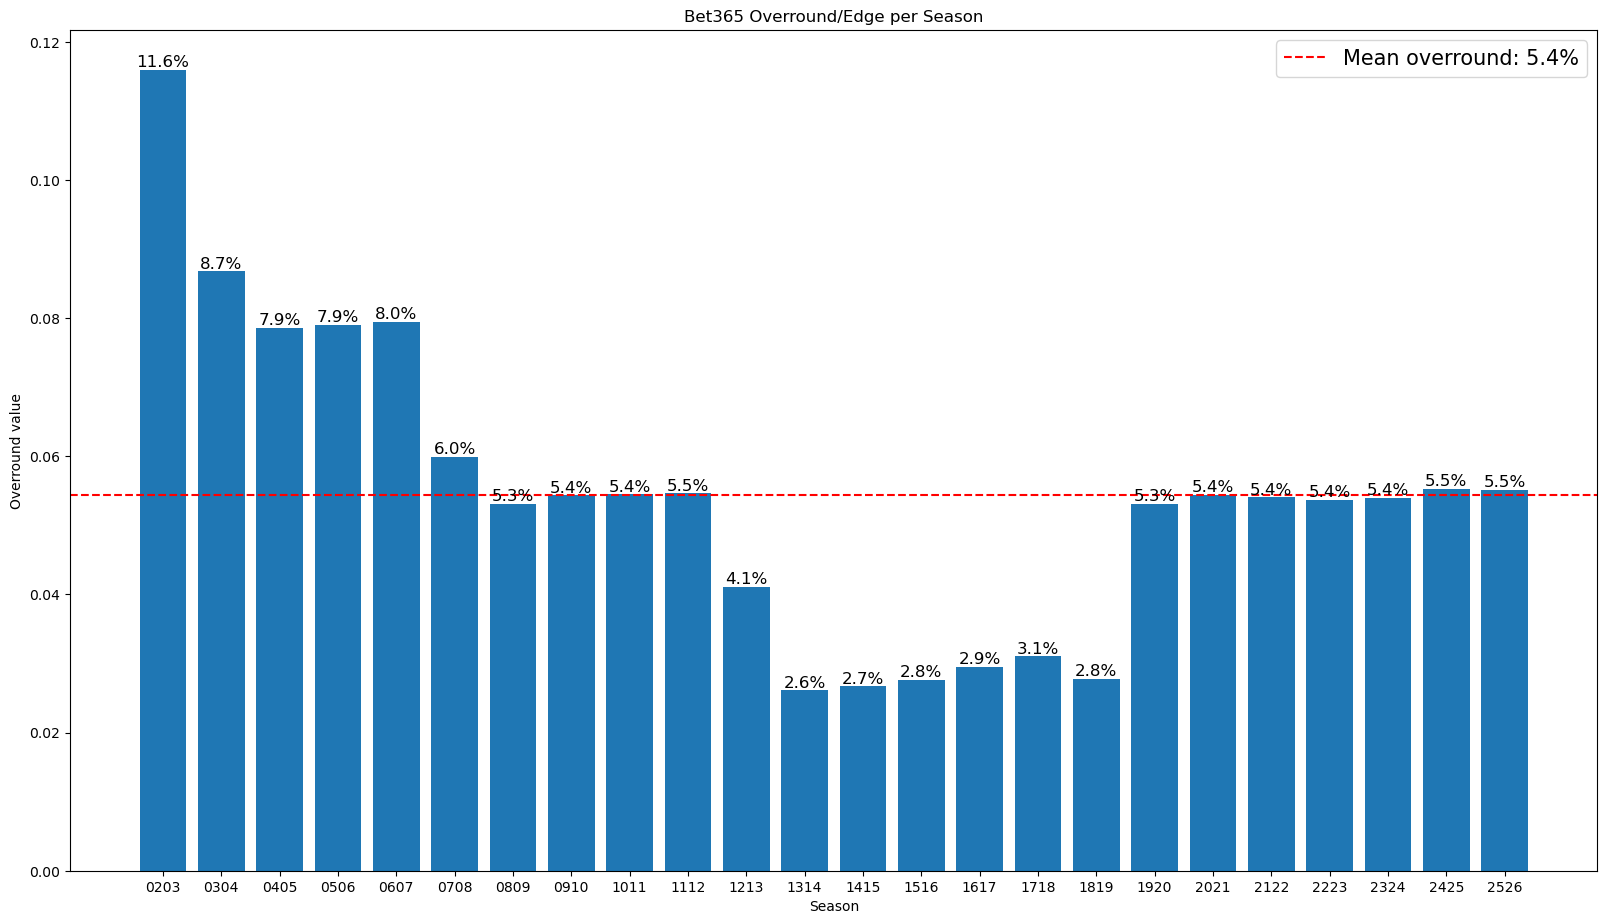

In [20]:
by_season_365 = all_seasons.groupby(all_seasons['Season'])['B365_overround'].mean().reset_index()
fig,ax = plt.subplots(figsize=(16,9))
plt.tight_layout()
bars = ax.bar(by_season_365['Season'],by_season_365['B365_overround'])
ax.bar_label(bars,labels=[f'{v:.1%}' for v in by_season_365['B365_overround']],fontsize=12)
ax.axhline(y=by_season_365['B365_overround'].mean(),linestyle='--',color='red',label=f'Mean overround: {round(100*by_season_365['B365_overround'].mean(),1)}%')
ax.set(xlabel='Season',ylabel='Overround value',title = 'Bet365 Overround/Edge per Season')
plt.legend(fontsize=15)
plt.show()

Plot above shows how much 'edge' Bet365 baked into the odds they offered for the 1X2 market across each season. The first 5 seasons are above the mean of 5.4% quite a lot especially the 02/03 but this is very likely due to the fact that Bet365 only began online betting in 2001 so at that point it was a very new business and probably did not have as sophisticated models and the funding yet. Starting in the 12/13 season there is a very clear drop in the average overround for this season and the proceeding 6 seasons. In 2012 Bet365 became the kit sponsor for Stoke City and they released their mobile app during the 12/13 season also so this period of lower overround to me resembles a period whereby the company wanted to attract more customers and boost their client base by providing better odds on average and advertise a lot more. This period last until 19/20 and then since then the overround has hovered at the long-term average

## Analysis

The analysis will be split into 4 sections: all results, home wins, draws and away wins. This is to get a clearer picture of how the bookmaker sets implied probabilities and to see how they perform as a whole and per result. Doing just an overall analysis is too broad due to the fact that with this dataset a home win, draw and away win are very different events so they should be analysed individually rather than just all together.

Some exploratory analysis will be performed but not an excessive load. The main analysis will consist of determining how well the bookmaker's calbration is aligned with perfect calibration, whether their expectations meet observed results, if there are any areas where a statistical significance implies 'off' implied probability assignment and attempting to identify any trends present via looking at the different segments of the data through different lenses.

The final section for each result will compare implied probabilities, actual rate of occurrence and the odds set for specific events to see if there was/is any chance to make money as a bettor and if there is an optimisef strategy for where to place money in the future. the main thing to consider here of course is that past performance is not an indicator of future odds setting and each match result and setting of odds is treating as entirely independent from every other match but in reality this is a poor assumption and the implications of this assumption and other assumptions used will be discussed in the conclusion.

### Chi-squared goodness-of-fit
In terms of the statistical section of this analysis I decided to use a goodness-of-fit chi-squared test. This was used to determine whether the observed frequency of successful events matched the expected frequency of successful events and ultimately allows a deeper insight into how well the bookmaker sets their implied probabilities to certain probability events. This will be performed across all the non-null probability bins for each result and for the whole dataset.

Hypotheses:

$H_0$: The observed counts are consistent with the expected counts.

$H_1$: The observed counts are inconsistent with the expected counts.
This will be tested at a 95% confidence level.
#### Goodness-of-fit test assumptions
1. Each observation is independent of every other observation. This means that the outcome of one match does not directly determine the result of another match. Eg, if Team A wins at home then this has no bearing on Team B winning at home. This is important as the test assumes that observed occurrences are from independent observations and dependent observations causes misleading p-values and test statistics. In reality, this assumption is not perfectly true as things like injuries, managerial changes, position in the table, etc. affect a team's performances in future games and this could then potentially alter how an opponent plays also. But, here it is a reasonable assumption for modelling purposes.
2. Each probability bin is mutually exclusive. This means that for every observation they can only belong to a single probability bin. Otherwise if they belonged to multiple this would mean counting that single event multiple times and this makes no sense. If this was the case here, the frequencies would not represent distinct categories which is required for this test to be valid.
3. The expected counts represent the null hypothesis. This is a must as they represent what is expected if the bookmakers calibrated their probability-setting perfectly.
4. Expected frequencies should be sufficiently large. At small numbers (<5) the chi-squared approximation begins to breakdown because at this low of a count number the sample distribution deviates from the assumed distributio of chi-squared. If counts are too low then the bin should be combined with an adjacent bin that has the lower count of the 2.

### Analysis Assumptions

1. The power method accurately reveals the implied probability for every event present in the dataset. This is crucial here as all of the implied probabilities are derived from the odds displayed by the bookmakers using this method. It is very difficult to determine accurately how implied probabilities are assigned to events by bookmakers but this is a very sound mathematical way of working backwards from odds to implied probability and is commonly used.
2. All matches and match outcomes are independent of one another. This is needed especially for the goodness-of-fit test as mentioned below. In reality, this is quite a stretch as results of one game likely influence several teams and their approach to future games and things like manager changes and injuries influence the affected team significantly. But for our purposes this is safe. (TALK ABOUT PROBABILITIES ENCODING EVERYTHING)
3. Match results have been correctly recorded. This is a data quality assumption rather than about the analysis but this has to be stated here as if events have been recorded incorrectly this will affect counts in several bins.
4. The probability bins used are appropriate for determing the bookmaker's calibration abilities. Bins of probability are used to provide meaningful sample sizes as using the actual probabilities produces a very small sample size and likely 1 sample for several different probabilities as they are on the order of 100th of a percent representing 10000 unique values. This makes it far easier to analyse and interpret but loses some information in the process.
5. Bins with insufficient observations are not used or combined with an adjacent bin.

#### Calibration

This is mainly an explanation of the plot but also what calibration means here. Calibration simply means how closely the bookmaker's implied probabilites correspond to the actual rate of occurrence with which these events happen. A bookmaker is well calibrated if events that have an assigned probability of x% occur x% of the time. It is concerned with the relationship between expected frequency and actual frequency. This is not to be confused with profitability though as this takes into account the odds rather than implied probabilities.
The black dashed line represents perfect calibration, meaning for all events with the implied probability of p occur at rate p. Points above the line represent the actual frequency to be higher than the mean implied probability and this demonstrates the bookmaker to underestimate the event's probability and points below the line represent the bookmaker to overestimate the event's probability. For the bookmaker it is more detrimental for underestimations as if an event occurs 60% of the time but they price it as if it occurs 50% of the time they will lose money on these types of events. So assuming odds = implied probabilities for simplicity, if a bookmaker underestimates events they state have an implied probability of 50% but they actually occur 60% of the time (extreme but highlights the point more) and lets say there are 1000 events at this price of 50% and a bettor simply just places £10 on each of these to be successful. For each win they return £20 and for each loss they lose £10. So total staked is £10,000 and total returns at 60% succes rate would be £10 x 2 (50% in odds) x 600 = £12,000, meaning a profit of £2,000 and an expected return of £1.20 for every £1 risked. This is what we want to focus on but using odds as what we looked at initially (the overround) is how bookmakers 'protect' themselves from underestimations. So later on we will look at the odds per probability bin and only there will we be able to assess potentially losses for the bookmaker.

I chose a colour map to represent the size of each group rather than sizing the points relative to their numerical value as I felt like the larger points appeared closer to the perfect calibration line than they actually are in reality and I feel like using a colour mapping retains the true deviation from perfection better than sizing each point to its numerical value does.

Within this calibration analysis 3 key metrics will be assessed for each result and overall. The aim of using these is to assess the errors associated with each result and overall, the number of observations and whether that plays a role for any observations and the difference between observed and expected values.

For all 3 metrics $y_i$ represents the observed value and $\hat y_i$ represents the expected value.

Firstly the mean error usually denoted ME.

$ME = \frac{1}{n} \Sigma_{i=1}^n (y_{i} - \hat y_i)$

This takes every error including its sign and averages it. It is used here to represent any systematic directional bias and direction is shown by sign here. ME > 0 represents predictions to be too low as the observed values are consistently or overall larger than the expected values then ME < 0 represents predictions to be too high as the observed values are consistently or overall smaller than the expected values. If ME ~ 0 this represents no directional bias. ME gets its usefulness by telling us whether or not the bookmaker errors are systematically pointing in one direction. The only issue with it is that errors can cancel out. So if there is a very large negative error in 1 bin then small positive errors in 19 bins that add up to give an ME value of ~ 0 all of this information is hidden with just looking at the final value. It is great at detecting bias but it is poor at measuring magnitude of errors.

Then the root mean squared error, denoted RMSE. This is a much more commonly used metric to determine how far off expected results are from actual/observed values and it is very easy to interpret its value.

$RMSE = \sqrt{\frac{1}{n} \Sigma_{i=1}^n (y_i - \hat y_i)^2}$

This has a lot more going on than the equation defining the ME. The errors are squared firstly so that positive and negative errors cannot cancel each other out and also so that large errors are penalised disproportionately. This is good as if there are any outliers they are assigned more weight than 'normal' values and this means the overall distribution is punished for having extreme/large values. For this case specifically, if a bookmaker is under or overestimating significantly the RMSE value will reflect this very well as these are errors that are of interest here. A smaller value for RMSE represents a better accuracy of the bookmaker's implied probability assignment and a value of 0 shows 100% accuracy for probability assignment to events. What is important to remember is that units of RMSE are the same as what is being measured and the value of RMSE is relative to the data range and what is being measured.

Then the Brier score which is just $ \sqrt{RMSE}$. This will be a value between 0 and 1 and it is a measure of accuracy of probabilistic predictions through calculating the mean squared difference between predicted probabilities andatcual outcomes. The lower the score the beter the accuracy.

In [21]:
edges = np.arange(0,1.01,0.05)

labels = [
    f'{round(edges[i]*100, 0)}-{round(edges[i+1]*100, 0)}%'
    for i in range(20)
]
upper = np.arange(0.05,1.01,0.05)
lower = np.arange(0,0.96,0.05)


bounds = pd.DataFrame({
    'Implied Probability Bins': labels,
    'Lower': edges[:-1],
    'Upper': edges[1:]
})

In [22]:
all_seasons.dropna(subset=['B365H_prob'],inplace=True)

Rows with no implied probability values are dropped here which are all rows in 00/01 and 01/02 seasons. I used 'B365H_prob' for no particular reason. It would have been the same using the draw or away probabilities.

In [23]:
home_results = all_seasons[all_seasons['FTR']=='H'].copy()
draw_results = all_seasons[all_seasons['FTR'] == 'D'].copy()
away_results = all_seasons[all_seasons['FTR'] == 'A'].copy()

In [24]:
home_results['Implied Probability Bins'] = pd.cut(home_results['B365H_prob'],bins=edges,labels=labels,right=False,ordered=True)
home_results['Implied Probability Bins'] = pd.Categorical(home_results['Implied Probability Bins'],categories=labels,ordered=True)
home_results['Raw Probability Bins'] = pd.cut(home_results['B365H_raw'],bins=edges,labels=labels,right=False)
home_results['Raw Probability Bins'] = pd.Categorical(home_results['Raw Probability Bins'],categories=labels,ordered=True)

draw_results['Implied Probability Bins'] = pd.cut(draw_results['B365D_prob'],bins=edges,labels=labels,right=False)
draw_results['Raw Probability Bins'] = pd.cut(draw_results['B365D_raw'],bins=edges,labels=labels,right=False)
draw_results['Implied Probability Bins'] = pd.Categorical(draw_results['Implied Probability Bins'],categories=labels,ordered=True)
draw_results['Raw Probability Bins'] = pd.Categorical(draw_results['Raw Probability Bins'],categories=labels,ordered=True)

away_results['Raw Probability Bins'] = pd.cut(away_results['B365A_raw'],bins=edges,labels=labels,right=False)
away_results['Implied Probability Bins'] = pd.cut(away_results['B365A_prob'],bins=edges,labels=labels,right=False)
away_results['Implied Probability Bins'] = pd.Categorical(away_results['Implied Probability Bins'],categories=labels,ordered=True)
away_results['Raw Probability Bins'] = pd.Categorical(away_results['Raw Probability Bins'],categories=labels,ordered=True)

### Home Data Frame

In [25]:
all_bins_home = pd.cut(
    all_seasons['B365H_prob'],
    bins=edges,
    labels=labels,
    right=False,
    ordered=True
)

home_bins = pd.cut(
    home_results['B365H_prob'],
    bins=edges,
    labels=labels,
    right=False,
    ordered=True
)

In [26]:
all_stats_home = (
    all_seasons
    .groupby(all_bins_home, observed=False)
    .agg(
        Number_of_events=('B365H_prob', 'size'),
        Expected_Successes=('B365H_prob', 'sum'),
        Variance=('B365H_prob', lambda s: (s * (1 - s)).sum()),
        Mean_Implied_Probability=('B365H_prob', 'mean')
    )
    .reset_index()
    .rename(columns={'B365H_prob': 'Implied Probability Bins'})
)

In [27]:
successful_events_home = (
    home_results
    .groupby(home_bins, observed=False)
    .size()
    .reset_index(name='Observed Events')
    .rename(columns={'B365H_prob': 'Implied Probability Bins'})
)

In [28]:
b365h_final = all_stats_home.merge(
    successful_events_home,
    on='Implied Probability Bins',
    how='left'
)

In [29]:
b365h_final = b365h_final.merge(
    bounds,
    on='Implied Probability Bins',
    how='left'
)

In [30]:
b365h_final['Difference'] = (
    b365h_final['Expected_Successes']
    - b365h_final['Observed Events']
)

sd = np.sqrt(b365h_final['Variance'])

b365h_final['Lower Error'] = np.minimum(1.96*sd, b365h_final['Expected_Successes']) #1.96 to define a 95% CI
b365h_final['Upper Error'] = 1.96*sd

b365h_final.loc[b365h_final['Expected_Successes'] <5, ['Lower Error','Upper Error']] = np.nan

In [31]:
b365h_final['Mean Implied Probability (%)'] = (
    b365h_final['Mean_Implied_Probability'] * 100
)

b365h_final['Actual Frequency (%)'] = (
    b365h_final['Observed Events']
    / b365h_final['Number_of_events']
    * 100
)

In [32]:
b365h_final = b365h_final[
    [
        'Implied Probability Bins',
        'Number_of_events',
        'Observed Events',
        'Expected_Successes',
        'Difference',
        'Variance',
        'Lower Error',
        'Upper Error',
        'Mean Implied Probability (%)',
        'Actual Frequency (%)'
    ]
]

b365h_final = b365h_final.rename(columns={
    'Number_of_events': 'Number of events',
    'Successful_events': 'Successful events',
    'Expected_Successes': 'Expected Successes'
})

In [33]:
b365h_final['Implied Probability Bins'] = pd.Categorical(
    b365h_final['Implied Probability Bins'],
    categories=labels,
    ordered=True
)

b365h_final = b365h_final.sort_values(
    'Implied Probability Bins'
).reset_index(drop=True)

In [34]:
b365h_final['Distance from Perfect Calibration'] = b365h_final['Actual Frequency (%)'] - b365h_final['Mean Implied Probability (%)']

In [35]:
b365h_final.rename(columns={
    'Expected Successes':'Expected Events',
    'Implied Probability Bin':'Implied Probability Bins'
},inplace=True)

### Draw Data Frame

In [36]:
all_bins_draw = pd.cut(
    all_seasons['B365D_prob'],
    bins=edges,
    labels=labels,
    right=False,
    ordered=True
)

draw_bins = pd.cut(
    draw_results['B365D_prob'],
    bins=edges,
    labels=labels,
    right=False,
    ordered=True
)

In [37]:
all_stats_draw = (
    all_seasons
    .groupby(all_bins_draw, observed=False)
    .agg(
        Number_of_events=('B365D_prob', 'size'),
        Expected_Successes=('B365D_prob', 'sum'),
        Variance=('B365D_prob', lambda s: (s * (1 - s)).sum()),
        Mean_Implied_Probability=('B365D_prob', 'mean')
    )
    .reset_index()
    .rename(columns={'B365D_prob': 'Implied Probability Bins'})
)

In [38]:
successful_events_draw = (
    draw_results
    .groupby(draw_bins, observed=False)
    .size()
    .reset_index(name='Observed Events')
    .rename(columns={'B365D_prob': 'Implied Probability Bins'})
)

In [39]:
b365d_final = all_stats_draw.merge(
    successful_events_draw,
    on='Implied Probability Bins',
    how='left'
)
b365d_final = b365d_final.merge(
    bounds,
    on='Implied Probability Bins',
    how='left'
)

In [40]:
b365d_final['Difference'] = (
    b365d_final['Expected_Successes']
    - b365d_final['Observed Events']
)

sd = np.sqrt(b365d_final['Variance'])
b365d_final['Lower Error'] = np.minimum(1.96 * sd, b365d_final['Expected_Successes'])
b365d_final['Upper Error'] = 1.96 * sd
b365d_final.loc[b365d_final['Expected_Successes'] <5, ['Lower Error', 'Upper Error']] = np.nan

In [41]:
b365d_final['Mean Implied Probability (%)'] = (
    b365d_final['Mean_Implied_Probability'] * 100
)

b365d_final['Actual Frequency (%)'] = (
    b365d_final['Observed Events']
    / b365d_final['Number_of_events']
    * 100
)

In [42]:
b365d_final = b365d_final[
    [
        'Implied Probability Bins',
        'Number_of_events',
        'Observed Events',
        'Expected_Successes',
        'Difference',
        'Variance',
        'Lower Error',
        'Upper Error',
        'Mean Implied Probability (%)',
        'Actual Frequency (%)'
    ]
]

b365d_final = b365d_final.rename(columns={
    'Number_of_events': 'Number of events',
    'Successful_events': 'Successful events',
    'Expected_Successes': 'Expected Successes'
})

In [43]:
b365d_final['Implied Probability Bins'] = pd.Categorical(
    b365d_final['Implied Probability Bins'],
    categories=labels,
    ordered=True
)

b365d_final = b365d_final.sort_values(
    'Implied Probability Bins'
).reset_index(drop=True)

In [44]:
b365d_final['Distance from Perfect Calibration'] = b365d_final['Actual Frequency (%)'] - b365d_final['Mean Implied Probability (%)']

In [45]:
b365d_final.rename(columns={
    'Expected Successes':'Expected Events',
    'Implied Probability Bin':'Implied Probability Bins'
},inplace=True)

### Away Data Frame

In [46]:
all_bins_away = pd.cut(
    all_seasons['B365A_prob'],
    bins=edges,
    labels=labels,
    right=False,
    ordered=True
)

away_bins = pd.cut(
    away_results['B365A_prob'],
    bins=edges,
    labels=labels,
    right=False,
    ordered=True
)

In [47]:
all_stats_away = (
    all_seasons
    .groupby(all_bins_away, observed=False)
    .agg(
        Number_of_events=('B365A_prob', 'size'),
        Expected_Successes=('B365A_prob', 'sum'),
        Variance=('B365A_prob', lambda s: (s * (1 - s)).sum()),
        Mean_Implied_Probability=('B365A_prob', 'mean')
    )
    .reset_index()
    .rename(columns={'B365A_prob': 'Implied Probability Bins'})
)
# need variance here to take into account uncertainty and it tellsus how surprising an observed count is

In [48]:
successful_events_away = (
    away_results
    .groupby(away_bins, observed=False)
    .size()
    .reset_index(name='Observed Events')
    .rename(columns={'B365A_prob': 'Implied Probability Bins'})
)

In [49]:
b365a_final = all_stats_away.merge(
    successful_events_away,
    on='Implied Probability Bins',
    how='left'
)
b365a_final = b365a_final.merge(
    bounds,
    on='Implied Probability Bins',
    how='left'
)

In [50]:
b365a_final['Difference'] = (
    b365a_final['Expected_Successes']
    - b365a_final['Observed Events']
)

sd = np.sqrt(b365a_final['Variance'])
b365a_final['Lower Error'] = np.minimum(1.96 * sd, b365a_final['Expected_Successes'])
b365a_final['Upper Error'] = 1.96 * sd
b365a_final.loc[b365a_final['Expected_Successes'] <5, ['Lower Error','Upper Error']] = np.nan

In [51]:
b365a_final['Mean Implied Probability (%)'] = (
    b365a_final['Mean_Implied_Probability'] * 100
)

b365a_final['Actual Frequency (%)'] = (
    b365a_final['Observed Events']
    / b365a_final['Number_of_events']
    * 100
)

In [52]:
b365a_final = b365a_final[
    [
        'Implied Probability Bins',
        'Number_of_events',
        'Observed Events',
        'Expected_Successes',
        'Difference',
        'Variance',
        'Lower Error',
        'Upper Error',
        'Mean Implied Probability (%)',
        'Actual Frequency (%)'
    ]
]

b365a_final = b365a_final.rename(columns={
    'Number_of_events': 'Number of events',
    'Successful_events': 'Observed Events',
    'Expected_Successes': 'Expected Events'
})

In [53]:
b365a_final['Distance from Perfect Calibration'] = b365a_final['Actual Frequency (%)'] - b365a_final['Mean Implied Probability (%)']

In [54]:
b365a_final.rename({
    'Expected Successes':'Expected Events',
    'Implied Probability Bin':'Implied Probability Bins'
},inplace=True)

### Odds DataFrame Setup

In [55]:
def profitability_calc(result:str):

    abbr = result.capitalize()[0]
    if result == 'home':
        df = home_results
        df2 = b365h_final
    elif result == 'draw':
        df = draw_results
        df2 = b365d_final
    elif result == 'away':
        df = away_results
        df2 = b365a_final

    avg_odds = df.groupby('Implied Probability Bins',observed=True)[f'B365{abbr}'].mean().reset_index()
    avg_odds.rename(columns={f'B365{abbr}':'Average Odds'},inplace=True)
    odds = df2.merge(avg_odds,on='Implied Probability Bins',how='left')
    
    all_seasons_copy[f'{result.capitalize()} Profit'] = np.where(
    all_seasons_copy['FTR'] == f'{abbr}',
    (all_seasons_copy[f'B365{abbr}'] - 1) * 10,
    -10)

    profitability = (
    all_seasons_copy
    .groupby(f'{result.capitalize()} Implied Probability Bins',observed=True)
    .agg(
        Number_of_Bets=(f'{result.capitalize()} Profit', 'size'),
        Total_Profit=(f'{result.capitalize()} Profit', 'sum'))).reset_index()
    profitability['ROI (%)'] = (
    profitability['Total_Profit']
    / (profitability['Number_of_Bets'] * 10)
    ) * 100
    complete_df = odds.merge(profitability,left_on='Implied Probability Bins',right_on=f'{result.capitalize()} Implied Probability Bins',how='left')
    complete_df.drop(columns=[f'{result.capitalize()} Implied Probability Bins','Number_of_Bets'],axis=1,inplace=True)
    complete_df.rename(columns={'Number of events':'Number of bets placed','Total_profit':'Total Profit (£)','Observed Events':'Successful Bets','Expected Events':'Expected Successful Bets'},inplace=True)
    return complete_df

In [56]:
def seasonal_profitability(result: str):
    result = result.lower()

    odds = {
        'home': 'B365H',
        'draw': 'B365D',
        'away': 'B365A'
    }

    outcomes = {
        'home': 'H',
        'draw': 'D',
        'away': 'A'
    }

    df = all_seasons_copy.copy()
    
    odds_col = odds[result]
    outcome = outcomes[result]


    df['Profit'] = np.where(
        df['FTR'] == outcome,
        (df[odds_col] - 1) * 10,
        -10
    )

    seasonal = (
        df.groupby('Season')
        .agg(
            Total_Profit=('Profit', 'sum'),
            Number_of_Bets=('Profit','size')
        )
        .reset_index()
    )

    seasonal['ROI (%)'] = (
        seasonal['Total_Profit']
        / (seasonal['Number_of_Bets'] * 10)
    ) * 100

    return seasonal

### Total DataFrame

In [57]:
all_seasons_copy = all_seasons.copy()
for side, pcol in [('Home','B365H_prob'),('Draw','B365D_prob'),('Away','B365A_prob')]:
    all_seasons_copy[f'{side} Implied Probability Bins'] = pd.Categorical(pd.cut(all_seasons_copy[pcol],bins=edges,labels=labels,right=False),
                                                                         categories=labels,ordered=True)

for side, rcol in [('Home','B365H_prob'),('Draw','B365D_prob'),('Away','B365A_prob')]:
    all_seasons_copy[f'{side} Implied Probability Bins'] = pd.Categorical(pd.cut(all_seasons_copy[rcol],bins=edges,labels=labels,right=False),
                                                                         categories=labels,ordered=True)

totals = {'Implied Probability Bins':labels,
         'Number of Events':[],'Expected Events':[],'Variance':[]}

for i in range(20):
    n = e = v = 0
    for pcol in ('B365H_prob','B365D_prob','B365A_prob'):
        p = all_seasons_copy.loc[(all_seasons_copy[pcol] >= edges[i]) & (all_seasons_copy[pcol] < edges[i+1]),pcol]
        n += len(p)
        e += p.sum()
        v += (p*(1-p)).sum()
    totals['Number of Events'].append(n)
    totals['Expected Events'].append(e)
    totals['Variance'].append(v)
expected_v_observed = pd.DataFrame(totals)

observed = pd.Series(0, index=labels, dtype=int)
for side, result in [('Home','H'),('Draw','D'),('Away','A')]:
    observed = observed.add(
        all_seasons_copy[all_seasons_copy['FTR'] == result]
        .groupby(f'{side} Implied Probability Bins',observed=False)
        .size().reindex(labels,fill_value=0),fill_value=0
    )
expected_v_observed['Observed Events'] = observed.reindex(labels).to_numpy()
expected_v_observed['Difference'] = (expected_v_observed['Expected Events'] - expected_v_observed['Observed Events'])

sd = np.sqrt(expected_v_observed['Variance'])
expected_v_observed['Lower Error'] = np.minimum(1.96 * sd, expected_v_observed['Expected Events'])
expected_v_observed['Upper Error'] = 1.96 * sd
expected_v_observed.loc[
    expected_v_observed['Expected Events'] < 5, ['Lower Error', 'Upper Error']
] = np.nan

expected_v_observed['Mean Implied Probability (%)'] = (100 * expected_v_observed['Expected Events'] / expected_v_observed['Number of Events'])
expected_v_observed['Actual Frequency (%)'] = (100 * expected_v_observed['Observed Events'] / expected_v_observed['Number of Events'])
expected_v_observed['Distance from Perfect Calibration'] = (expected_v_observed['Actual Frequency (%)'] - expected_v_observed['Mean Implied Probability (%)'])

expected_v_observed = expected_v_observed[expected_v_observed['Number of Events'] > 0].reset_index(drop=True)
expected_v_observed.drop(columns=['Variance'], inplace=True)

### Monthly DataFrame Construction

I decided to do monthly analysis as the way that teams play month-to-month can change greatly depending on the team's expectations for the season, previous results, upcoming fixtures, position in the table, etc. and as a result the bookmakers will very likely adjust how they approach each fixture. August may see more outliers or unexpected observations as it is the start of a new season and there are 3 different teams compared to last year as well as new signings, new managers and potentially new officiating rules. Then in May there is a lot of data on each team so it could be expected that the bookmaker is better calibrated towards the final games as a result.

### Ensure bin count is at least 5 for Chi-squared

In [58]:
def _population_column(df):
    """Find the column holding the number of events in each bin.

    The aggregate tables call it 'Number of events' and the monthly tables call
    it 'Number of Events', so match case-insensitively rather than hardcoding.
    """
    for c in df.columns:
        if c.strip().lower() == 'number of events':
            return c
    raise KeyError(f"no 'Number of events' column in {list(df.columns)}")


def combine_bins(df, min_expected=5):
    """Merge adjacent probability bins until each group holds at least
    min_expected expected successes AND min_expected expected failures.

    The chi-squared approximation needs both cells of a bin to be adequately
    populated, not just the successes - a bin of 6 near-certain events has
    plenty of expected successes and almost no expected failures, and the
    failure term blows up. Any leftover at the top end is merged backwards
    rather than discarded.
    """
    n_col = _population_column(df)

    def adequate(rows):
        e = sum(x['Expected Events'] for x in rows)
        n = sum(x[n_col] for x in rows)
        return e >= min_expected and (n - e) >= min_expected

    groups, current = [], []
    for _, row in df.iterrows():
        current.append(row)
        if adequate(current):
            groups.append(current)
            current = []

    if current:
        if groups:
            groups[-1].extend(current)
        else:
            groups.append(current)

    while len(groups) > 1 and not adequate(groups[-1]):
        groups[-2].extend(groups.pop())

    return pd.DataFrame([{
        'Implied Probability Bins': f"{g[0]['Implied Probability Bins']}-{g[-1]['Implied Probability Bins']}",
        'Observed Events':  sum(x['Observed Events'] for x in g),
        'Expected Events':  sum(x['Expected Events'] for x in g),
        'Number of events': sum(x[n_col]            for x in g),
    } for g in groups])


def calibration_chi2(binned):
    """Chi-squared goodness-of-fit for a binned calibration table.

    Each bin contributes two cells: the events that happened and the events
    that did not. Returns (statistic, degrees of freedom, p-value).
    """
    o = binned['Observed Events'].to_numpy(float)
    e = binned['Expected Events'].to_numpy(float)
    n = binned['Number of events'].to_numpy(float)

    if len(binned) < 2:
        raise ValueError('need at least two bins to test against')
    if (e <= 0).any() or ((n - e) <= 0).any():
        raise ValueError('a bin has no expected successes or no expected failures')

    stat = ((o - e)**2 / e + (o - e)**2 / (n - e)).sum()
    dof  = len(binned) - 1
    return stat, dof, chi2.sf(stat, dof)

### Monthly DataFrame setup

In [59]:
def monthly_df_setup(result:str):
    '''
    Enter the desired result of either 'home', 'draw' or 'away' to produce the df that contains the correct data per month for the result
    '''
    dfs = {
        'home':{
            'results':home_results,
            'bins':home_bins
        },
        'draw':{
            'results':draw_results,
            'bins':draw_bins
        },
        'away':{
            'results':away_results,
            'bins':away_bins
        }
    }
    results = dfs[result]['results']
    bins = dfs[result]['bins']
    abbr = result[0].capitalize()
    prob_col = f'B365{abbr}_prob'
    bin_col = f'{result.capitalize()}'
    
    total_events_pb_pm = all_seasons_copy.groupby([all_seasons_copy['Date'].dt.month_name(),f'{bin_col} Implied Probability Bins'],observed=False)[prob_col].size().reset_index()
    total_events_pb_pm.rename(columns={
        'Date':'Month',
        f'{bin_col} Implied Probability Bins':'Implied Probability Bins',
        prob_col:'Total Events'
    },inplace=True)
    successful_events_monthly = (
    results
    .groupby([bins,results['Date'].dt.month_name()], observed=False)
    .size()
    .reset_index(name='Observed Events'))
    successful_events_monthly.rename(columns={
    prob_col:'Implied Probability Bins',
    'Date':'Month'
    },inplace=True)
    complete_monthly_df = all_seasons_copy.groupby([all_seasons_copy['Date'].dt.month_name(),f'{bin_col} Implied Probability Bins'],observed=False).agg(
    Number_of_Events=(prob_col,'size'),
    Expected_Success=(prob_col,'sum'),
    Variance=(prob_col, lambda s:(s*(1-s)).sum()),
    Mean_Implied_Probability=(prob_col,'mean')
    ).reset_index()
    complete_monthly_df.rename(columns={
        'Date':'Month',
        'Number_of_Events':'Number of Events',
        'Expected_Success':'Expected Events',
        'Mean_Implied_Probability':'Mean Implied Probability',
        f'{result.capitalize()} Implied Probability Bins':'Implied Probability Bins'
    },inplace=True)
    actual_successes = results.groupby([results['Date'].dt.month_name(),'Implied Probability Bins'],observed=False).agg(
        Actual_Successes=(prob_col,'size')
    ).reset_index()
    actual_successes.rename(columns={
        'Date':'Month'
    },inplace=True)
    complete = complete_monthly_df.merge(actual_successes,on=['Month','Implied Probability Bins'],how='left')
    complete.rename(columns={'Actual_Successes':'Observed Events'},inplace=True)
    # a month/bin pair where the outcome never occurred is a zero, not a gap
    complete['Observed Events'] = complete['Observed Events'].fillna(0)
    complete['Mean Implied Probability (%)'] = complete['Mean Implied Probability']*100
    complete['Actual Frequency (%)'] = 100*(complete['Observed Events']/complete['Number of Events'])
    total_monthly_df = complete.merge(bounds,on='Implied Probability Bins',how='left')
    sd = np.sqrt(total_monthly_df['Variance'])
    total_monthly_df['Lower Error'] = np.minimum(1.96*sd, total_monthly_df['Expected Events'])
    total_monthly_df['Upper Error'] = 1.96 * sd
    total_monthly_df.loc[total_monthly_df['Expected Events'] <5, ['Lower Error','Upper Error']] = np.nan
    
    total_monthly_df.drop(['Mean Implied Probability','Lower','Upper'],inplace=True,axis=1)
    total_monthly_df['Implied Probability Bins'] = pd.Categorical(
    total_monthly_df['Implied Probability Bins'],
    categories=labels,
    ordered=True)
    total_monthly_df['Distance from Perfect Calibration'] = total_monthly_df['Actual Frequency (%)'] - total_monthly_df['Mean Implied Probability (%)']
    total_monthly_df = total_monthly_df[['Month','Implied Probability Bins','Number of Events',
                                         'Expected Events','Observed Events',
                                         'Mean Implied Probability (%)','Actual Frequency (%)',
                                         'Lower Error','Upper Error',
                                         'Distance from Perfect Calibration']]    
    return total_monthly_df

### Per Month for each result DataFrame setup

#### Expected vs Observed

In [60]:
def expected_vs_observed_by_month(month:str,result:str):
    '''
    Plots 2 bars side-by-side for each probability bin for a defined month.

    Month needs to be input with a capital letter, for example 'March' rather than 'march'.

    DataFrame altered depending on what type of result is in question.
    '''
    result = result.lower()
    if result == 'home':
        df = home_monthly_df
    elif result == 'draw':
        df = draw_monthly_df
    elif result == 'away':
        df = away_monthly_df
    month_df = df[df['Month'] == month]
    ax = month_df.plot(x='Implied Probability Bins',y=['Expected Events','Observed Events'],kind='bar',figsize=(16,9),rot=60,fontsize=13)
    ax.set_xlabel('Implied Probability Bins',fontsize=14)
    ax.set_ylabel('Count',fontsize=14)
    ax.set_title('Expected vs. Observed Event Counts Home Wins',fontsize=20)
    ax.tick_params(axis='both',labelsize=15)
    plt.tight_layout()
    plt.legend(fontsize=15)
    plt.show()

#### Expected vs Observed with expected ranges

In [61]:
def expected_vs_actual_w_ranges(month:str,result:str):
    '''
    Plots a bar chart overlaid with a scatter plot to show whether the expected counts encapsulates the observed number of events.
    '''
    month = month.capitalize()
    result = result.lower()
    if result == 'home':
        df = home_monthly_df
    elif result == 'draw':
        df = draw_monthly_df
    elif result == 'away':
        df = away_monthly_df
    month_df = df[df['Month'] == month]
    y_errors=[month_df['Lower Error'],month_df['Upper Error']]
    fig,ax = plt.subplots(figsize=(16,9))
    ax.bar(month_df['Implied Probability Bins'],month_df['Expected Events'],yerr=y_errors,alpha=0.5,label='Expected Events',
          capsize=5,ecolor='blue')
    ax.scatter(month_df['Implied Probability Bins'],month_df['Observed Events'],label='Observed Events',color='red',alpha=0.9)
    ax.set_xlabel('Probability Bins',fontsize=15)
    ax.set_ylabel('Count',fontsize=15)
    ax.set_title('Observed Events and Expected Events with errors per probability bin Home Wins',fontsize=18)
    plt.xticks(rotation=60)
    ax.tick_params(axis='both',labelsize=15)
    plt.tight_layout()
    plt.legend(fontsize=15)
    plt.show()

#### Calibration plot

In [62]:
def monthly_calibration(month:str,result):
    month = month.capitalize()
    result = result.lower()
    if result == 'home':
        df = home_monthly_df
    elif result == 'draw':
        df = draw_monthly_df
    elif result == 'away':
        df = away_monthly_df
    month_df = df[df['Month'] == month]
    fig,ax = plt.subplots(figsize=(16,9))
    ax = sns.scatterplot(data=month_df,x='Mean Implied Probability (%)',y='Actual Frequency (%)',hue='Observed Events',s=100,palette='RdYlGn')
    ax.set_xlabel('Mean Implied Probability (%)',fontsize=14)
    ax.set_ylabel('Actual Frequency (%)',fontsize=14)
    ax.set_title('Implied Probability vs. Actual Frequency for Home Results',fontsize=17)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=-0.25)
    plt.axline((0, 0), slope=1, color="black", linestyle="--",label='Perfect Calibration')
    plt.legend()
    plt.show()

#### ME and RMSE computation

In [63]:
def compute_monthly_metrics(result:str):
    '''
    Input the result as either H, D or A.

    Finds ME and RMSE for every month for each result.
    '''
    monthly_metrics = []
    for month in month_order:
        months = {}
        months[month] = {}
        errors = (all_seasons_copy[all_seasons_copy['Date'].dt.month_name() == month]['FTR']==result).astype(int) - all_seasons_copy[all_seasons_copy['Date'].dt.month_name() == month][f'B365{result}_prob'] # translates to actual outcome - the implied probability. Success = 1
        months[month]['Mean Error'] = errors.mean()
        months[month]['Root Mean Square Error'] = np.sqrt((errors**2).mean())
        monthly_metrics.append(months)
    return monthly_metrics

#### Chi-squared values

In [64]:
def chi_squared_per_month(month:str,result:str):
    """p-value for one month, using the same two-cell statistic as the aggregate tests."""
    month = month.capitalize()
    result = result.lower()
    if result == 'home':
        df = home_monthly_df
    elif result == 'draw':
        df = draw_monthly_df
    elif result == 'away':
        df = away_monthly_df
    chi_df = combine_bins(df[df['Month'] == month])
    return calibration_chi2(chi_df)[2]

#### Monthly effect size

In [65]:
def effect_size_per_month(month: str, result: str):
    month = month.capitalize()
    result = result.lower()

    if result == 'home':
        df = home_monthly_df
    elif result == 'draw':
        df = draw_monthly_df
    elif result == 'away':
        df = away_monthly_df

    effect_df = df[df['Month'] == month]
    effect_df = combine_bins(effect_df)

    observed_prop = (
        effect_df['Observed Events'] /
        effect_df['Observed Events'].sum()
    )

    expected_prop = (
        effect_df['Expected Events'] /
        effect_df['Expected Events'].sum()
    )

    w = np.sqrt(
        np.sum(
            (observed_prop - expected_prop) ** 2
            / expected_prop
        )
    )

    return w

### Total Analysis

In [66]:
expected_v_observed

,Implied Probability Bins,Number of Events,Expected Events,Observed Events,Difference,Lower Error,Upper Error,Mean Implied Probability (%),Actual Frequency (%),Distance from Perfect Calibration
0,0.0-5.0%,265,10.194623,10,0.194623,6.131943,6.131943,3.847027,3.773585,-0.073443
1,5.0-10.0%,1162,88.437928,92,-3.562072,17.690079,17.690079,7.610837,7.917384,0.306547
2,10.0-15.0%,1808,229.214942,232,-2.785058,27.701280,27.701280,12.677818,12.831858,0.154041
3,15.0-20.0%,2350,412.736102,406,6.736102,36.128206,36.128206,17.563238,17.276596,-0.286643
4,20.0-25.0%,3638,828.456811,841,-12.543189,49.543416,49.543416,22.772315,23.117097,0.344783
5,25.0-30.0%,6866,1896.817650,1941,-44.182350,72.590807,72.590807,27.626240,28.269735,0.643495
6,30.0-35.0%,1924,623.206583,574,49.206583,40.213033,40.213033,32.391195,29.833680,-2.557515
7,35.0-40.0%,1654,622.076601,617,5.076601,38.595751,38.595751,37.610435,37.303507,-0.306929
8,40.0-45.0%,1455,616.007969,608,8.007969,36.925886,36.925886,42.337317,41.786942,-0.550376
9,45.0-50.0%,1269,599.729588,581,18.729588,34.842545,34.842545,47.260015,45.784082,-1.475933


The difference between the expected number of events given the assigned probabilities within each bin and the observed number of events in each category across the whole dataset is 0 but looking at the differences for each result done separately across all seasons there is a whole difference of 2. This is likely due to rounding errors somewhere and this is negligible compared to 9120 observations. 
It is evident that 2 probability bins are quite 'adrift' from the expected events matching the observed events which are the 25-30% and 30-35% bins. These bins differ by -44 and 49 respectively representing a -3.5% and a 7.5% differencebut they pretty much cancel each other out here. Then the 55-60% bin also has quite a large difference of -25 which is just under 5%.

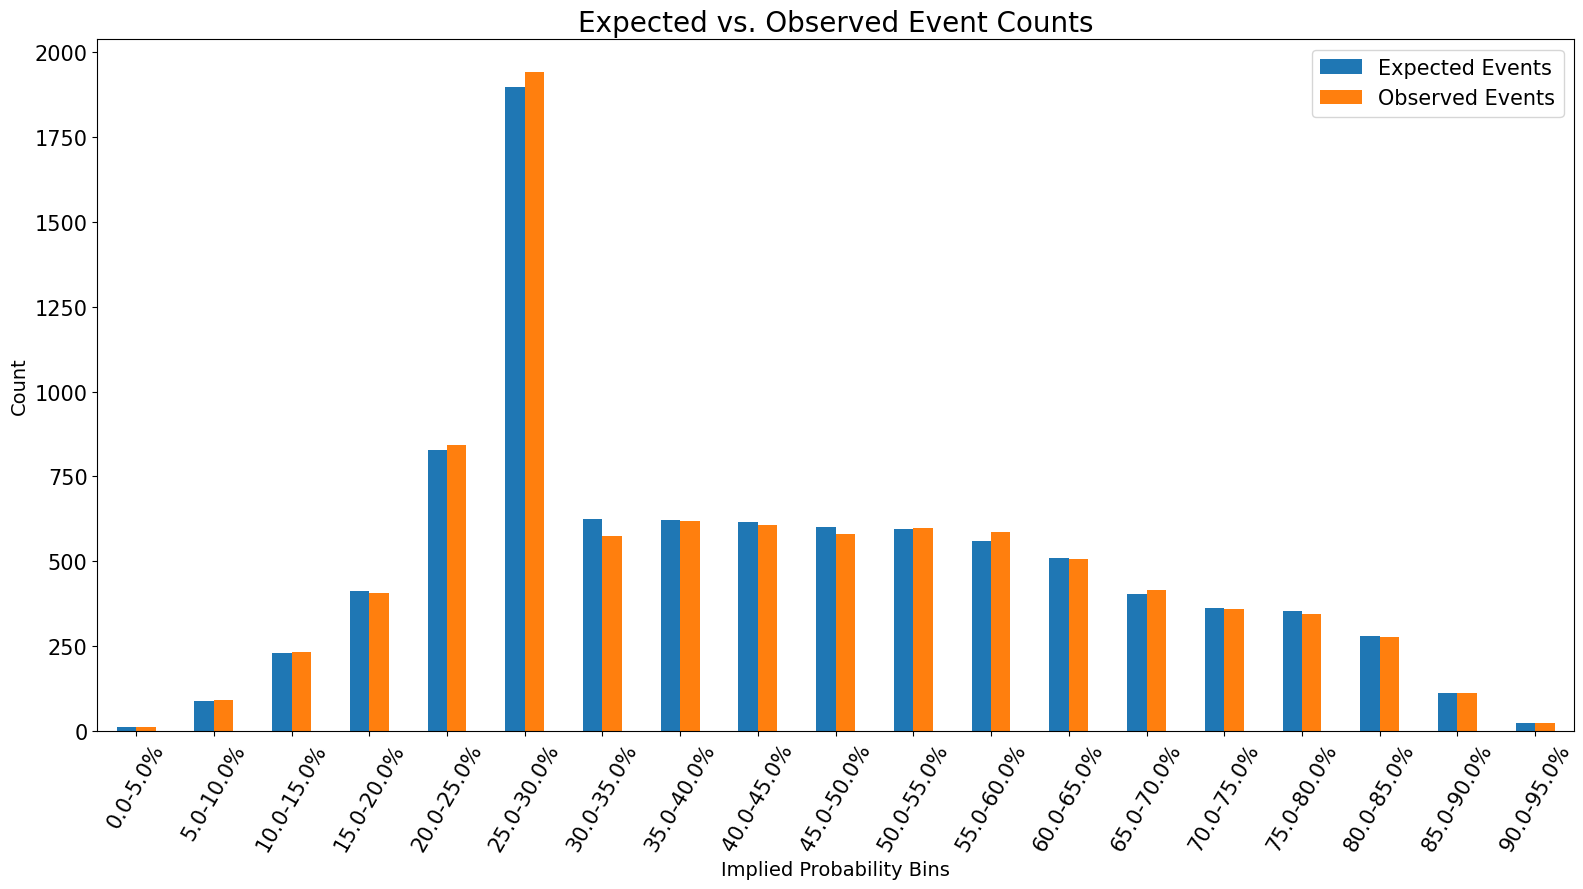

In [67]:
ax = expected_v_observed.plot(x='Implied Probability Bins',y=['Expected Events','Observed Events'],kind='bar',figsize=(16,9),rot=60,fontsize=13)
ax.set_xlabel('Implied Probability Bins',fontsize=14)
ax.set_ylabel('Count',fontsize=14)
ax.set_title('Expected vs. Observed Event Counts',fontsize=20)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

This plot compared to the individual result plots looks very different. Firstly, the large spike in the 25-30% column is due to most draws being priced in this range. What else shown that differs to all of the result plots is that the actual successes fall within the error bars of the expected successes and this is an important finding. It shows that if one result is slightly mispriced or assigned the incorrect underlying probability across the dataset then the other results will offset this and bring each probability bin's actual observed value within the expected range of values.

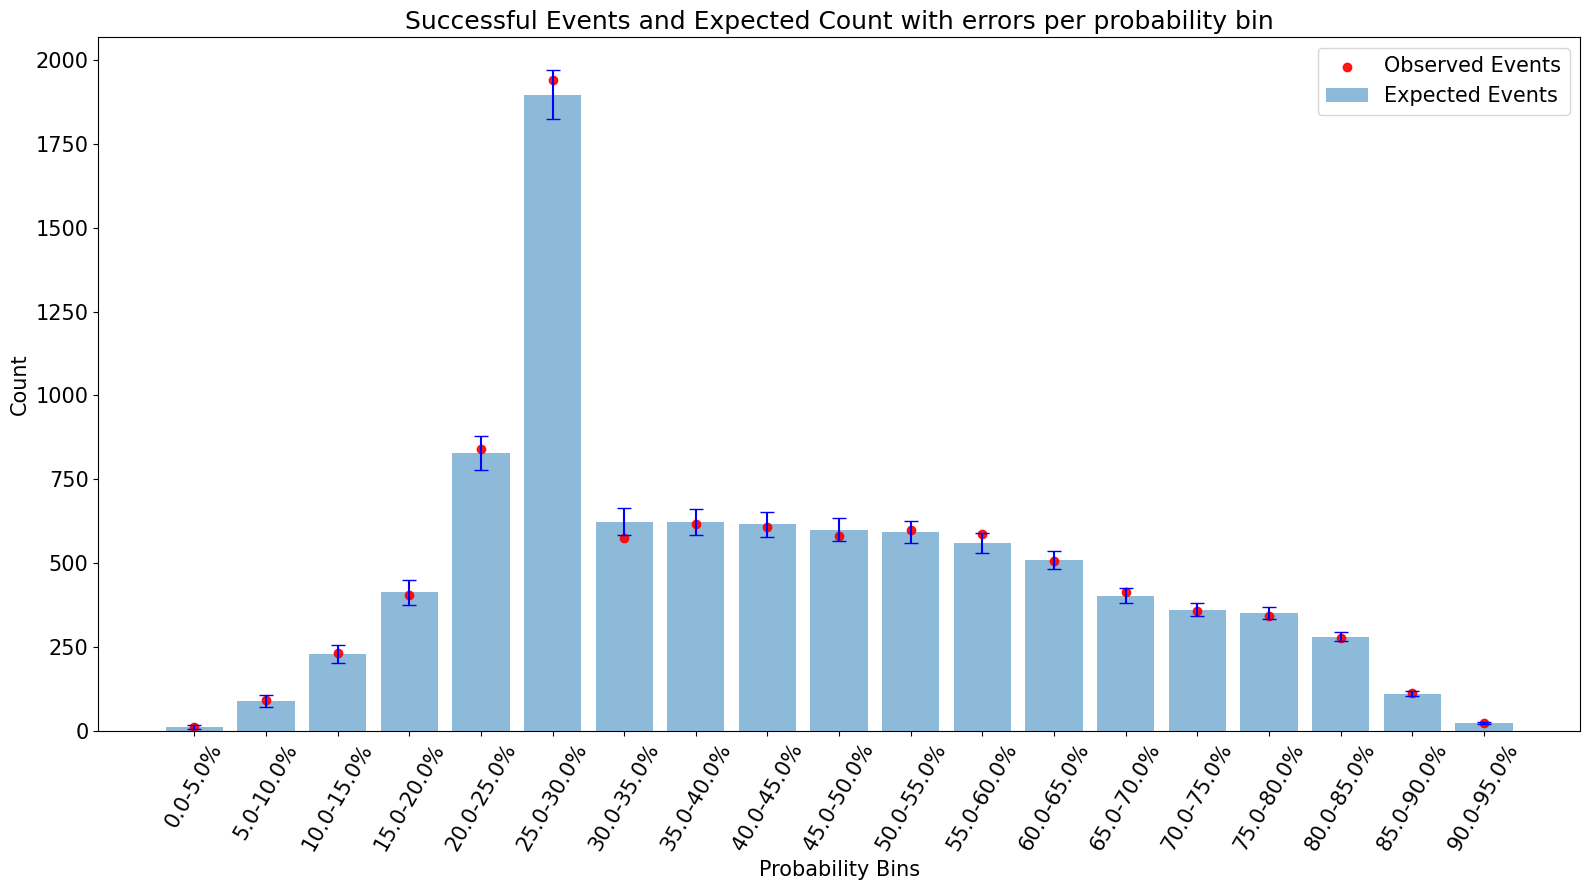

In [68]:
y_errors=[expected_v_observed['Lower Error'],expected_v_observed['Upper Error']]
fig,ax = plt.subplots(figsize=(16,9))
ax.bar(expected_v_observed['Implied Probability Bins'],expected_v_observed['Expected Events'],yerr=y_errors,alpha=0.5,label='Expected Events',
      capsize=5,ecolor='blue')
ax.scatter(expected_v_observed['Implied Probability Bins'],expected_v_observed['Observed Events'],label='Observed Events',color='red',alpha=0.9)
ax.set_xlabel('Probability Bins',fontsize=15)
ax.set_ylabel('Count',fontsize=15)
ax.set_title('Successful Events and Expected Count with errors per probability bin',fontsize=18)
plt.xticks(rotation=60)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

This plot shows the expected events with an error attached along with the observed events, whereby the error represents the standard deviation of each bin. If the number of observed events falls outside the range of the expected events this could resemble potential miscalibration as the way the error bars were calculated was throguh 1.96 x the standard deviation, meaning that under 5% of the time the number of observed events fall outside of the range, resembling this to be highly unlikely due to chance.

To caclulate the expected success I summed all the probabilities in each probability bin but initially I did the median multiplied by the total count. I changed from this approach as the former approach assumes that the median value is representative of every observation and in reality this is not the case and this introduces bias when probabilities are not symmetrically distributed.

In [69]:
# expected_v_observed

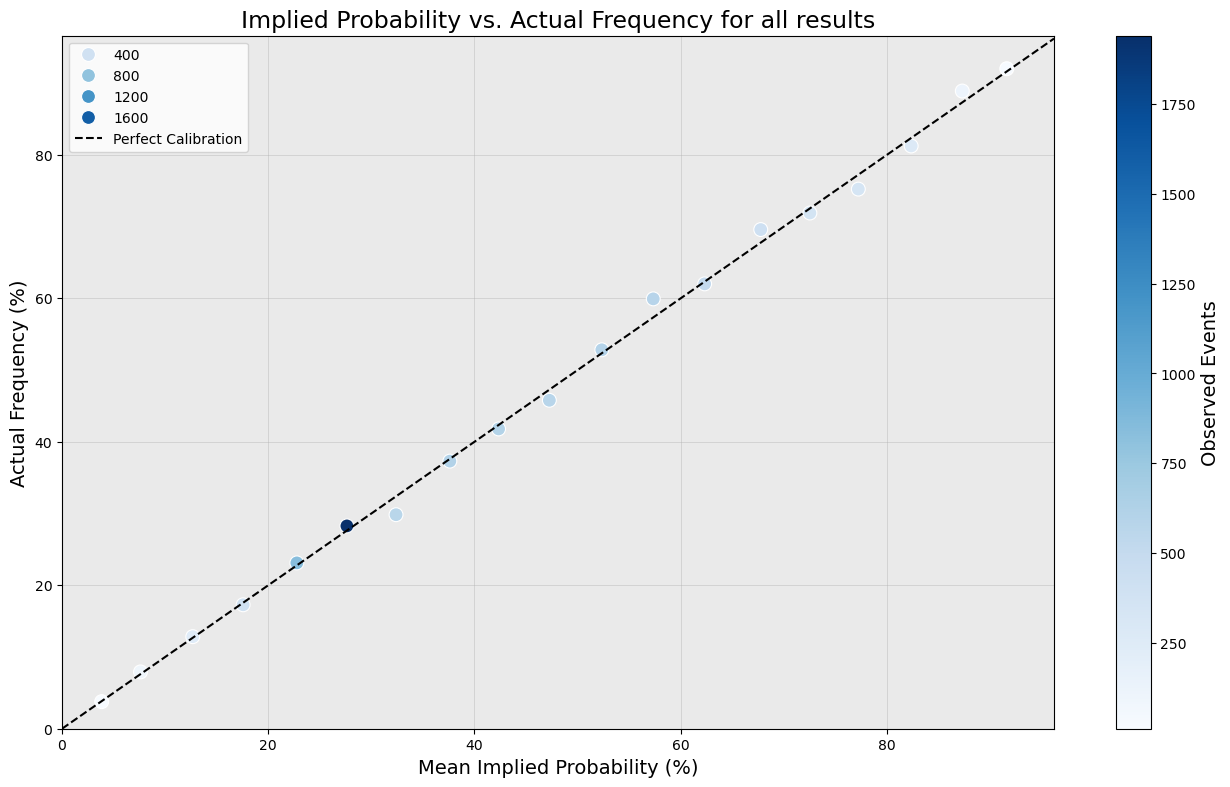

In [70]:
fig,ax = plt.subplots(figsize=(16,9))
ax = sns.scatterplot(data=expected_v_observed,x='Mean Implied Probability (%)',y='Actual Frequency (%)',hue='Observed Events',s=100,palette='Blues')
ax.set_xlabel('Mean Implied Probability (%)',fontsize=14)
ax.set_ylabel('Actual Frequency (%)',fontsize=14)
ax.set_title('Implied Probability vs. Actual Frequency for all results',fontsize=17)
plt.axline((0, 0), slope=1, color="black", linestyle="--",label='Perfect Calibration')
norm = mpl.colors.Normalize(
    vmin=expected_v_observed['Observed Events'].min(),
    vmax=expected_v_observed['Observed Events'].max()
)
sm = mpl.cm.ScalarMappable(norm=norm,cmap='Blues')
sm.set_array([])
cbar = fig.colorbar(sm,ax=ax)
cbar.set_label('Observed Events',fontsize=14)
ax.set_facecolor('#EAEAEA')
ax.grid(True, which='major',linestyle='-',linewidth=0.7,alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.legend()
save_figure(fig, 'calibration-all-outcomes')
plt.show()

This shows the calibration plot for all results across each probability bin, meaning each probability bin represent home, away and draw events rather than just one of them. As you can see the calibration across all results for each bin is almost perfect with every point either on or very close to being on the perfect calibration line. What is interesting though is that the lowest 2 and the highest 2 probabilitiy bins deviate from the line slightly but in opposite directions. The lowest 2 bins are slightly under the lie, meaning the bookmaker overestimates how often events at these prices occur and the 2 highest probability evets are above the line which represents underestimation. The underestimation of higher probability bins could possibly signify the bookmaker to be losing money here. They may price events to occur at 90% but actually happen at a rate of 91% meaning that if someone risked £10 per bet over 1000 events with an implied probability of 90% that occur 91% of the time the total staked is £10,000 and the returns would be 1000 x 0.91 x $\frac{1}{0.90}$ x 10 ~ £10,111 and therefore a profit of ~£111 over 1000 bets which is very small but it is still a loss for the bookmaker and a gain for the bettor over the long-term. This assumes averages though and also looking at the colour scale it appears that in the 90-95% probability bin around maybe 30 events occur so if they did truely miscalibrate this probability bins the losses could be on the order of pennies over the 24 seasons. Negligible.

In [71]:
expected_v_observed['Distance from Perfect Calibration'].abs().mean(),expected_v_observed['Distance from Perfect Calibration'].abs().sum()

(np.float64(0.926826136909268), np.float64(17.60969660127609))

These 2 values represent the average distance from the perfect calibration line and the sum of absolute distances of all bins from perfect calibration. The first value shows a 0.93% average absolute difference between actual frequency and mean implied probability per probability bin which is quite small and is a sign of decent calibration across all probability bins for all events that took place. Then the total absolute distance of 17.61% shows that across all bins the total difference between the points' locations and perfect calibration is 17.61% and in combination with the mean absolute value of 0.93% shows that all 20 bins contribute the same amount to the small deivation from perfect calibration. 17.61% cumulatively is quite large and could signifiy somewhat poor calibration.

In [72]:
# computed directly from the columns so this cell does not depend on the
# per-outcome sections further down
errors_total = pd.concat([
    (all_seasons['FTR'] == 'H').astype(int) - all_seasons['B365H_prob'],
    (all_seasons['FTR'] == 'D').astype(int) - all_seasons['B365D_prob'],
    (all_seasons['FTR'] == 'A').astype(int) - all_seasons['B365A_prob'],
], ignore_index=True)

ME_total = errors_total.mean()
RMSE_total = np.sqrt((errors_total ** 2).mean())

In [73]:
print(ME_total, RMSE_total)

1.3654769323043263e-14 0.4365598415125522


So the mean error value here is $\approx$ 0 which is expected. For each fixture the implied probability of a home win, draw or away win should be 1 and one of these outcomes will occur and as the error is determined through looking at the difference between the actual and implied probability this should just be 1-1 which is 0. So ME $\approx$ 0 here is more of a sanity check rather than anything new.
The root mean squared error being ~0.437 resembles the overall magnitude of the calibration error and this is a very small value which could signify very good overall calibration by the bookmaker. It indicates a very small overall difference between observed frequencies and the implied probabilities.

No combined chi-squared test is reported here, and the earlier one has been removed.

Every fixture contributes three rows to this table - a home, a draw and an away - and exactly one of them succeeds, so the three are perfectly dependent. That breaks the independence assumption stated above, and inflates the effective sample by a factor of three. There is no degrees-of-freedom correction that repairs it.

Calibration across all outcomes is therefore assessed from the plot and the per-bin differences above, and formally tested per outcome in the sections that follow.

#### Per Season Analysis for all results

In [74]:
def df_construction_for_season(s:str):
    '''
    Constructs the data frame correctly to ensure it is ready for plotting. Does this depending on the season chosen.

    String inputted for the season must be in the form of yyYY. For example, the 2021/2022 season would be '2122'.
    '''
    season = all_seasons_copy[all_seasons_copy['Season'] == s]

    bounds = pd.DataFrame({
    'Implied Probability Bins': labels,
    'Lower': edges[:-1],
    'Upper': edges[1:]
    })
    
    home_counts = season['Home Implied Probability Bins'].value_counts(sort=False).reset_index()
    home_counts_complete = home_counts.merge(bounds,left_on='Home Implied Probability Bins',right_on='Implied Probability Bins',how='left')
    
    draw_counts = season['Draw Implied Probability Bins'].value_counts(sort=False).reset_index()
    draw_counts_complete = draw_counts.merge(bounds,left_on='Draw Implied Probability Bins',right_on='Implied Probability Bins',how='left')
    
    away_counts = season['Away Implied Probability Bins'].value_counts(sort=False).reset_index()
    away_counts_complete = away_counts.merge(bounds,left_on='Away Implied Probability Bins',right_on='Implied Probability Bins',how='left')
    
    h = season.groupby(['Home Implied Probability Bins'],observed=False)[['B365H_prob']].mean().reset_index()
    d = season.groupby(['Draw Implied Probability Bins'],observed=False)[['B365D_prob']].mean().reset_index()
    a = season.groupby(['Away Implied Probability Bins'],observed=False)[['B365A_prob']].mean().reset_index()

    mean_probs_per_bin = (h.merge(d,left_on='Home Implied Probability Bins',right_on='Draw Implied Probability Bins',how='left').merge(
    a,left_on='Draw Implied Probability Bins',right_on='Away Implied Probability Bins',how='left'
    ))
    mean_probs_per_bin['Mean Implied Probability (%)'] = mean_probs_per_bin[['B365H_prob','B365D_prob','B365A_prob']].mean(skipna=True,axis=1)
    mean_probs_per_bin.drop(['B365H_prob','B365D_prob','B365A_prob','Draw Implied Probability Bins','Away Implied Probability Bins'],axis=1,inplace=True)
    mean_probs_per_bin.rename(columns={'Home Implied Probability Bins':'Implied Probability Bins'})
    
    new = (home_counts_complete.merge(away_counts_complete,left_on='Home Implied Probability Bins',right_on='Away Implied Probability Bins',how='left')
      .merge(draw_counts_complete,left_on='Home Implied Probability Bins',right_on='Draw Implied Probability Bins',how='left'))
    new['Number of events'] = new['count_x'] + new['count_y'] + new['count']
    new.drop(columns=['Implied Probability Bins_x','Away Implied Probability Bins','Implied Probability Bins_y','Draw Implied Probability Bins','Implied Probability Bins','count_x','count_y','count','Lower_x','Upper_x','Lower_y','Upper_y'],axis=1,inplace=True)
    new.rename(columns={'Home Implied Probability Bins':'Implied Probability Bins'},inplace=True)
    
    true_expected_counts = {}
    true_variances = {}
    for i in range(20):
        tot_e = tot_v = 0.0
        for pcol in ('B365H_prob','B365D_prob','B365A_prob'):
            p = season.loc[(season[pcol] >= edges[i]) & (season[pcol] < edges[i+1]), pcol]
            tot_e += p.sum()
            tot_v += (p*(1-p)).sum()
        true_expected_counts[labels[i]] = tot_e
        true_variances[labels[i]] = tot_v
    
    expected_counts = pd.DataFrame(true_expected_counts.items(),columns=['Implied Probability Bins','Expected Events'])
    expected_counts['Variance'] = list(true_variances.values())
    
    home_successes = (
        season[season['FTR'] == 'H']
        .groupby('Home Implied Probability Bins', observed=False)
        .size()
        .reindex(labels, fill_value=0)
    )
    
    draw_successes = (
        season[season['FTR'] == 'D']
        .groupby('Draw Implied Probability Bins', observed=False)
        .size()
        .reindex(labels, fill_value=0)
    )
    
    away_successes = (
        season[season['FTR'] == 'A']
        .groupby('Away Implied Probability Bins', observed=False)
        .size()
        .reindex(labels, fill_value=0)
    )
    
    successful_events = home_successes + draw_successes + away_successes
    
    expected_v_observed = new.merge(expected_counts,on='Implied Probability Bins',how='left')
    expected_v_observed['Observed Events'] = successful_events.values
    expected_v_observed['Expected Events'] = round(expected_v_observed['Expected Events'],0)
    expected_v_observed['Difference'] = expected_v_observed['Expected Events'] - expected_v_observed['Observed Events'] # To get by how many they were overpredicted by
    sd = np.sqrt(expected_v_observed['Variance'])
    expected_v_observed['Lower Error'] = np.minimum(1.96 * sd, expected_v_observed['Expected Events'])
    expected_v_observed['Upper Error'] = 1.96 * sd
    expected_v_observed.loc[expected_v_observed['Expected Events'] <5, ['Lower Error','Upper Error']] = np.nan
    expected_v_observed['Mean Implied Probability (%)'] = mean_probs_per_bin['Mean Implied Probability (%)']*100
    expected_v_observed['Actual Frequency (%)'] = 100*(expected_v_observed['Observed Events'] / expected_v_observed['Number of events'])
    expected_v_observed['Distance from Perfect Calibration'] = expected_v_observed['Actual Frequency (%)'] - expected_v_observed['Mean Implied Probability (%)']

    return expected_v_observed

# had to change actual frequency calc. to be observed in numerator

In [75]:
def calibration_plot_per_season(s:str):
    table = df_construction_for_season(s)
    fig,ax = plt.subplots(figsize=(16,9))
    ax = sns.scatterplot(data=table,x='Mean Implied Probability (%)',y='Actual Frequency (%)',hue='Observed Events',s=100,palette='RdYlGn')
    ax.set_xlabel('Mean Implied Probability (%)',fontsize=14)
    ax.set_ylabel('Actual Frequency (%)',fontsize=14)
    ax.set_title(f'Implied Probability vs. Actual Frequency for all results in season {s}',fontsize=17)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.axline((0, 0), slope=1, color="black", linestyle="--",label='Perfect Calibration')
    plt.legend()
    plt.show()

In [76]:
def errors_expected_vs_observed(s:str):
    '''
    Plot to see whether the observed counts fall within the expected counts range.
    '''
    table = df_construction_for_season(s)
    y_errors=[table['Lower Error'],table['Upper Error']]
    fig,ax = plt.subplots(figsize=(16,9))
    ax.bar(table['Implied Probability Bins'],table['Expected Events'],yerr=y_errors,alpha=0.5,label='Expected Events',
          capsize=5,ecolor='blue')
    ax.scatter(table['Implied Probability Bins'],table['Observed Events'],label='Observed Events',color='red',alpha=0.9)
    ax.set_xlabel('Probability Bins',fontsize=15)
    ax.set_ylabel('Count',fontsize=15)
    ax.set_title('Successful Events and Expected Count with errors per probability bin',fontsize=18)
    plt.xticks(rotation=60)
    ax.tick_params(axis='both',labelsize=15)
    plt.tight_layout()
    plt.legend(fontsize=15)
    plt.show()

##### Need these 2 plots above per result per season also

In [77]:
season_dropdown = widgets.Dropdown(
    options=sorted(all_seasons['Season'].unique()),
    description='Season:'
)

In [78]:
import ipywidgets as widgets
from IPython.display import display, clear_output

out = widgets.Output()

def update_df(change):
    with out:
        clear_output(wait=True)
        display(df_construction_for_season(change['new']))

season_dropdown.observe(update_df, names='value')

display(season_dropdown)
display(out)

Dropdown(description='Season:', options=('0203', '0304', '0405', '0506', '0607', '0708', '0809', '0910', '1011…

Output()

In [79]:
widgets.interactive(
    calibration_plot_per_season,
    season=season_dropdown
)

interactive(children=(Text(value='', description='s'), Output()), _dom_classes=('widget-interact',))

Per season looking at all the results it appears that the overall calibration is pretty good. There is very little deviation from the perfect calibration and the only significant deviations are from the more extreme bins with far less data points so these can sort of be 'ignored' when judging the calibration. I was expecting more deviations when looking at each season and there are not many noisy looking seasons. Now as this looks at all results this can somewhat be expected as if there is an underestimation for the home result and an overestimation for the away result (and vice versa as well) when the over or underestimation occurs it will offset the opposite occurring for the opposite result. This is why viewing per result is very important and mandatory.

In [80]:
widgets.interactive(
    errors_expected_vs_observed,
    season=season_dropdown
)

interactive(children=(Text(value='', description='s'), Output()), _dom_classes=('widget-interact',))

Now this plot displays different data to the calibration plot and the goal of it is to show if the observed event total falls within what is expected given the mean probability for each bin and it uses the upper and lower value of the bin. So if an observed value falls outside of the expected range this does not signify anything statistically significant straight away but it may potentially reveal that the underlying mean probability of the bin may be incorrect.

In [81]:
all_seasons_copy.groupby(all_seasons_copy['Date'].dt.month)[['B365H_prob','B365D_prob','B365A_prob']].agg(('mean','median','std')).reset_index()

Date B365H_prob                     B365D_prob                      \
              mean    median       std       mean    median       std   
0     1   0.450660  0.445028  0.199708   0.244506  0.261780  0.051451   
1     2   0.448055  0.446943  0.192795   0.246730  0.265370  0.048689   
2     3   0.452554  0.441886  0.192036   0.247109  0.261764  0.047493   
3     4   0.456324  0.448692  0.189845   0.245256  0.264186  0.049555   
4     5   0.464181  0.450724  0.204104   0.231916  0.249534  0.052674   
5     6   0.400216  0.328417  0.208488   0.244758  0.262884  0.054128   
6     7   0.417318  0.421366  0.226111   0.232576  0.252918  0.062664   
7     8   0.453268  0.427209  0.200540   0.245195  0.267460  0.053487   
8     9   0.447981  0.432941  0.193971   0.247740  0.266851  0.050152   
9    10   0.454684  0.447238  0.191857   0.246339  0.263313  0.049495   
10   11   0.451271  0.436912  0.188935   0.248121  0.266961  0.047924   
11   12   0.453658  0.435724  0.205550   0.240928  0.258900  0.052753   

   B365A_prob                      
         mean    median       std  
0    0.304834  0.272004  0.179291  
1    0.305215  0.270873  0.175953  
2    0.300336  0.268962  0.176460  
3    0.298420  0.269039  0.171231  
4    0.303903  0.275368  0.183572  
5    0.355025  0.391333  0.177514  
6    0.350106  0.293789  0.207757  
7    0.301537  0.286407  0.177249  
8    0.304279  0.285847  0.173492  
9    0.298977  0.269039  0.171832  
10   0.300608  0.276956  0.169951  
11   0.305414  0.282412  0.183756

Just by looking at the table above if we exclude the months of June and July we can see that across all seasons the average implied probability for each result is pretty much the same across all months. There is very little variation in the averages across all results excluding June and July.

## Home Analysis

In [82]:
season_dropdown = widgets.Dropdown(
    options=sorted(all_seasons['Season'].unique()),
    description='Season:',
    value=sorted(all_seasons['Season'].unique())[0]
)

In [83]:
def plot_season_home(season):
    
    filtered_df = home_results[home_results['Season'] == season]
    filteredx2_df = filtered_df['Implied Probability Bins'].value_counts(sort=False).reset_index()
    
    plt.figure(figsize=(10, 6))
    
    plt.bar(filteredx2_df['Implied Probability Bins'],filteredx2_df['count'])
    median = filtered_df['B365H_prob'].median()
    mean = filtered_df['B365H_prob'].mean()
    x_med_pos = median*20 # 20 bins
    x_mean_pos = mean*20
    plt.axvline(x=x_med_pos,linestyle='--',color='lime',label=f'Median: {median:.2%}')
    plt.axvline(x=x_mean_pos,linestyle='--',color='red',label=f'Mean: {mean:.2%}')
    
    plt.xlabel('Probability Bins',fontsize=14)
    plt.ylabel('Count',fontsize=14)
    plt.tight_layout()
    plt.xticks(rotation=60)
    plt.yticks(range(0,filteredx2_df['count'].max()+5,4))
    plt.title(f'{season} season',fontsize=14)
    plt.legend()
    plt.show()

In [84]:
widgets.interactive(plot_season_home, season=season_dropdown)

interactive(children=(Dropdown(description='Season:', options=('0203', '0304', '0405', '0506', '0607', '0708',…

The above plot shows the distribution of the implied probability for all games within each season that ended up being a home win along with the mean and median value of the implied probability. What I noticed here is that in the earlier seasons up until around the covid era the mean was consistently above the median by ~2% excluding 1 or 2 seasons where median $\approx$ mean. After the covid era the mean and median are much closer, differing by less than 1%. This could resemble a potential shift in how Bet365 priced the 1X2 market after covid. The 20/21 season with no fans in terms of looking at the mean and median was a clear outlier. The mean sat almost 3% lower than the median home win implied probability, showing the bookmaker to be assigning slightly lower odds to home favourites this season which makes sense because the crowd did not play a role in any game this season so away teams likely would have been less intimidated.

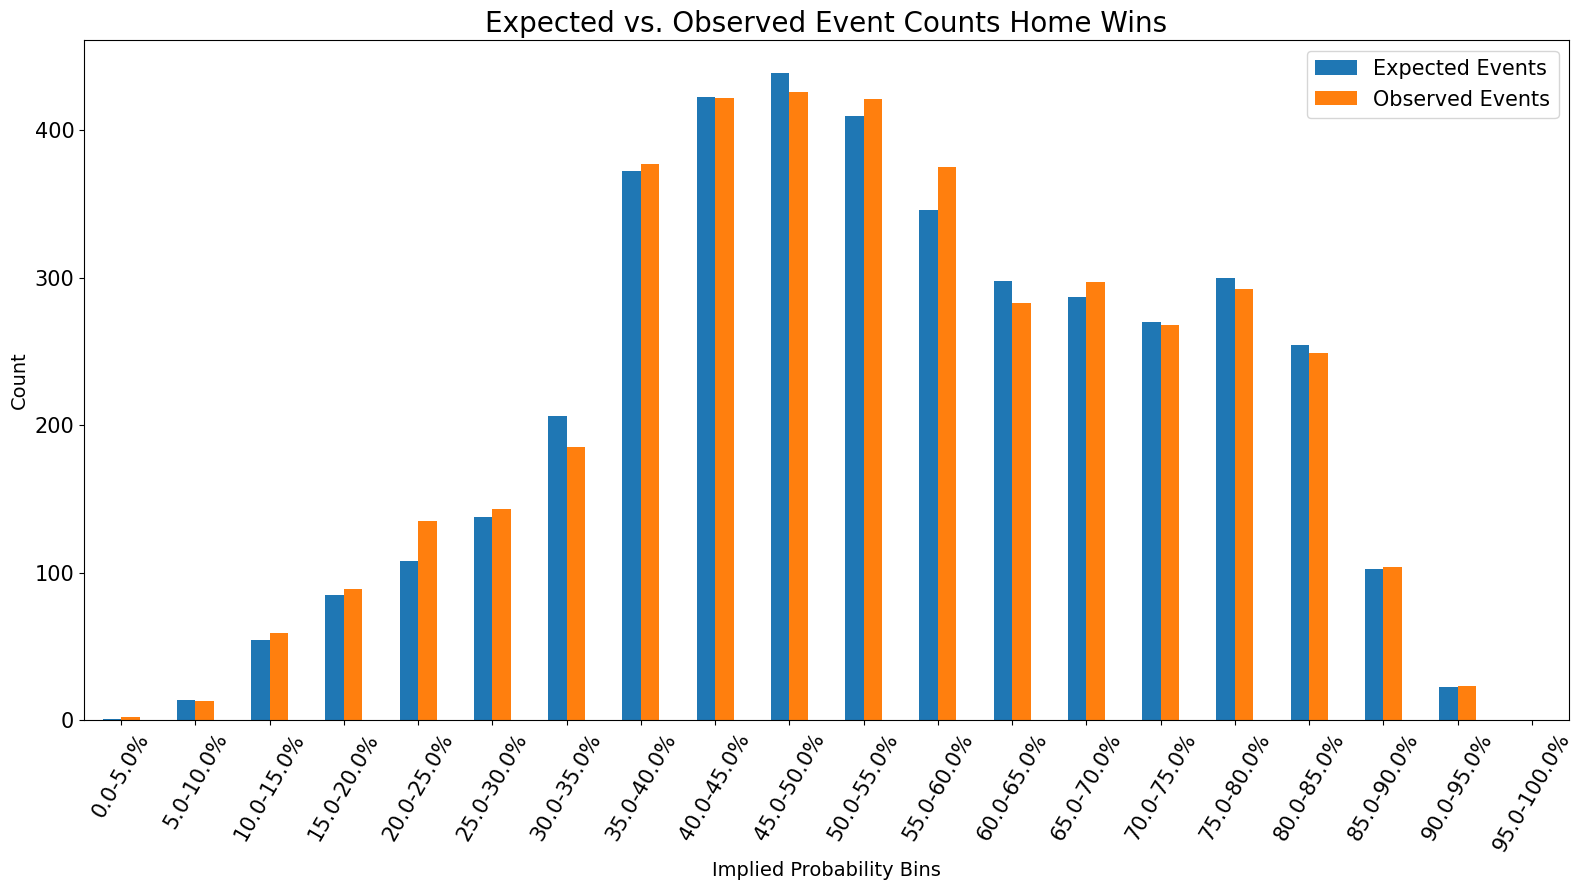

In [85]:
ax = b365h_final.plot(x='Implied Probability Bins',y=['Expected Events','Observed Events'],kind='bar',figsize=(16,9),rot=60,fontsize=13)
ax.set_xlabel('Implied Probability Bins',fontsize=14)
ax.set_ylabel('Count',fontsize=14)
ax.set_title('Expected vs. Observed Event Counts Home Wins',fontsize=20)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

Across the whole dataset there does not appear to be anything 'outstanding' for home results looking at this view of the data. The only potentially significant section of the chart is within the 55-60% bin whereby the observed events are quite noticeably more than the expected events which could potentially reveal some miscalibration here but just looking at this it is hard to tell.

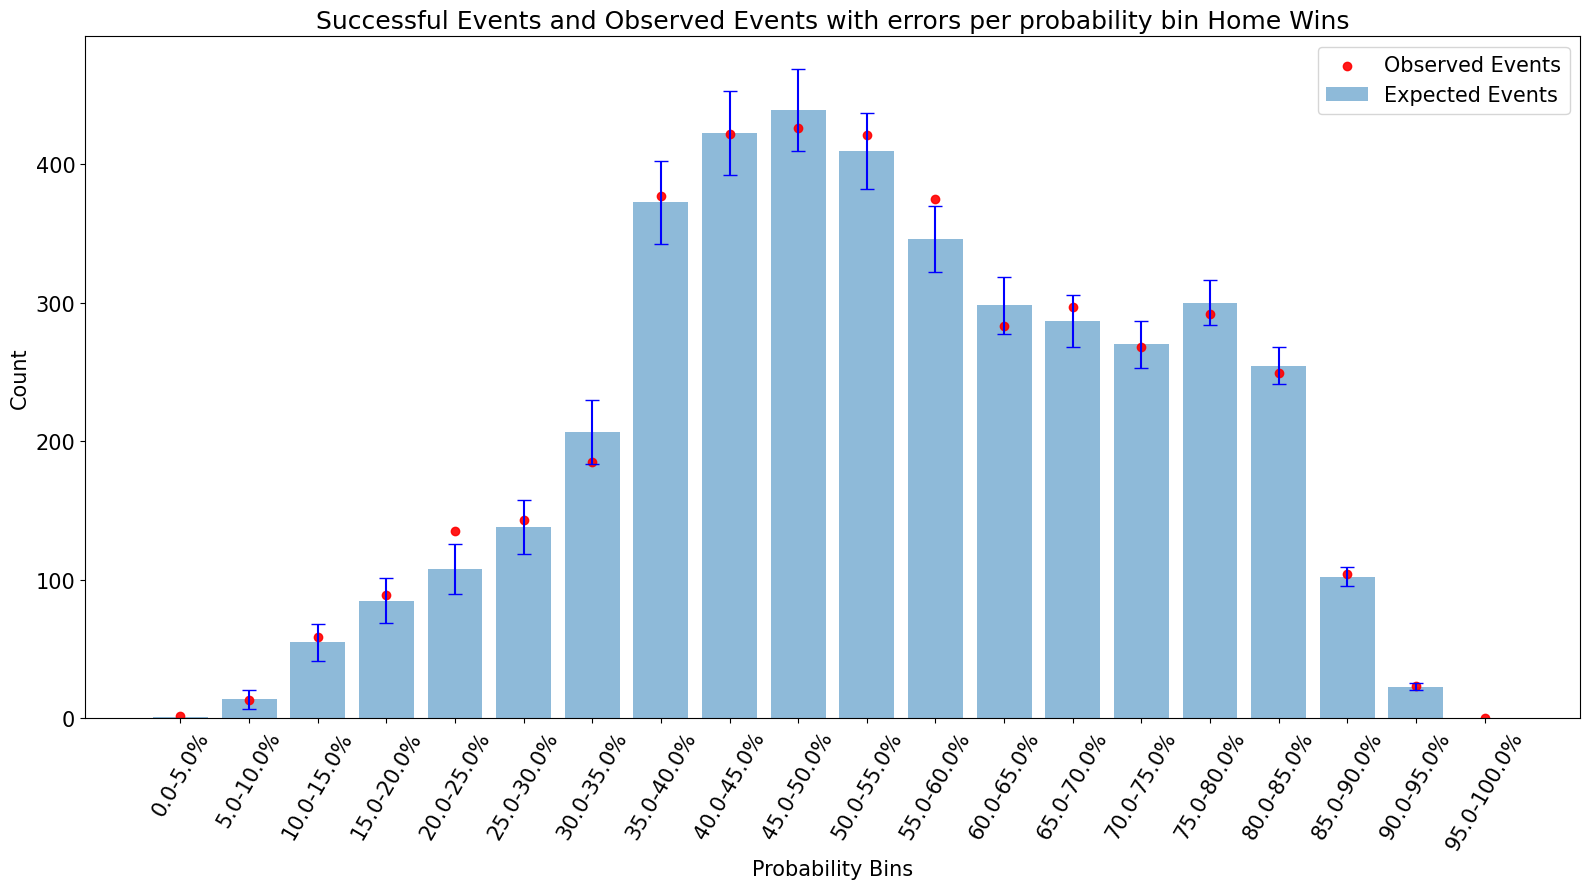

In [86]:
y_errors=[b365h_final['Lower Error'],b365h_final['Upper Error']]
fig,ax = plt.subplots(figsize=(16,9))
ax.bar(b365h_final['Implied Probability Bins'],b365h_final['Expected Events'],yerr=y_errors,alpha=0.5,label='Expected Events',
      capsize=5,ecolor='blue')
ax.scatter(b365h_final['Implied Probability Bins'],b365h_final['Observed Events'],label='Observed Events',color='red',alpha=0.9)
ax.set_xlabel('Probability Bins',fontsize=15)
ax.set_ylabel('Count',fontsize=15)
ax.set_title('Successful Events and Observed Events with errors per probability bin Home Wins',fontsize=18)
plt.xticks(rotation=60)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

Here we can see what the expected events may be given the error bars to account for the binning and then I overlaid the observed events to see if they were within the range of expected events. Assuming perfect calibration, it is expected that all of the points for the observed events should be within the error bar for each bin but evidently this is not the case for 4 of the bins. 30-35% and 60-65% show the observed event count here to be just below the acceptable range, highlighting that the bookmaker overestimated the number of events that will be successful in these bins. This is not an issue for the bookmaker as if they say an event occurs 50% of the time and it actually occurs 45% of the time then for a bettor there is a negative expected value here. But the other 2 bins is where potentially harmful miscalibration exists. In the 20-25% in and the 55-60% bin the observed events count is above the acceptable range quite noticeably. The observed count is 12.5% above the upper limit in the 20-25% bin and 3.6% for the 55-60% bin. This type of observation can be very significant as if an event occurs at a rate more than the bookmaker anticipates in the long-run then this produces positive expected value for the bettor and means the bookmaker would likely lose money. This alone though is not sufficient to state whether there is miscalibration.

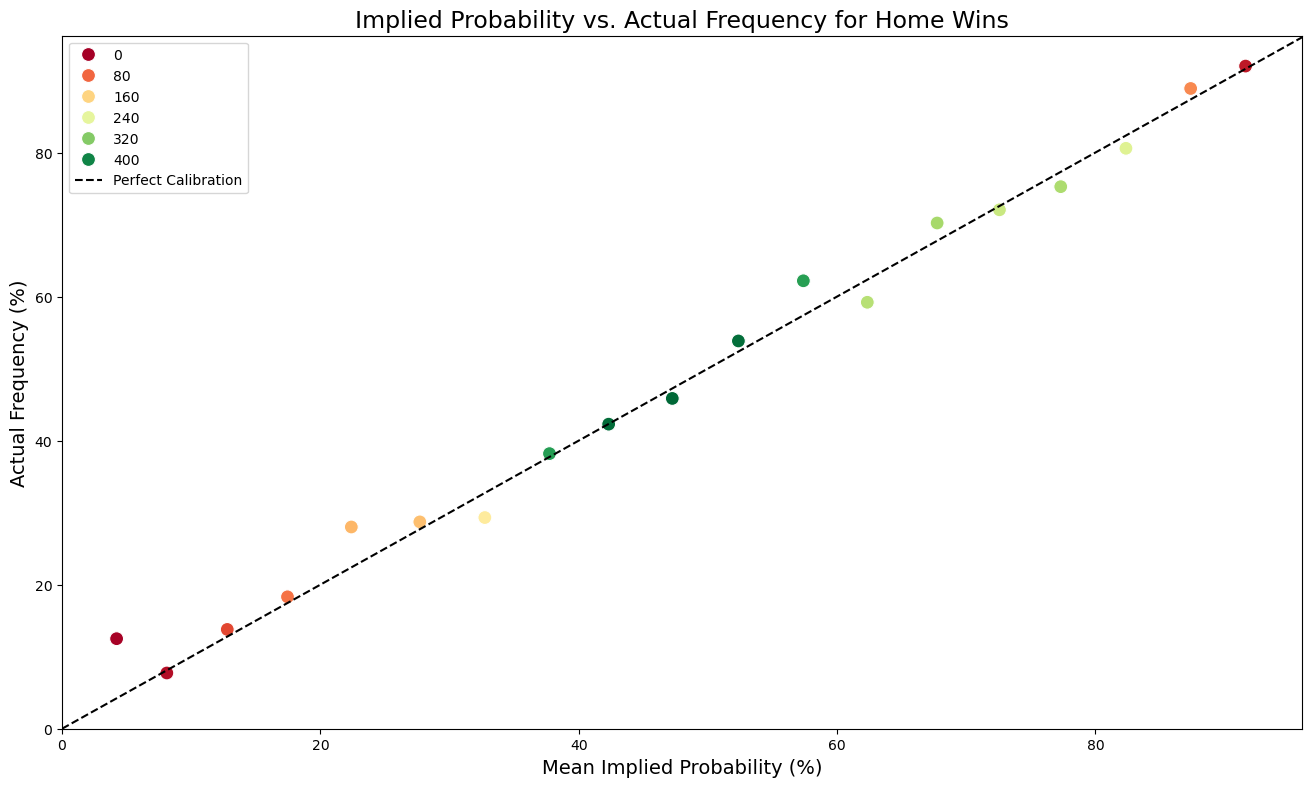

In [87]:
fig,ax = plt.subplots(figsize=(16,9))
ax = sns.scatterplot(data=b365h_final,x='Mean Implied Probability (%)',y='Actual Frequency (%)',hue='Observed Events',s=100,palette='RdYlGn')
ax.set_xlabel('Mean Implied Probability (%)',fontsize=14)
ax.set_ylabel('Actual Frequency (%)',fontsize=14)
ax.set_title('Implied Probability vs. Actual Frequency for Home Wins',fontsize=17)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.axline((0, 0), slope=1, color="black", linestyle="--",label='Perfect Calibration')
plt.legend()
save_figure(fig, 'calibration-home')
plt.show()

This plot now shows wht perfect calibration should look like and what each bin's actual vs. implied probability is. One thing to note here is the mean implied probability for each bin was calculated by summing up all of the probabilities that 'landed' in the appropriate bin and divided by the number of probabilities there was so it is the most accurate way to get a mean implied probability for a bin of probabilities I could think of. For continuous values this would have been much easer and an implied probability would not have been needed to be found.

What each point represents is a probability bin's implied probability vs. actual frequency along with the number of data points present within them. Significant deviations from perfect calibration could represent a miscalibration from the bookmaker but other factors need to be considered before making this conclusion. Overall, the points are pretty close to the perfect calibration line with near equal numbers of points above and and below it. Points above the line represent events occurring more often than implied (underestimation)and points below the line represent events occurring less often than implied (overestimation). 

Underestimation, as discussed above, is more dangerous for a bookmaker than overestimation and as we can see here there are 3 points with quite significant upwards deviation which represent the 0-5% bin, 20-25% bin and 55-60% bin, 2 of which were flagged above. The 0-5% bin we can conclude straight away that this is due to a very low sample size as there were 2 observed events here and an expected total of 1 so this bin we can disregard really. The 25-30% bin however there were 135 observations in so this is more substantial but still a relatively small sample size and the 55-60% bin there were 375 bins which is a 'good' sized sample. Going back to the previous plots and looking at the differences between observed events and the upper limits to each bin there is a numerical difference of 15 events (12.5% difference) in the 25-30% bin and 13 (3.6% difference) in the 55-60% binThese observations need to be taken into context first as this dataset spans 24 seasons so on average there are 11 observed every 2 seasons for the 25-30% bin and just under 16 observed events for the 55-60% bin per season. So in terms of 'interesting' bins to keep an eye on here would definitely be the 25-30% and 55-60% bins still for different reasons: the 25-30% percentage difference between the upper expected limit and the observed and then the 55-60% bin because of its size.

Assessing the other bins it can be seen that there are quite a few touching the line or have the line going through the point showing very good calibration but this alone cannot determine fully about calibration but it gives a good overall image: the bookmaker is quite well-calibrated for home results across the dataset but with a few potential areas of miscalibration.

We can quantify the 'miscalibration' here by taking the absolute distance between each point and the perfect calibration line and summing it up.

In [88]:
b365h_final['Distance from Perfect Calibration'].abs().mean(),b365h_final['Distance from Perfect Calibration'].abs().sum()

(np.float64(2.134720553818149), np.float64(40.55969052254483))

In [89]:
b365h_final['Distance from Perfect Calibration'][1:].abs().mean()

np.float64(1.793615121805759)

The mean absolute distance of 2.13% shows that on average each bin is 2.13% away from the perfect calibration line. This is quite significant as when we look at the odds later on this could represent a potential opportunity for bettors to make money using positive expected value beting. This could demonstrate overall miscalibration for home wins and we can examine exactly how much each bin contributes to this number using the table above. The table demonstrates that 3 bins contribute largely which was somewhat expected given the above analysis. 0-5%, 20-25% and 55-60% contribute nearly 50% of the total cumulative distance and contribute largely to the mean also. Excluding the 0-5% bin though as this has very few observations this value drops from 2.13% to 1.79% and shows slightly better calibration but still could be a sign of systematic miscalibration for home wins.

Then the cumulative absolute distance from perfect calibration is 40.56% and is quite large, possibly representative of miscalibration. This makes sense though looking at the plot as several points deviate quite significantly from perfect calibration. 

In [90]:
errors_home = (
    (all_seasons['FTR'] == 'H').astype(int)
    - all_seasons['B365H_prob']
)

ME_home = errors_home.mean()
RMSE_home = np.sqrt((errors_home ** 2).mean())

In [91]:
print(ME_home, RMSE_home)

0.0036748472624423675 0.4596690152536101


An ME of 0.0037 indicates that events occur 0.37% more than they are expected to which represents ~33 fixtures more than expected ended up as a home win. Out of 9120 fixtures, 33 more home wins than expected is not a huge amount but I would say that it is not negligible despite its very small percentage.

Then the RMSE value of 0.46 suggests that there are no bins that contribute a significant amount to the overall error, showing further evidence of the bookmaker being well-calibrated looking at the data through this lense.

In [92]:
chi_square_home, dof_home, p_value_home = calibration_chi2(combine_bins(b365h_final))

In [93]:
p_value_home, chi_square_home

(np.float64(0.06565606157951413), np.float64(25.242909702373712))

This p-value represents the probability of obtaining a chi-squared statistic at least as large as the one observed which is of interest here. This is 
saying if the expected counts were correct how likely would it be to see a chi-squared statistic of 25.21 purely or largely due to noise? This chi-squared statistic as it is across 18 probability bins it suggests that the difference between observed and expected counts is relatively small. This does not mean that the bookmaker is or is not properly calibrated though.

To reject the null hypothesis we will use the standard p-value of 0.05.

The p-value of 0.09 so we do not have enough evidence to reject the null hypothesis here but it is a 'relatively low' p-value especially in comparison to the other results.

#### Monthly Analysis

In [94]:
home_monthly_df = monthly_df_setup('home')

In [95]:
observed_events_by_month = home_monthly_df.groupby('Month')['Observed Events'].sum().reset_index()
observed_events_by_month = observed_events_by_month.sort_values(by='Observed Events',ascending=False)

In [96]:
heatmap_data = home_monthly_df.pivot(
    index='Implied Probability Bins',
    columns='Month',
    values='Observed Events'
)
month_order = [
    'August', 'September', 'October', 'November', 'December',
    'January', 'February', 'March', 'April', 'May'
]
heatmap_data = heatmap_data[month_order]

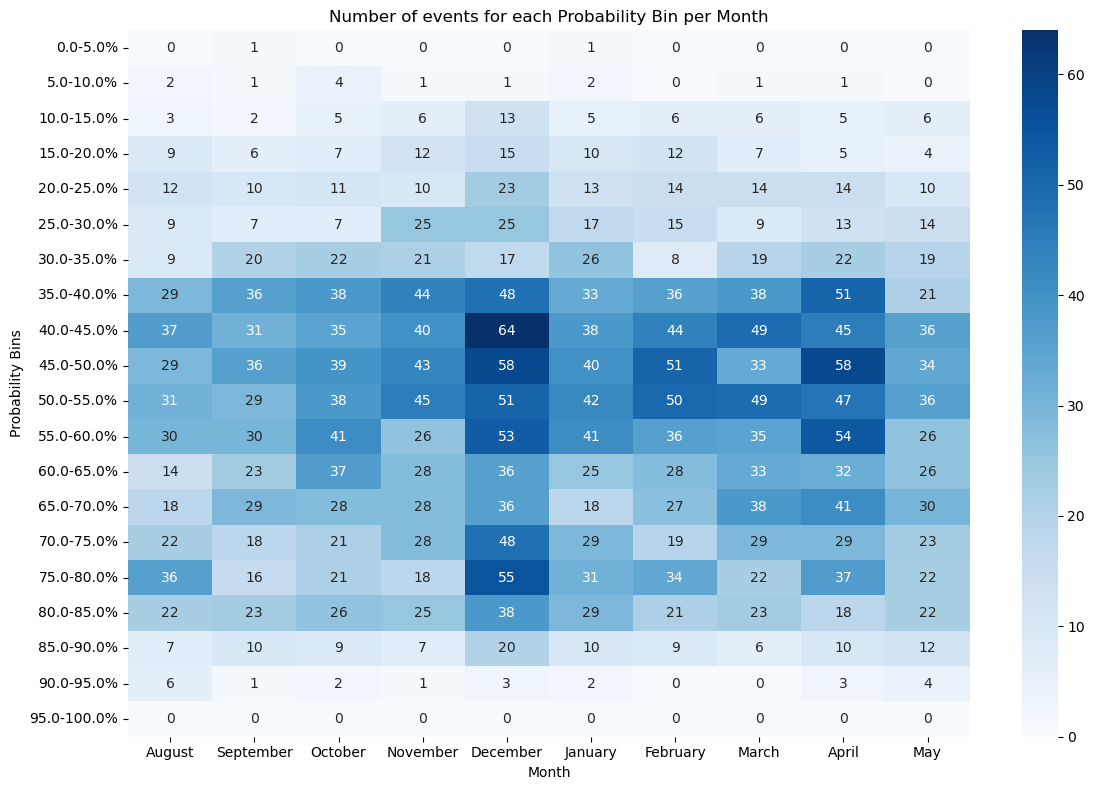

In [97]:
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data,annot=True,fmt='.0f',cmap='Blues')
plt.xlabel('Month')
plt.ylabel('Probability Bins')
plt.title('Number of events for each Probability Bin per Month')
plt.tight_layout()
plt.show()

This heatmap illustrates the count of events within each implied probability bin for each month across all home results. This was needed to reveal how different months have different counts which may help explain monthly plots and statistics drawn from monthly plots further down. An observation here is that the month of December has the most fixtures out of any month, shown by the larger number of dark blue cells. Then looking at the rows it is clear to see that the 2 most extreme probability bins have a combined count of 2 across all months. June and July were purposely excluded due to the fact that these months only have fixtures from the 19/20 season as a result of the covid lockdown and will produce noisy plots and results.

In terms of the probability bins, there is a clear concentration in the central bins compared to the 'tail' bins, hence the darker blue colour in the middle rows.

In [98]:
observed_events_by_month

,Month,Observed Events
2,December,604
0,April,485
4,January,412
7,March,411
3,February,410
9,November,408
10,October,391
8,May,345
11,September,329
1,August,325


In [99]:
monthly_bin_pct = heatmap_data.div(
    heatmap_data.sum(axis=0),
    axis=1
) * 100

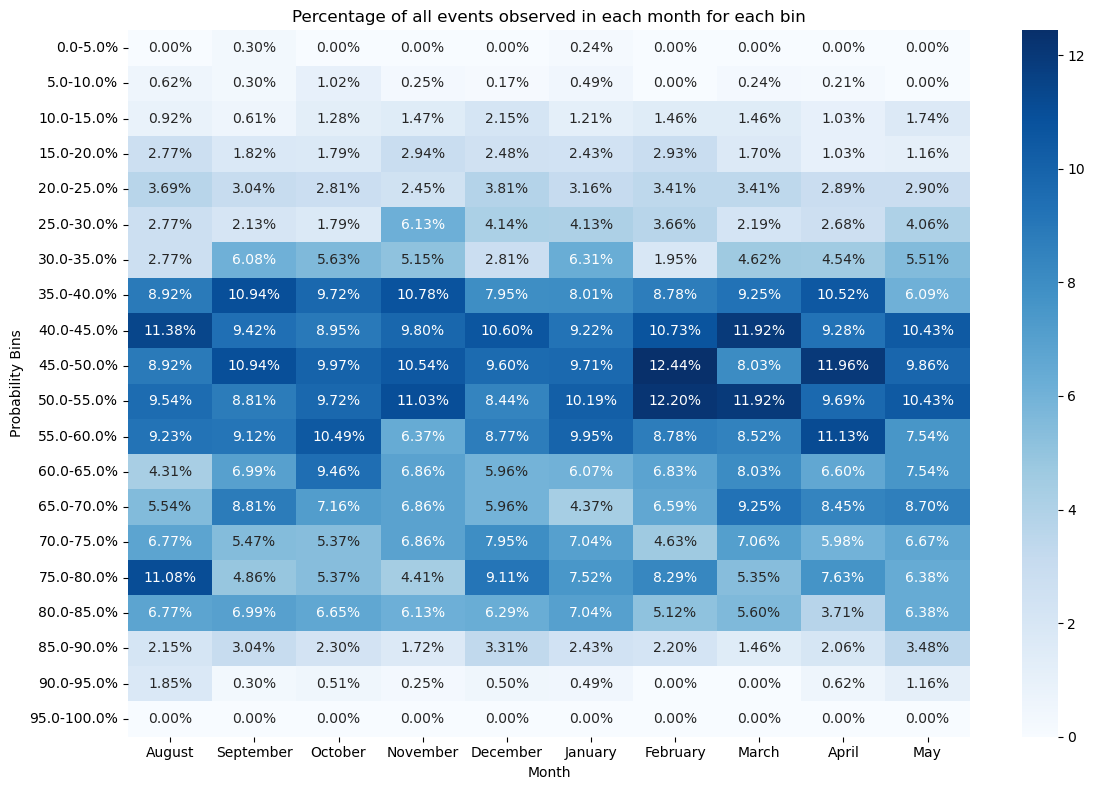

In [100]:
plt.figure(figsize=(12,8))
annot = monthly_bin_pct.map(lambda x: f'{x:.2f}%')
sns.heatmap(monthly_bin_pct,annot=annot,fmt='',cmap='Blues')
plt.xlabel('Month')
plt.ylabel('Probability Bins')
plt.title('Percentage of all events observed in each month for each bin')
plt.tight_layout()
plt.show()

This heatmap above is a percentage representation of the prior heatmap to display the percentage of counts assigned to each bin for each month. This was used to show if there were any abnormally large allocations to certain probability bins across all months (excluding June and July). For me it serves as a sort of pre-analysis to the calibration plots below to help potentially explain any large deviations from perfect calibration but this heatmap has to be used in conjunction with observed_events_by_month table above and the other heatmap as this shows the true count for each cell and the total count for each month. Some of the deviations in the calibration plots may be influenced by small sample sizes within individual month-probability bin combinations. The peceding heatmap and table therefore provide useful context by showing the raw numbers underlying each combination. However, the percentage-based heatmap may reveal whether the distribution of observed events across probability bins varies substantially between months which may help identify areas for further investigation for potential miscalibration.
One of the most noticeable observations is in the 75-80% bin. 11.08% of August's observed home wins were priced in this bin but then there is a dramatic drop off in the following 3 months going from 11.08% to 4.86% in September, 5.37% in October and 4.41% in November. This is also reflected in the counts: August has 36 then September has 16, October has 21 and November has 18. This could be due to several reasons. It could be due to a larger proportion of fixtures in August had stronger teams playing at home against and beating weaker teams resulting in more matches present in this bin. This is plausible in theory but the distribution of fixtures across multiple seasons is not likely to be similar and the matchup of strong and weak teams across a season could be its own analysis. More importantly though there are signs that there is a potential miscalibration. The actual frequency of events occurring in this probability bin in August was 81.8% which is outside of the bin's range and therefore is unexpected. The mean implied probability was 77.4%, 4.4% lower than the actual frequency which suggests the bookmaker may have underestimated the probability of home wins within this bin in August. This observation alone is insufficient to conclude that the bookmaker was systematically miscalibrating for the month of August. The relatively small sample size and the possibility of random variation mean that this should be interpreted with caution and further statistical analysis is required to fully explain this.

In [101]:
month_dropdown = widgets.Dropdown(
    options=month_order,
    description='Month:',
    value=month_order[0]
)

In [102]:
widgets.interactive(expected_vs_observed_by_month, result='home', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

Analysing these plots by looking at each month most months appear to have bimodality present. The peak count occurs between the 40-55% range and there is another peak between 70-80%. This is especially present in August, December, January and February. Three of these 4 months are consecutive... One thing to note about this bimodality is that is is not unexpected. Stronger teams playing at home against weaker teams will inevitably be assigned a higher implied probability which explains the clustering around 70-80%. Then for weaker teams playing at home they will have a lower implied probability for each game to win but due to the home advantage this probability will be larger and this explains the clustering around the 50% mark. Months that show less bimodality could be due to the fact that just purely by chance less stronger teams play weaker teams at home but this is likely flattened out over the course of 24 seasons but it may not have and this seems like a feasible explanation.

Looking at the differences in expected vs. observed counts there does not appear to be any noticeable pattern. The only noticeable/worth-noting observation is for the month of March. 13 of the 17 non-null probability bins have observed counts higher than the expected counts. So ~75% of the probability bins for March according to the probabilities set in each respective bin underestimate the number of successes. Underestimation is a worse issue for bookmakers than overestimation as I have explained several times here. The fact that 13 of the 17 non-null bins for March show the bookmaker to underestimate could be a sign of miscalibration for the month of March. 
Then there are months with 50% of their probability bins showing overestimation so across the whole dataset this likely balances out the underestimations that are frequent in other months. But the conclusion here is that per-month it is quite noisy the expected vs. observed counts and overall there is a lot less noise as shown by the same plot not filtered by month.

In [103]:
widgets.interactive(expected_vs_actual_w_ranges, result='home', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

This plot is another version of the plot above with slightly more and different detail. This shows whether the observed number of events is within the range of expected events to be observed and could signify where and how the bookmaker may be miscalibrating but more clearly. If the observed events fall outside of the error bar displayed then this can be considered a probability bin potentially miscalibrated. Most months display an observed count outside of the expected range. Some bins in some month are dramatically over the count and some others are largely below the so overall it appears to balance out and this seems to be a common theme. One comment I will make is that quite a few bins in quite a few months have very low counts and so the plot cannot be trusted as well for these bins, specifically bins with a count of less than 5. If this is the case then the bin(s) with less than 5 counts will be combined with an adjacent bin. But a final comment here is that yes it does look like there is miscalibration in many bins for many of the months but the bins with lower counts especially should not be taken 'as seriously' as the bins with the largest counts that have an observed value outside the expected range.

In [104]:
widgets.interactive(monthly_calibration, result='home', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

The calibration plots month-to-month show a lot of deviation from perfect calibration. Most of this though is likely due to the fact that sample sizes for certain points are very small. There are large deviations from perfect calibration in the tail ends and these are the points with the smallest sample sizes. Points that are more central to the plot are closer to the line but are still deviating somewhat significantly from perfect calibration. Months like December are the most 'accurate' here as each point consists of larger sample sizes relative to the same bins in other months. but there is a clear conclusion that can be drawn here: the calibration month-to-month appears miscalibrated but this is very likely due to small sample sizes. Collecting data across several leagues would improve the quality of this plot greatly and be much more revealing about the bookmaker's calibration month-to-month.

In [105]:
monthly_metrics_df = pd.DataFrame({
    month: monthly_metrics for d in compute_monthly_metrics('H') for month, monthly_metrics in d.items()
}).T # converts a list of dictionaries with nested dictionaries into a dataframe
monthly_metrics_df = monthly_metrics_df.reset_index()
monthly_metrics_df.rename(columns={'index':'Month'},inplace=True)

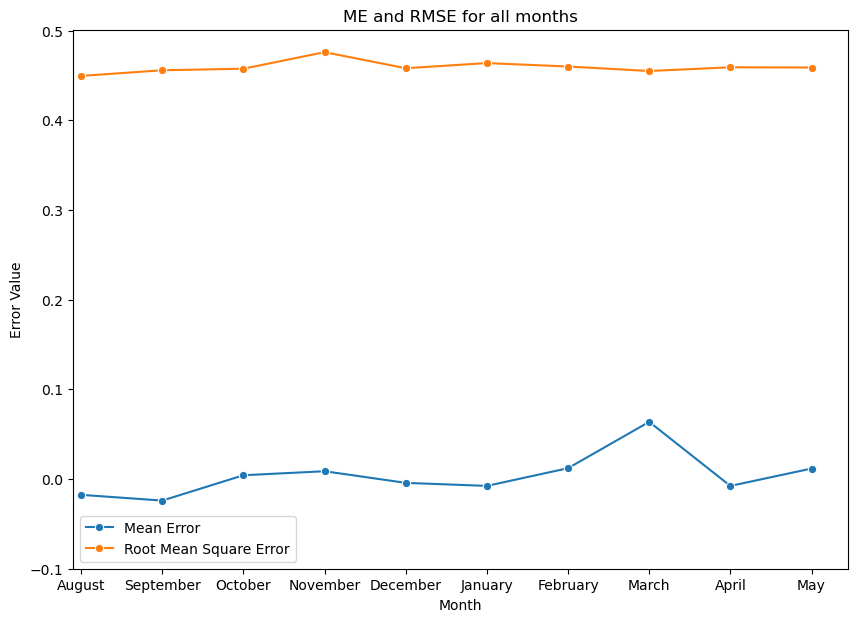

In [106]:
fig,ax = plt.subplots(figsize=(10,7))
ax = sns.lineplot(data=monthly_metrics_df,x='Month',y='Mean Error',marker='o',label='Mean Error')
ax = sns.lineplot(data=monthly_metrics_df,x='Month',y='Root Mean Square Error',marker='o',label='Root Mean Square Error')
ax.set_ylabel('Error Value')
ax.set_title('ME and RMSE for all months')
ax.set_xlim(left=-0.1)
ax.set_ylim(bottom=-0.1)
save_figure(fig, 'monthly-error-home')
plt.show()

The mean error is considerably lower than the RMSE which is expected due to the fact that positive and negative errors of the same scale cancel one another out. The mean error for March is much larger than the other months as shown in the chart. It is roughly 3 times larger in magnitude than the next largest magnitude value which is in September. With regards to March there is nothing unusual that is shown by the heatmaps and the sample size ranks the 4th highest (1 count behind 3rd) so it is unlikely this is due to an abnormally small sample size. But, if we look at the 2 plots displaying expected vs. observed counts for March this matches the story told here more closely. I noted that 13 of the 17 non-null probability bins for March had a larger observed value than expected when plotting observed count with expected count but when plotting the expected count with an error bar to capture the acceptable range for expected count there was only a single bin that had its observed value outside of the standard deviation so it is unclear exactly what is causing this deviation given the prior analysis and data available here.

In [107]:
p_values_home = {}
for month in month_order:
    p_values_home[month] = chi_squared_per_month(month,'home')

In [108]:
p_values_df_home = pd.DataFrame([p_values_home])
p_values_df_home.index = ['p-value']

In [109]:
p_values_df_home

,August,September,October,November,December,January,February,March,April,May
p-value,0.435235,0.190732,0.385455,0.208736,0.450877,0.606994,0.78264,0.032027,0.39975,0.333482


In [110]:
effect_sizes_home = {}

for month in month_order:
    effect_sizes_home[month] = effect_size_per_month(month, 'home')
effect_sizes_df_home = pd.DataFrame(
    [effect_sizes_home],
    index=['Effect Size']
)

In [111]:
effect_sizes_df_home

,August,September,October,November,December,January,February,March,April,May
Effect Size,0.152891,0.153412,0.143157,0.152638,0.115375,0.109238,0.113407,0.090405,0.118136,0.140541


As you can see the p-values are very high here, meaning that the null hypothesis definitely cannot be rejected based on these. The fact that they are very high is due to several reasons. The actual chi-squared statistic is low for every bin due to the fact that there is a small total difference between the observed and expected values in every bin. This sample size for each bin is small as well and with more data for each bin the difference and therefore chi-squared values may have been larger, producing a lower p-value. As all the p-values are large here we will look at them reltive to each other. The p-value for March is much lower than all the other months and November is quite low relative to the others also which is reflected in the 3 metric plot with March having the largest mean error by far and then November having the joint second highest mean error value. Nothing more is revealed here really and the p-values would have been more insightful if the sample sizes were larger for each bin within each month.

### Odds Analysis

Everything up until this point has looked at just the implied probabilities but now I will assess the actual odds to see if there was any potential to make profit given the calibration of the bookmaker and the rate of occurrence compared to the mean implied probability. A positive expected value is when for every £1 risked the return in the long-run is more than £1 and negative expected value is when the return per £1 staked is less than £1. For a bettor they desire a positive expected value.

We will look at the profitability of betting a £10 stake on every game in every bin to assess what the profit for a bettor would have been. This assumes no cash out, no early payouts and the bets were placed before the games had started. This calculation uses the actual odds for each game rather than averaging out the odds for each bin also so it is the most accurate profitability calculation.

In [112]:
home_odds = profitability_calc('home')

In [113]:
home_odds

,Implied Probability Bins,Number of bets placed,Successful Bets,Expected Successful Bets,Difference,Variance,Lower Error,Upper Error,Mean Implied Probability (%),Actual Frequency (%),Distance from Perfect Calibration,Average Odds,Total_Profit,ROI (%)
0,0.0-5.0%,16,2,0.676061,-1.323939,0.647164,NaN,NaN,4.225382,12.500000,8.274618,17.000000,180.00,112.500000
1,5.0-10.0%,168,13,13.631355,0.631355,12.499240,6.929436,6.929436,8.113902,7.738095,-0.375806,9.807692,-405.00,-24.107143
2,10.0-15.0%,428,59,54.747350,-4.252650,47.647988,13.529394,13.529394,12.791437,13.785047,0.993610,7.110169,-85.00,-1.985981
3,15.0-20.0%,486,89,84.826453,-4.173547,69.925343,16.389789,16.389789,17.454003,18.312757,0.858754,5.231416,-204.04,-4.198354
4,20.0-25.0%,482,135,107.943631,-27.056369,83.659976,17.927302,17.927302,22.394944,28.008299,5.613355,4.092296,704.60,14.618257
5,25.0-30.0%,498,143,137.933947,-5.066053,99.631411,19.563845,19.563845,27.697580,28.714859,1.017280,3.405874,-109.60,-2.200803
6,30.0-35.0%,631,185,206.533061,21.533061,138.808500,23.092136,23.092136,32.731071,29.318542,-3.412529,2.905297,-935.20,-14.820919
7,35.0-40.0%,987,377,372.446348,-4.553652,231.702688,29.834695,29.834695,37.735192,38.196555,0.461363,2.523647,-355.85,-3.605370
8,40.0-45.0%,998,422,422.302211,0.302211,243.421511,30.579864,30.579864,42.314851,42.284569,-0.030282,2.265687,-418.80,-4.196393
9,45.0-50.0%,929,426,438.875127,12.875127,231.333308,29.810905,29.810905,47.241671,45.855759,-1.385912,2.037650,-609.61,-6.562002


In [114]:
total_profit = home_odds['Total_Profit'].sum()

In [115]:
total_profit

np.float64(-2693.59)

This is where it is shown if the bookmaker actually would have lost money if stakes were placed on every event present in this portion of the dataset on the home result. This is not representative of calibration though. As you can see the total profit if one bet £10 on every home result the total profit would have been -£2693.59. But, there are individual bins whereby profit is present with a decent sample size. The 20-25% and 55-60% bins are ones to take note of. The 20-25% has 482 bets placed and an ROI of 14.6% which is significant and showed a serious window of opportunity for bettors. This equates to ~20 bets per season across all the seasons present here. Then with the 55-60% bin there would have been 603 bets placed which is ~25 bets a season and would have an ROI of just over 5%. So betting both of these bins for home results would have returned a profit of ~£1010 from just under 1100 bets. Now the issue with this from a bettor's perspective is of course that this is in hindsight and knowing that these bins were profitable is unlikely but I will investigate this below and assess season by season to see if that is the case.

In [116]:
seasonal_profitability('home')

,Season,Total_Profit,Number_of_Bets,ROI (%)
0,0203,-102.47,380,-2.696579
1,0304,-389.32,380,-10.245263
2,0405,-208.50,380,-5.486842
3,0506,199.00,380,5.236842
4,0607,76.40,380,2.010526
5,0708,-296.00,380,-7.789474
6,0809,-180.30,380,-4.744737
7,0910,360.20,380,9.478947
8,1011,27.80,380,0.731579
9,1112,-152.30,380,-4.007895


In [117]:
seasonal_profitability('home')['ROI (%)'].mean(),seasonal_profitability('home')['ROI (%)'].max(),seasonal_profitability('home')['ROI (%)'].min()

(np.float64(-2.9534978070175435), 9.47894736842105, -18.410526315789475)

Above you can see these summary statistics of betting on the home results per season. The average ROI per season is ~ -3% with one season (09/10 season) having a 9.5% return on home bets and one season (24/25) returning -18.4%. So this does reveal there was plenty of seasonal opportunities to flat bet every game on the home team and win. There are 10 seasons where this 'strategy' produces a positive ROI with 4 of them being in a row between 16/17 and 19/20. Over these 4 seasons betting £10 on every game on the home team would have returned a total profit of £711. This is quite significant and it appears that the bookmaker realised this issue and adjusted their models as the proceeding 2 seasons the ROI was < -10% and a total loss for over £1000. What this does highlight is that there have been opportunities for profitability through flat betting strategies. This does not however resemble calibration capabilities as profitability is largely due to the overround present in the odds set and is why when I looked at calibration I assessed the underlying probabilities.

## Draw Analysis

Just a note before analysis is done for the draws: the draw is notorious for being extremely difficult to predict which is shown below by the probability bins populated. A draw is difficult to predict as neither team usually aims for a draw and random events such as a red card, an own goal, a last minute winning goal, an injury or a mistake all lead to goals. Neither team would rather draw a game than win a game and this is why they are hard to predict as they are not ideally desired before a fixture.

In [118]:
def plot_season_draw(season):
    
    filtered_df = draw_results[draw_results['Season'] == season]
    filteredx2_df = filtered_df['Implied Probability Bins'].value_counts(sort=False).reset_index()
    
    plt.figure(figsize=(10, 6))
    
    plt.bar(filteredx2_df['Implied Probability Bins'],filteredx2_df['count'])
    median = filtered_df['B365D_prob'].median()
    mean = filtered_df['B365D_prob'].mean()
    x_med_pos = median*20 # 20 bins
    x_mean_pos = mean*20
    plt.axvline(x=x_med_pos,linestyle='--',color='lime',label=f'Median: {median:.2%}')
    plt.axvline(x=x_mean_pos,linestyle='--',color='red',label=f'Mean: {mean:.2%}')
    
    plt.xlabel('Probability Bins',fontsize=14)
    plt.ylabel('Count',fontsize=14)
    plt.tight_layout()
    plt.xticks(rotation=60)
    plt.yticks(range(0,filteredx2_df['count'].max()+5,4))
    plt.title(f'{season} season',fontsize=14)
    plt.legend()
    plt.show()

In [119]:
widgets.interactive(plot_season_draw, season=season_dropdown)

interactive(children=(Dropdown(description='Season:', options=('0203', '0304', '0405', '0506', '0607', '0708',…

The above plot shows the distributon of count data for each probability across each season and as you can see there are ony really 2 bins with data in and the 25-30% bin has the most data points by a long way until the most recent 3 seasons where there appears to be a shift in the draw pricing model of Bet365 as 20-25% and 25-30% bins have similar counts for all of these seasons. Or, it could resemble a potential shift in the frequency of certain results but it is more likely a shift in the pricing model as a result of underlying data used in these models changing or improvements made. The median is higher for every single season than the mean and by 1-2% for every single even the latter seasons where there appears to be a shift in the pricing model.

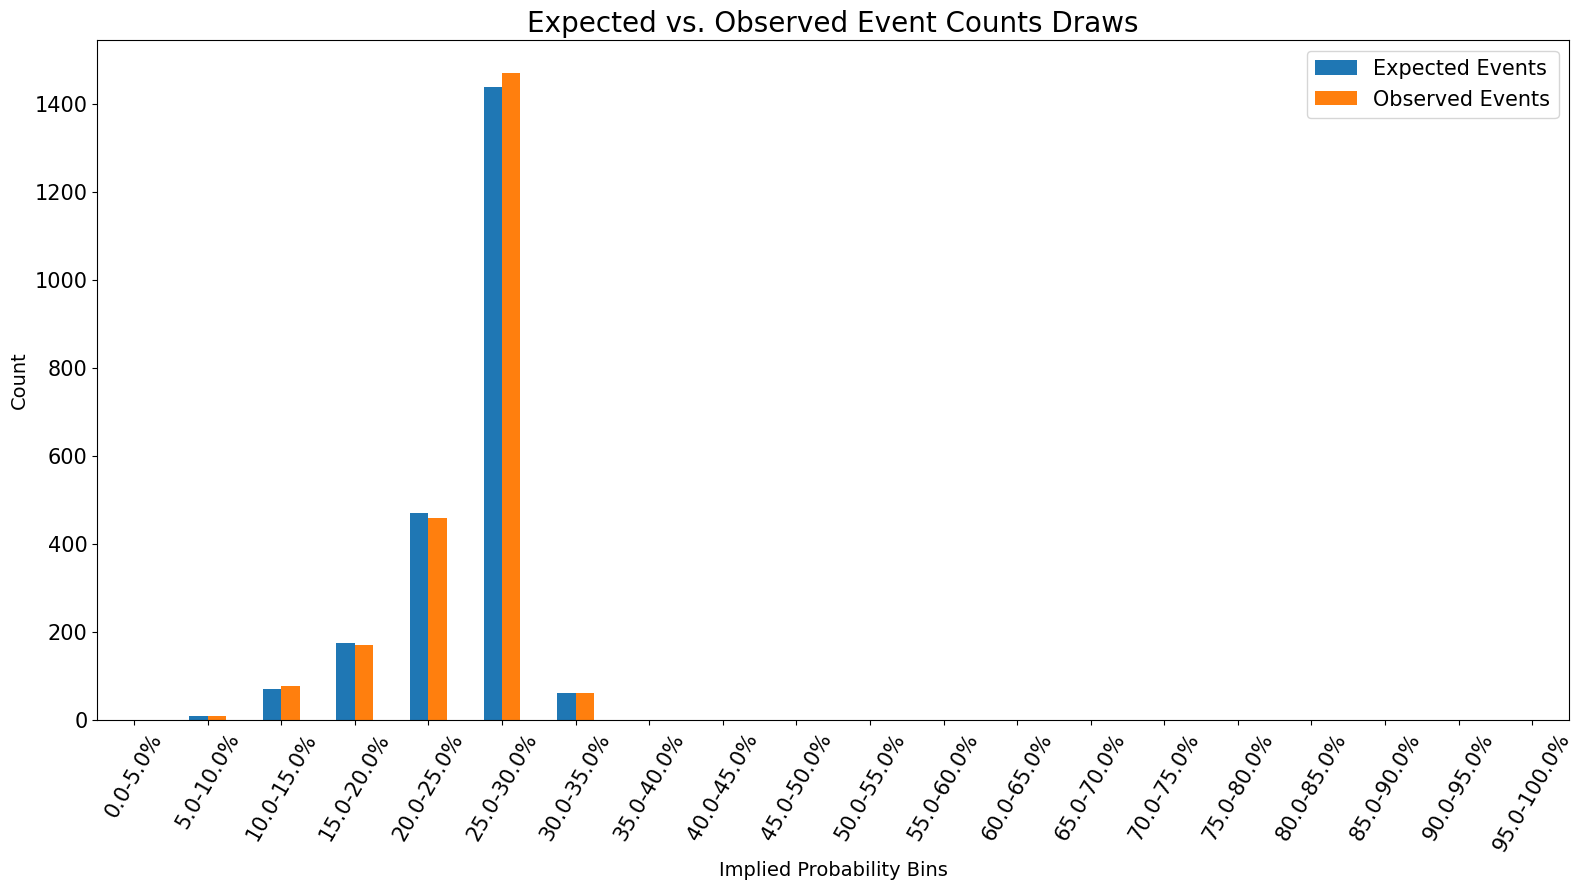

In [120]:
ax = b365d_final.plot(x='Implied Probability Bins',y=['Expected Events','Observed Events'],kind='bar',figsize=(16,9),rot=60,fontsize=13)
ax.set_xlabel('Implied Probability Bins',fontsize=14)
ax.set_ylabel('Count',fontsize=14)
ax.set_title('Expected vs. Observed Event Counts Draws',fontsize=20)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

What is immediately obvious is the concentration of observations within only 6 bins which differs greatly to the home analysis which has data in 19 different bins. 3 of the 6 bins account for a very small portion of the total counts here as well so it is only really 3 bins that contribute significantly to the analysis here. What is also obvious is that the difference between expected and observed events is quite small especially in the 25-30% bin which is the most populous by far. The plot here suggests that overall the bookmaker calibrates quite well for draws due to the small differences in the observed and expected counts and also because in the most populous bin the observed counts are larger than the expected counts which is what the bookmaker would rather: slight overcalibration as this means the expected value for a bettor is negative. 

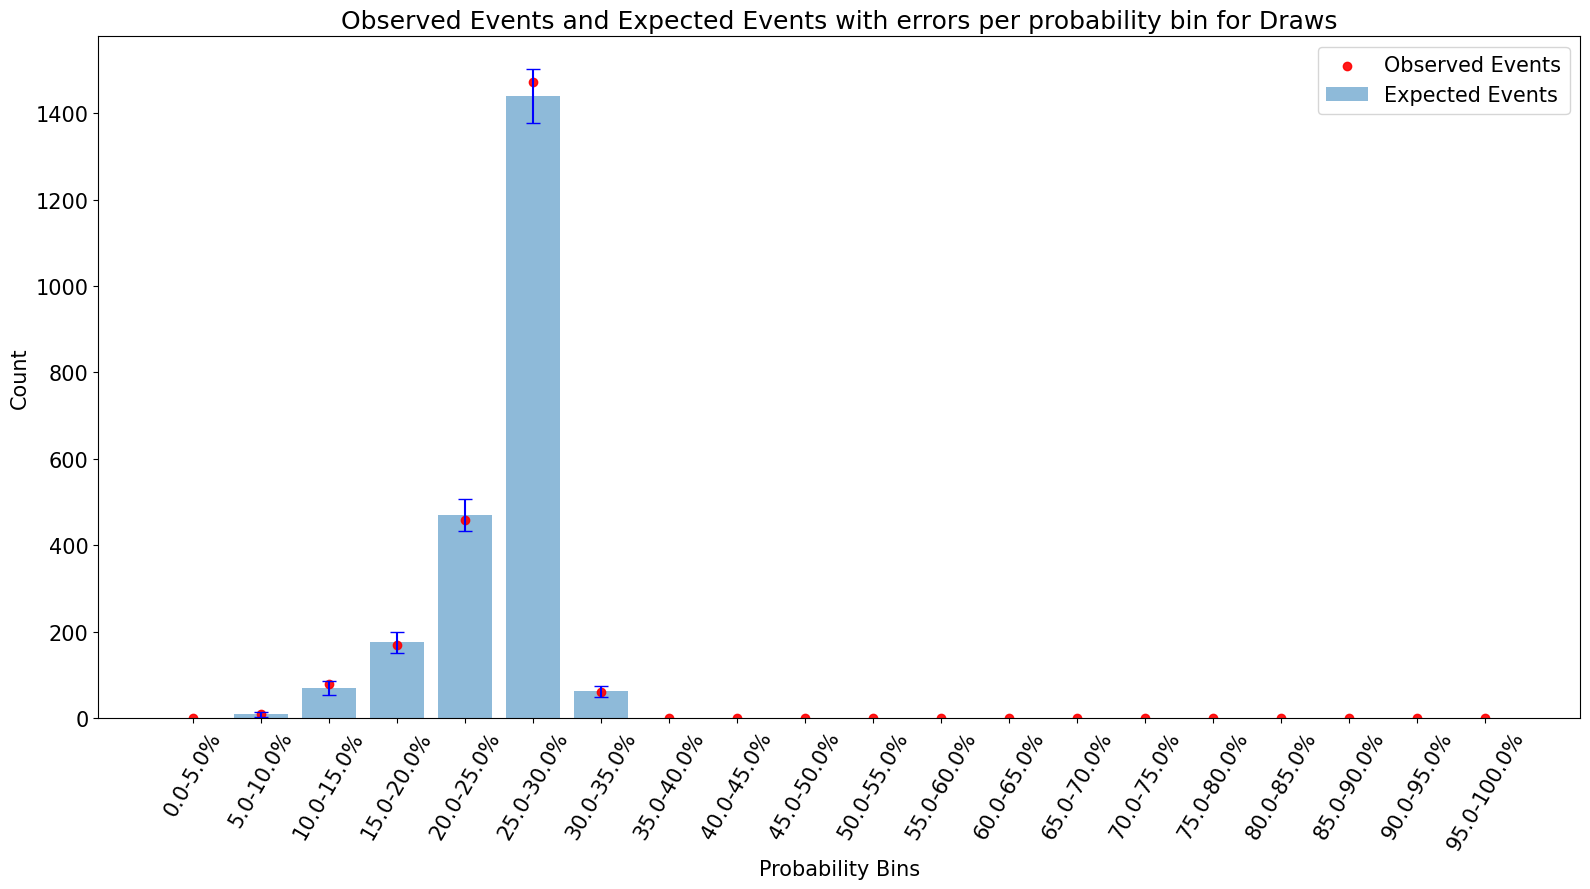

In [121]:
y_errors=[b365d_final['Lower Error'],b365d_final['Upper Error']]
fig,ax = plt.subplots(figsize=(16,9))
ax.bar(b365d_final['Implied Probability Bins'],b365d_final['Expected Events'],yerr=y_errors,alpha=0.5,label='Expected Events',
      capsize=5,ecolor='blue')
ax.scatter(b365d_final['Implied Probability Bins'],b365d_final['Observed Events'],label='Observed Events',color='red',alpha=0.9)
ax.set_xlabel('Probability Bins',fontsize=15)
ax.set_ylabel('Count',fontsize=15)
ax.set_title('Observed Events and Expected Events with errors per probability bin for Draws',fontsize=18)
plt.xticks(rotation=60)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

Here it is even more evident that the bookmaker calibrates well for draws. For the 5 bins with a somewhat significant count the observed counts are all comfortably within the expected range. This plot reinforces more strongly what was partially demonstrated in the bar chart showing observed and expected counts.

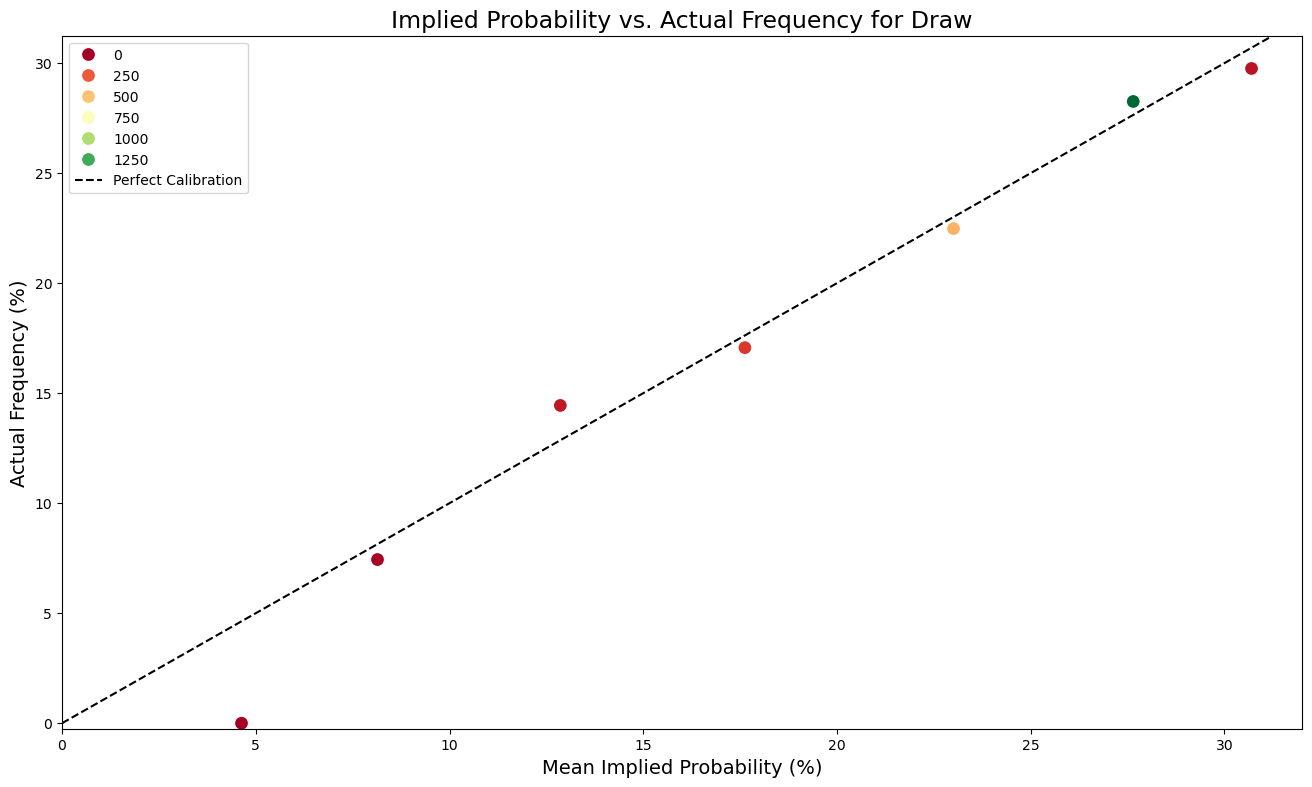

In [122]:
fig,ax = plt.subplots(figsize=(16,9))
ax = sns.scatterplot(data=b365d_final,x='Mean Implied Probability (%)',y='Actual Frequency (%)',hue='Observed Events',s=100,palette='RdYlGn')
ax.set_xlabel('Mean Implied Probability (%)',fontsize=14)
ax.set_ylabel('Actual Frequency (%)',fontsize=14)
ax.set_title('Implied Probability vs. Actual Frequency for Draw',fontsize=17)
ax.set_xlim(left=0)
ax.set_ylim(bottom=-0.25)
plt.axline((0, 0), slope=1, color="black", linestyle="--",label='Perfect Calibration')
plt.legend()
save_figure(fig, 'calibration-draw')
plt.show()

The calibration plot tells quite a different story to the other 2 plots though. All of the points deviate somewhat significantly from the perfect calibration line but what is key to bare in mind here is that 5 of these points have a very low sampe size, 1 of them has a decent sample size and 1 has a large sample size and this green point is very close to the calibration line so this is what should be taken 'most seriously'. It is slightly above the line which means that the bookmaker has slightly undercalibrated this bin which may be significant due to the number of data points present here.

In [123]:
chi_square_draw, dof_draw, p_value_draw = calibration_chi2(combine_bins(b365d_final))

In [124]:
p_value_draw, chi_square_draw

(np.float64(0.7121749893412396), np.float64(2.9209283128103647))

Extremely low chi-squared statistic resembling the difference between observed and expected counts to be extremely small. The null hypothesis is kept as 0.686 > 0.05. This is very likely though due to the small number of bins but also it can due to good calibration. 

In [125]:
errors_draw = (
    (all_seasons['FTR'] == 'D').astype(int)
    - all_seasons['B365D_prob']
)

ME_draw = errors_draw.mean()
RMSE_draw = np.sqrt((errors_draw ** 2).mean())

In [126]:
print(ME_draw,RMSE_draw)

0.0023208955453617635 0.4279218684810686


An ME of 0.0023 indicates that events occur 0.23% more than they are expected to which in real terms represents about 21 fixtures more than expected ended up as draws which is very small relative to 9120 fixtures but not a negligible amount. This is evidence of pretty good calibration.

Then the RMSE value of 0.77 suggests that no bins have overly large errors and all the bins included in this calculation have very small errors, again a sign of a well-calibrated probability setting system.

These 3 metrics tell the story of very strong calibration with very few and small errors but there are 2 things to consider with this. Firstly, there are only 6 bins that count towards these metric calculations and for the home plot above there were 19 bins so this is likely why the RMSE value especially was so small. Then also the plot does not necessarily agree with what the metrics dictate. All the points deviate from the perfect calibration line and they appear to cancel each other out, hence the small ME value. This to me shows that bins cancel each other out but per bin the calibration is not as strong as the metrics dictate.

#### Monthly Analysis for Draws

In [127]:
draw_monthly_df = monthly_df_setup('draw')

In [128]:
observed_draws_by_month = draw_monthly_df.groupby('Month')['Observed Events'].sum().reset_index()
observed_draws_by_month = observed_draws_by_month.sort_values(by='Observed Events',ascending=False)

In [129]:
observed_draws_by_month

,Month,Observed Events
2,December,333
0,April,288
4,January,253
9,November,222
3,February,221
10,October,219
11,September,196
1,August,191
8,May,156
7,March,150


Comparing this to the home equivalent and presumably the away equivalent we can seethat there observed events per month is far lower than the home results, which is expected as draws tend to be more rare than wins for either home or away teams.

In [130]:
heatmap_data_draws = draw_monthly_df.pivot(
    index='Implied Probability Bins',
    columns='Month',
    values='Observed Events'
)
heatmap_data_draws = heatmap_data_draws[month_order]
heatmap_data_draws = heatmap_data_draws.loc[
    heatmap_data_draws.sum(axis=1) > 0
] # removes rows where there are all zeroes

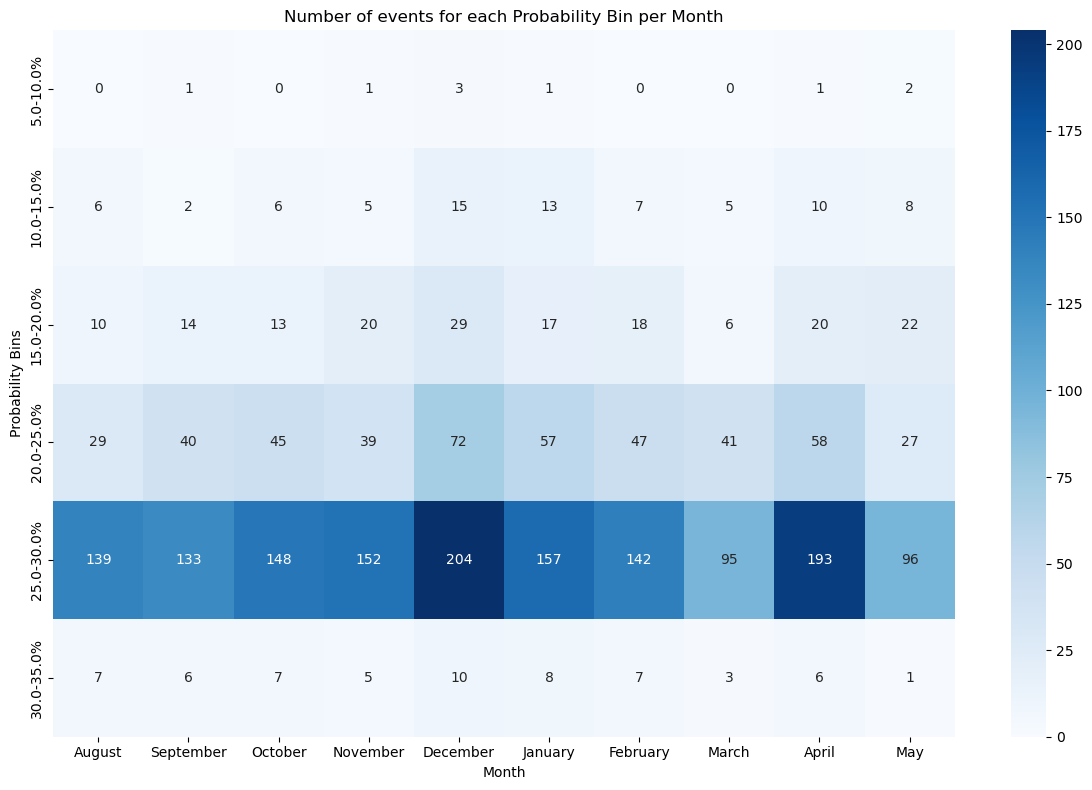

In [131]:
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data_draws,annot=True,fmt='.0f',cmap='Blues')
plt.xlabel('Month')
plt.ylabel('Probability Bins')
plt.title('Number of events for each Probability Bin per Month')
plt.tight_layout()
plt.show()

This heatmap shows the distribution of draws across each probability bin for each month and as you can see it is much smaller than the home and will be smaller than the away equivalents. This is because many probability bins have no draws within them and there is no point displayng several rows of zeros. This is similar to the home reult equivalent heatmap and it is largely dependent on the number of events that were priced each month.

In [132]:
monthly_bin_pct_draws = heatmap_data_draws.div(
    heatmap_data_draws.sum(axis=0),
    axis=1
) * 100

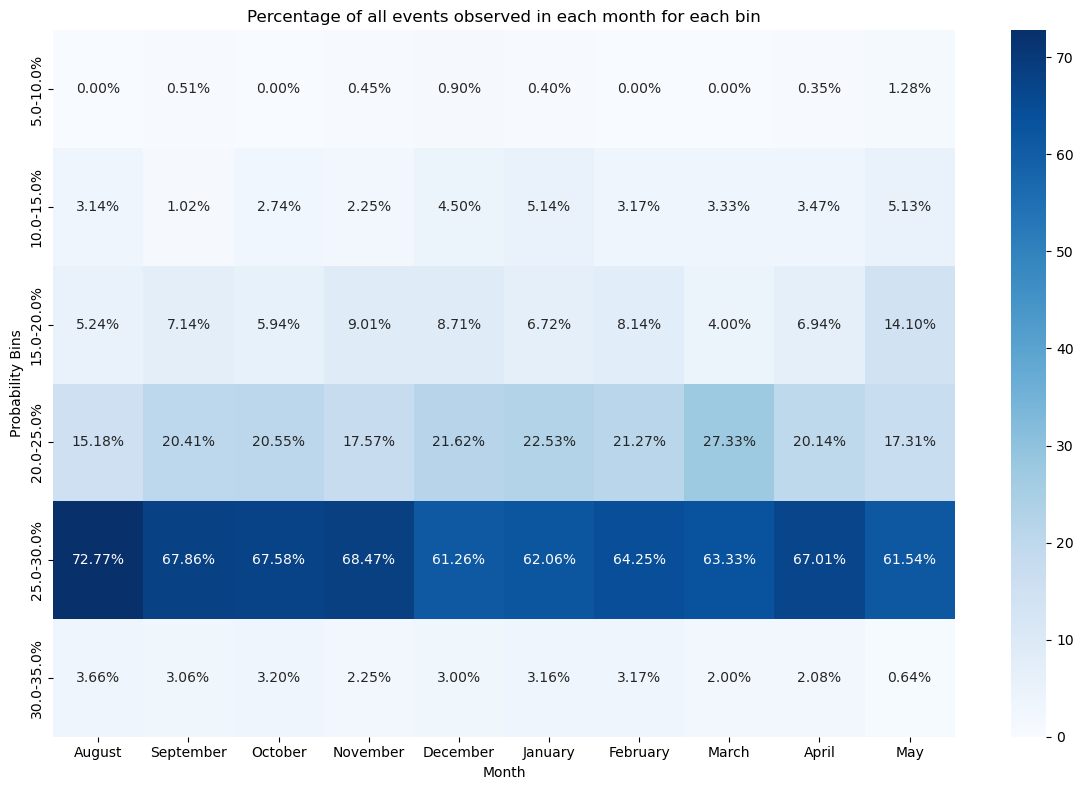

In [133]:
plt.figure(figsize=(12,8))
annot = monthly_bin_pct_draws.map(lambda x: f'{x:.2f}%')
sns.heatmap(monthly_bin_pct_draws,annot=annot,fmt='',cmap='Blues')
plt.xlabel('Month')
plt.ylabel('Probability Bins')
plt.title('Percentage of all events observed in each month for each bin')
plt.tight_layout()
plt.show()

This heatmap above shows the distribution of draws across each probability bin with non-zero values per month. It is failry obvious that for all months ~85% of draws are priced within the 20-30% range. As the season continues though the percentage of values in the 25-30% bin decreases on average and the 20-25% bin increases on average which could represent more certainty (not better calibration) of the outcome of the matches as a draw represents uncertainty of the result in football typically. This makes sense as if the draw is being set at a lower implied probability then the probability of an away or home win will increase and also as the season happens there will be more and more 'up-to-date' data for all the teams present. An outlier present here is the May 15-20% bin value which sits at 14.1% which is over 5% higher than the next month within this row. This could further confirm my theory that as the season continues the bookmaker has more data about the teams within that season and therefore can more accurately price home and away wins, therefore reducing the probability of a draw for reasons stated previously about the nature of a draw in football. May also has the lowest percentage of draws priced in the 30-35% bin which could again reflect better data for the bookmaker as the seasons continue and they more accurately predict the probability of home and away results. This can be fully confirmed once we have assessed the away heatmap.

In [134]:
widgets.interactive(expected_vs_observed_by_month, result='draw', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

Every month's plot here looks very similar in terms of overall shape due to the concentration of events priced in the 20-25% and 25-30% bins but month-to-month the makeup varies. Some months show significant underestimation whereby the observed events total is distnctly more than the expected events total and there are 5 of these months in total. 4 of the months have ~ equal counts for both categories and then March has a significantly larger expected count than observed count which likely offsets the several months of underestimation and is probably why the same plot just looking at draws overall has both expected and observed event counts equal. That plot shows overall expected ~ observed and the monthly plots overall show the same but month-by-month it is clear that months discount others and some months may genuinely be miscalibrated largely.

In [135]:
widgets.interactive(expected_vs_actual_w_ranges, result='draw', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

Looking at the 25-30% bin here tells a slightly different story to the prior monthly plot. There are 3 months that have the observed count slightly above the acceptable expected range and 1 month largely below the expected range but the conclusion here again is that the overestimates cancel out the underestimates most likely. The significant finding here in terms of looking for miscalibration is that again for March there is clearly something of interest here. The observed count is largely lower than the lower bound of the expected range and this was highlighted in a different form in the prior plot as well and these 2 plots in combination show that month-to-month the calibration is likely not that accurate.

In [136]:
widgets.interactive(monthly_calibration, result='draw', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

The monthly plots here are very noisy and there are very few points that are near the perfect calibration line. Now granted, many of them have very small sample sizes so these can be disregarded mostly but if we look at the points with the largest number of points in them there are 4 months that have the most populous data point somewhat close to perfect calibration and only the month of December has the line going through the most populous point. December does have the largest number of events though so this could be why and every month is still quite noisy due to the somewhat low sample sizes. But the key takeaway here is that very few points were even close to perfect calibration which is quite surprising given Bet365's profitability and size but then looking at the prior plots and data it is expected to a degree.

In [137]:
monthly_metrics_draw_df = pd.DataFrame({
    month: monthly_metrics for d in compute_monthly_metrics('D') for month, monthly_metrics in d.items()
}).T # converts a list of dictionaries with nested dictionaries into a dataframe
monthly_metrics_draw_df = monthly_metrics_draw_df.reset_index()
monthly_metrics_draw_df.rename(columns={'index':'Month'},inplace=True)

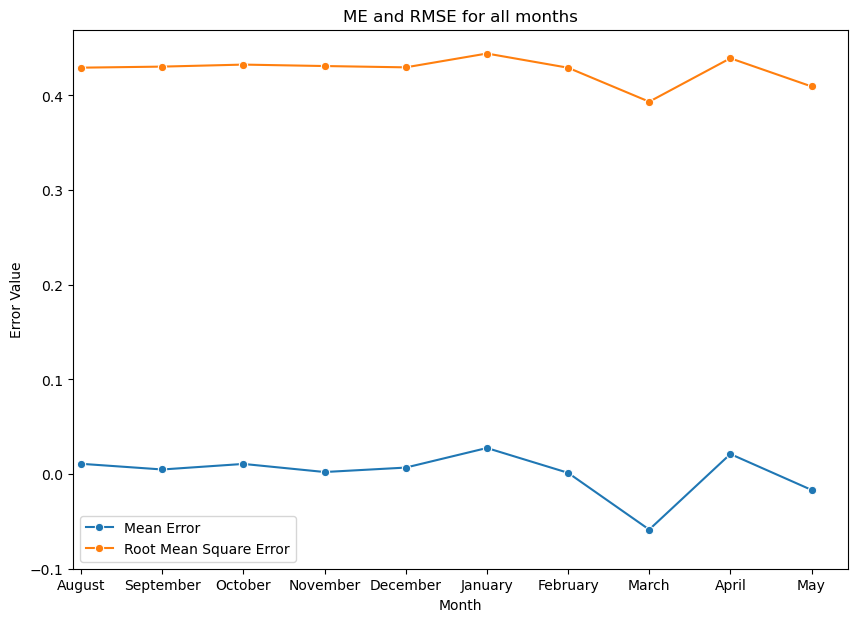

In [138]:
fig,ax = plt.subplots(figsize=(10,7))
ax = sns.lineplot(data=monthly_metrics_draw_df,x='Month',y='Mean Error',marker='o',label='Mean Error')
ax = sns.lineplot(data=monthly_metrics_draw_df,x='Month',y='Root Mean Square Error',marker='o',label='Root Mean Square Error')
ax.set_ylabel('Error Value')
ax.set_title('ME and RMSE for all months')
ax.set_xlim(left=-0.1)
ax.set_ylim(bottom=-0.1)
save_figure(fig, 'monthly-error-draw')
plt.show()

So here again we see that March is an outlier as we did in the home version of this plot but it almost looks like a mirror image. March has a lower RMSE than all the other months except for May and it has a significantly lower ME than all the other months. Now without the away version of this plot it is unclear whether this is 'compensatory' to offset the positive ME for the home plot or if it is noise or a genuine signal for an actual negative mean error. Apart from March, the mean error is ~0 for every month and the RMSE value is ~0.1 lower for each month (excluding March) so it is clear from this plot that the errors on each month for draws are lower. Now looking at the away version we can see that this plot is sort of compensatory for the larger error in the home plot as the errors in March for away results are ~0. Now this could be unintentional by the bookmaker as they mayhave made a mistake in calibrating home results and as a result draws suffered proportionally in the opposite direction but proving this from the data present is not possible to do so accurately.

In [139]:
p_values_draw = {}
for month in month_order:
    p_values_draw[month] = chi_squared_per_month(month,'draw')

In [140]:
p_values_df_draw = pd.DataFrame([p_values_draw])
p_values_df_draw.index = ['p-value']

In [141]:
p_values_df_draw

,August,September,October,November,December,January,February,March,April,May
p-value,0.131445,0.713868,0.624587,0.650032,0.801086,0.155945,0.997324,0.000459,0.313282,0.032018


In [142]:
effect_sizes_draw = {}

for month in month_order:
    effect_sizes_draw[month] = effect_size_per_month(month, 'draw')

In [143]:
effect_sizes_df_draw = pd.DataFrame(
    [effect_sizes_draw],
    index=['Effect Size']
)

In [144]:
observed_draws_by_month

,Month,Observed Events
2,December,333
0,April,288
4,January,253
9,November,222
3,February,221
10,October,219
11,September,196
1,August,191
8,May,156
7,March,150


In [145]:
march = draw_monthly_df.groupby('Month')[['Expected Events','Observed Events']].sum().reset_index()
march[march['Month']=='March']

,Month,Expected Events,Observed Events
7,March,196.699119,150


In [146]:
effect_sizes_df_draw

,August,September,October,November,December,January,February,March,April,May
Effect Size,0.141064,0.092101,0.082364,0.076246,0.057542,0.094643,0.022481,0.18755,0.070048,0.203346


These p-values do show some interesting values and need to be shown alongside the number of events. March produces a statistically significant result with a p-value of 0.005203 < 0.05 so there is sufficient evidence here to reject the null hypothesis. However, statistical significance does not imply that the magnitude of the deviation is practically meaningful and in this case means the bookmaker could lose money. Therefore, the effect size and the observed vs. expected difference needs to be considered here also.

The difference in expected and observed counts here is 46 events whereby there are 46 less events than expected which ofcourse agrees with the March calibration plot due to the fact that every probability bin is significantly under the perfect calibration line, demonstrating overestimation and an 'overshoot' of 46 events is further evidence here. From the table above calculated using Cohen's effect size formula there is an effect size of ~0.21 and using the standard conventions of 0.1 is a small effect size, 0.3 is a medium effect size and >0.5 is a large effect size we can see that there is a moderately small effect size for March, indicating that the magnitude of the deviation is modest.

#### Draw Odds

In [147]:
draw_odds = profitability_calc('draw')

In [148]:
draw_odds

,Implied Probability Bins,Number of bets placed,Successful Bets,Expected Successful Bets,Difference,Variance,Lower Error,Upper Error,Mean Implied Probability (%),Actual Frequency (%),Distance from Perfect Calibration,Average Odds,Total_Profit,ROI (%)
0,0.0-5.0%,3,0,0.138970,0.138970,0.132515,NaN,NaN,4.632337,0.000000,-4.632337,NaN,-30.00,-100.000000
1,5.0-10.0%,121,9,9.851460,0.851460,9.028012,5.889143,5.889143,8.141702,7.438017,-0.703686,9.722222,-335.00,-27.685950
2,10.0-15.0%,547,79,70.344656,-8.655344,61.184686,15.331246,15.331246,12.860083,14.442413,1.582330,6.560127,-287.50,-5.255941
3,15.0-20.0%,996,170,175.531079,5.531079,144.387944,23.551661,23.551661,17.623602,17.068273,-0.555329,5.067000,-1346.10,-13.515060
4,20.0-25.0%,2042,459,469.829912,10.829912,361.275002,37.254182,37.254182,23.008321,22.477963,-0.530358,4.018497,-1975.10,-9.672380
5,25.0-30.0%,5206,1471,1439.206527,-31.793473,1040.542966,63.224599,63.224599,27.645150,28.255859,0.610708,3.385146,-2264.50,-4.349789
6,30.0-35.0%,205,61,62.930829,1.930829,43.603494,12.942457,12.942457,30.697965,29.756098,-0.941868,3.129918,-140.75,-6.865854
7,35.0-40.0%,0,0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,40.0-45.0%,0,0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,45.0-50.0%,0,0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
draw_odds['Total_Profit'].sum()

np.float64(-6378.950000000001)

This shows a very different picture to the home odds analysis. None of the bins with data points show any profitability and actually show large losses with a total loss of -£6378 just betting on draws every game for every season. Clearly no opportunity for just betting based on the odds unsuprisingly.

In [150]:
seasonal_profitability('draw')

,Season,Total_Profit,Number_of_Bets,ROI (%)
0,0203,-784.75,380,-20.651316
1,0304,-96.40,380,-2.536842
2,0405,52.30,380,1.376316
3,0506,-1072.10,380,-28.213158
4,0607,-363.40,380,-9.563158
5,0708,-153.40,380,-4.036842
6,0809,-254.60,380,-6.700000
7,0910,-285.10,380,-7.502632
8,1011,263.90,380,6.944737
9,1112,-310.40,380,-8.168421


In [151]:
seasonal_profitability('draw')['ROI (%)'].mean(),seasonal_profitability('draw')['ROI (%)'].max(),seasonal_profitability('draw')['ROI (%)'].min()

(np.float64(-6.994462719298245), 7.694736842105263, -28.213157894736838)

The statistics above show the average, maximum and minimum ROI per season. The average ROI of -7% is quite a strong suggestion that profitability is difficult with regards to betting on draws. There are a few seasons where there is profitability with 7 seasons having a positive ROI and 2 of them being the most recently completed seasons. There are 7 seasons with an ROI < -10% and 2 < -20% showing that flat betting on draws is largely unprofitable and this makes sense as draws are notoriously difficult to predict but there were still opportunities for profitability as shown by the 2 most recent seasons especially.

## Away Analysis

In [152]:
def plot_season_away(season):
    
    filtered_df = away_results[away_results['Season'] == season]
    filteredx2_df = filtered_df['Implied Probability Bins'].value_counts(sort=False).reset_index()
    
    plt.figure(figsize=(10, 6))
    
    plt.bar(filteredx2_df['Implied Probability Bins'],filteredx2_df['count'])
    median = filtered_df['B365A_prob'].median()
    mean = filtered_df['B365A_prob'].mean()
    x_med_pos = median*20 # 20 bins
    x_mean_pos = mean*20
    plt.axvline(x=x_med_pos,linestyle='--',color='lime',label=f'Median: {median:.2%}')
    plt.axvline(x=x_mean_pos,linestyle='--',color='red',label=f'Mean: {mean:.2%}')
    
    plt.xlabel('Probability Bins',fontsize=14)
    plt.ylabel('Count',fontsize=14)
    plt.tight_layout()
    plt.xticks(rotation=60)
    plt.yticks(range(0,filteredx2_df['count'].max()+5,4))
    plt.title(f'{season} season',fontsize=14)
    plt.legend()
    plt.show()

In [153]:
widgets.interactive(plot_season_away, season=season_dropdown)

interactive(children=(Dropdown(description='Season:', options=('0203', '0304', '0405', '0506', '0607', '0708',…

For most seasons there is a distinct gap between the mean and median with the mean value being larger due to the biomodal distribution of data for each month. There are a few seasons where this does not apply such as 02/03 and 16/17 where in the 02/03 season the mean and median are roughly equal despite clear bimodality and then for 16/17 season the peak is around 60% rather than ~30% like every other season so this is the reason for the median being larger than the mean here. There are very few counts in the upper extreme bins but there are some in the lower extreme bins. This does make sense and is expected though as an away team being given a 90% chance of winning is firstly highly unlikely to be accurate and secondly very unattractive from a betting perspective so this may be artificial slightly because the bookmaker obviously wants bettors to place bets and placing very low odds on an event that is deemed uncommon is not an attractive opportunity. The presence of results in the lowest bins is expcted also as a very weak team (newly promoted maybe) going to a very strong team (current title holder) does represent a very low probability event.

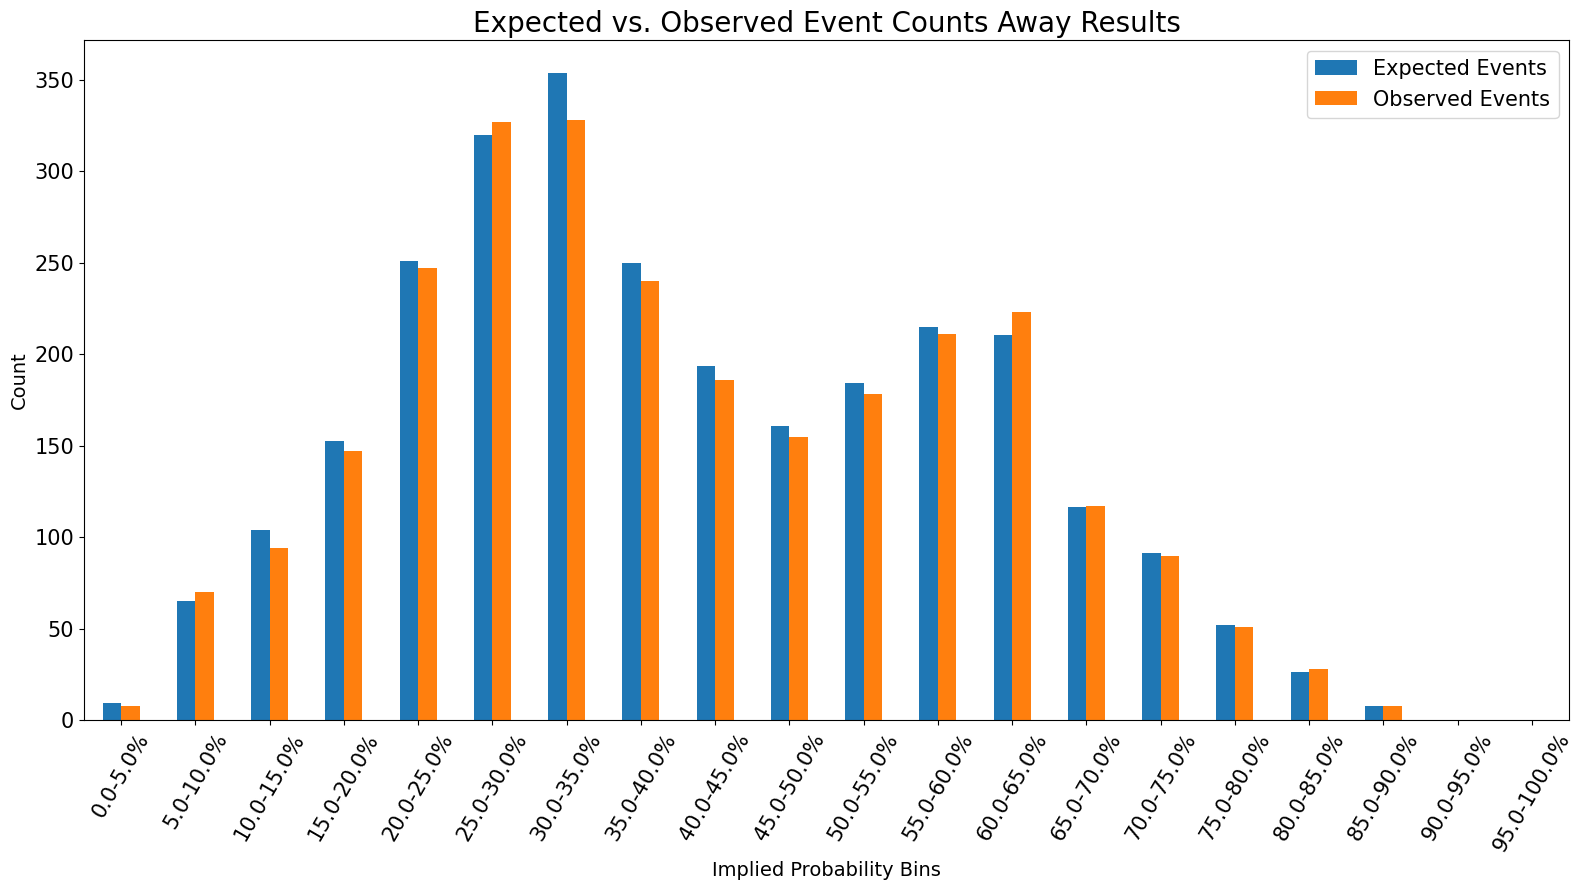

In [154]:
ax = b365a_final.plot(x='Implied Probability Bins',y=['Expected Events','Observed Events'],kind='bar',figsize=(16,9),rot=60,fontsize=13)
ax.set_xlabel('Implied Probability Bins',fontsize=14)
ax.set_ylabel('Count',fontsize=14)
ax.set_title('Expected vs. Observed Event Counts Away Results',fontsize=20)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

This plot reveals partially how well or poorly-calibrated the bookmaker is for away results. There is 1 bin of significance here which is the 30-35% bin whereby the expected number of events is a noticeable amount more than the observed events which represents an overestimation and is the safer of the 'miscalibrations' as it means events occur at a lower rate compared to expected for that price. There are a few bins with more observed events than expected events but this is not large and appears marginal.

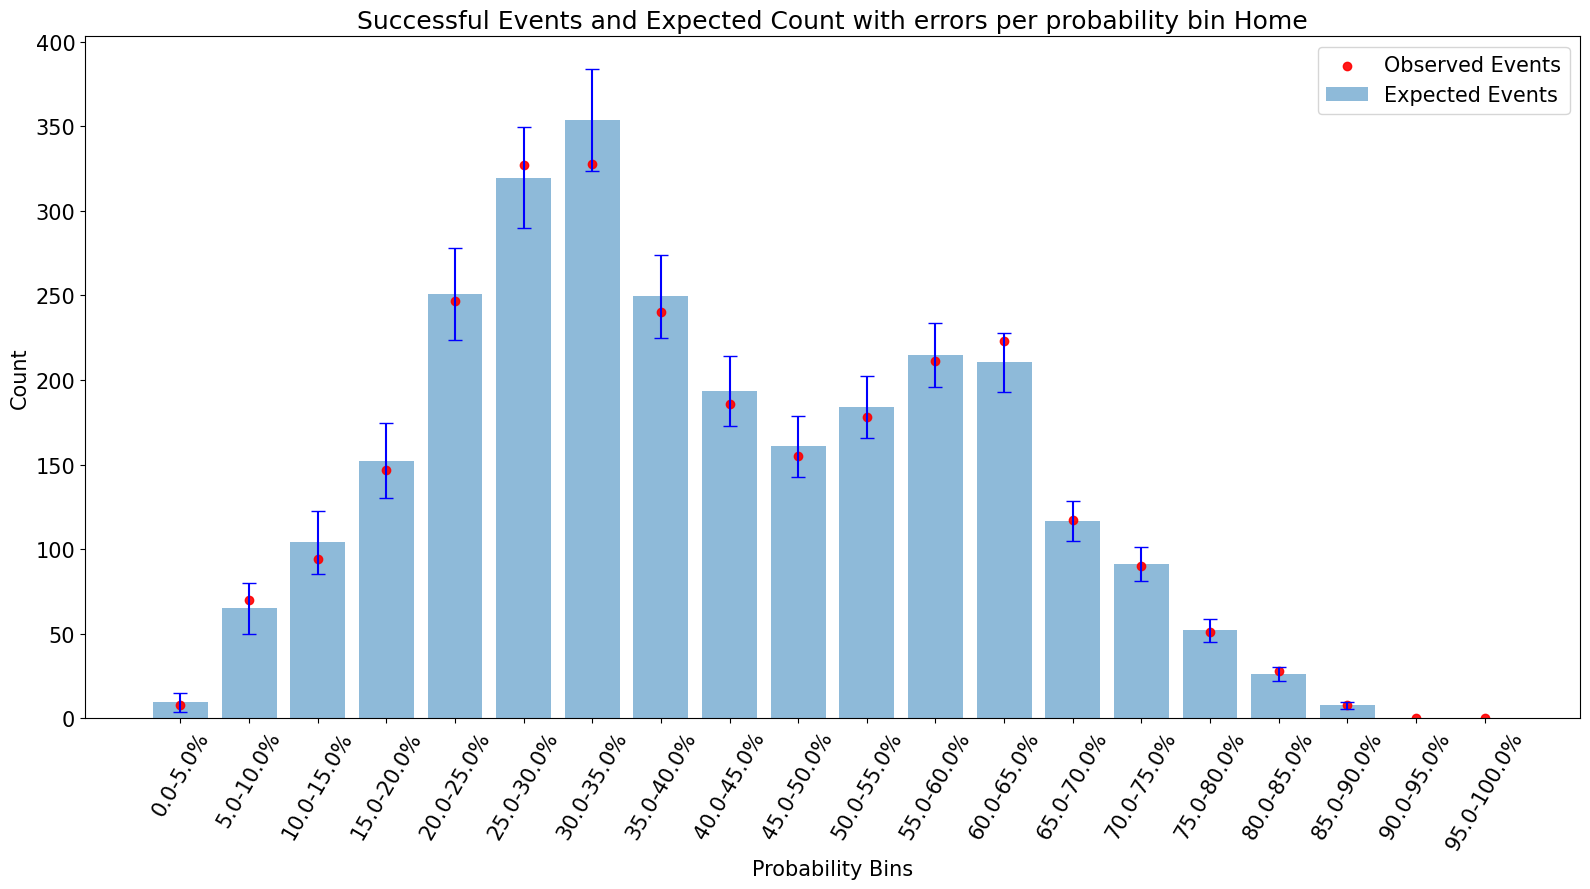

In [155]:
y_errors=[b365a_final['Lower Error'],b365a_final['Upper Error']]
fig,ax = plt.subplots(figsize=(16,9))
ax.bar(b365a_final['Implied Probability Bins'],b365a_final['Expected Events'],yerr=y_errors,alpha=0.5,label='Expected Events',
      capsize=5,ecolor='blue')
ax.scatter(b365a_final['Implied Probability Bins'],b365a_final['Observed Events'],label='Observed Events',color='red',alpha=0.9)
ax.set_xlabel('Probability Bins',fontsize=15)
ax.set_ylabel('Count',fontsize=15)
ax.set_title('Successful Events and Expected Count with errors per probability bin Home',fontsize=18)
plt.xticks(rotation=60)
ax.tick_params(axis='both',labelsize=15)
plt.tight_layout()
plt.legend(fontsize=15)
plt.show()

This plot shows all the observed counts to be within the expected ranges except for the 60-65% bin. This is a potential sign of the bookmaker being well-calibrated for away results. The only bin with the observed count outside the expected range is only just outside but overall this shows a possible sign of very good calibration.

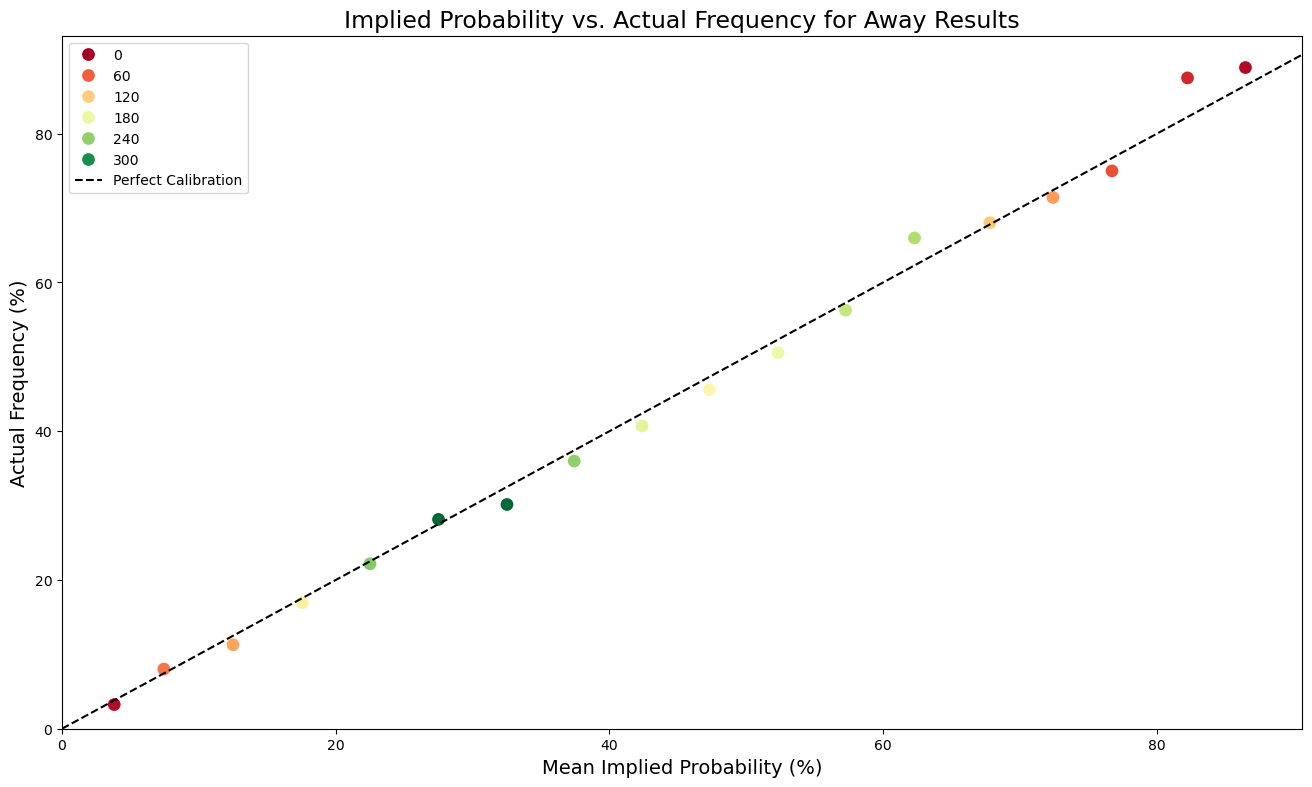

In [156]:
fig,ax = plt.subplots(figsize=(16,9))
ax = sns.scatterplot(data=b365a_final,x='Mean Implied Probability (%)',y='Actual Frequency (%)',hue='Observed Events',s=100,palette='RdYlGn')
ax.set_xlabel('Mean Implied Probability (%)',fontsize=14)
ax.set_ylabel('Actual Frequency (%)',fontsize=14)
ax.set_title('Implied Probability vs. Actual Frequency for Away Results',fontsize=17)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.axline((0, 0), slope=1, color="black", linestyle="--",label='Perfect Calibration')
plt.legend()
save_figure(fig, 'calibration-away')
plt.show()

For the away results the calibration is very good as most of the points 'hug' the perfect calibration line. There are only 2 probability bins that significantly deviate from the perfect calibration. These are the 60-65% and 80-85% bins with a small deviation in the 30-35% bin. The most significant bin here would be the 60-65% bin due to the population of counts here but all 3 will definitely be looked at properly. It is interesting and somewhat expected though that the 60-65% probability bin deviates upwards due to the prior plot here but all the other deviations can be 'captured' by the expected range.

In [157]:
errors_away = (
    (all_seasons['FTR'] == 'A').astype(int)
    - all_seasons['B365A_prob']
)

ME_away = errors_away.mean()
RMSE_away = np.sqrt((errors_away ** 2).mean())

In [158]:
print(ME_away,RMSE_away)

-0.00599574280776317 0.4211184590537935


An ME of -0.006 indicates that events occur -0.6% less than they are expected to by 54 fixtures. This balances out the other results whereby home wins and draws occurred 54 more times than expected overall. This along with the other ME values for draws and home wins could show the away results to be the most miscalibrated but this does not necessarily mean that it is bad/poor calibration overall for away results.

Then the RMSE value of 0.42 suggests that no bins have large errors and suggests that all bins present in the calculation have small errors, showing further evidence for accurate calibration.

In [159]:
chi_square_away, dof_away, p_value_away = calibration_chi2(combine_bins(b365a_final))

In [160]:
p_value_away,chi_square_away

(np.float64(0.8697475597059123), np.float64(9.9399080525857))

Very high p-value with a low chi-squared statistic which is possible evidence of the bookmaker being well-calibrated, showing the observed counts are very unlikely to be by chance. Insufficient evidence to reject the null hypothesis here.

#### Monthly Analysis

In [161]:
away_monthly_df = monthly_df_setup('away')
observed_away_by_month = away_monthly_df.groupby('Month')['Observed Events'].sum().reset_index()
observed_away_by_month = observed_away_by_month.sort_values(by='Observed Events',ascending=False)

In [162]:
observed_away_by_month

,Month,Observed Events
2,December,407
0,April,308
4,January,265
3,February,260
9,November,257
11,September,251
10,October,242
7,March,235
1,August,230
8,May,224


In [163]:
heatmap_data_away = away_monthly_df.pivot(
    index='Implied Probability Bins',
    columns='Month',
    values='Observed Events'
)
heatmap_data_away = heatmap_data_away[month_order]
heatmap_data_away = heatmap_data_away.loc[
    heatmap_data_away.sum(axis=1) > 0
] # removes rows where there are all zeroes

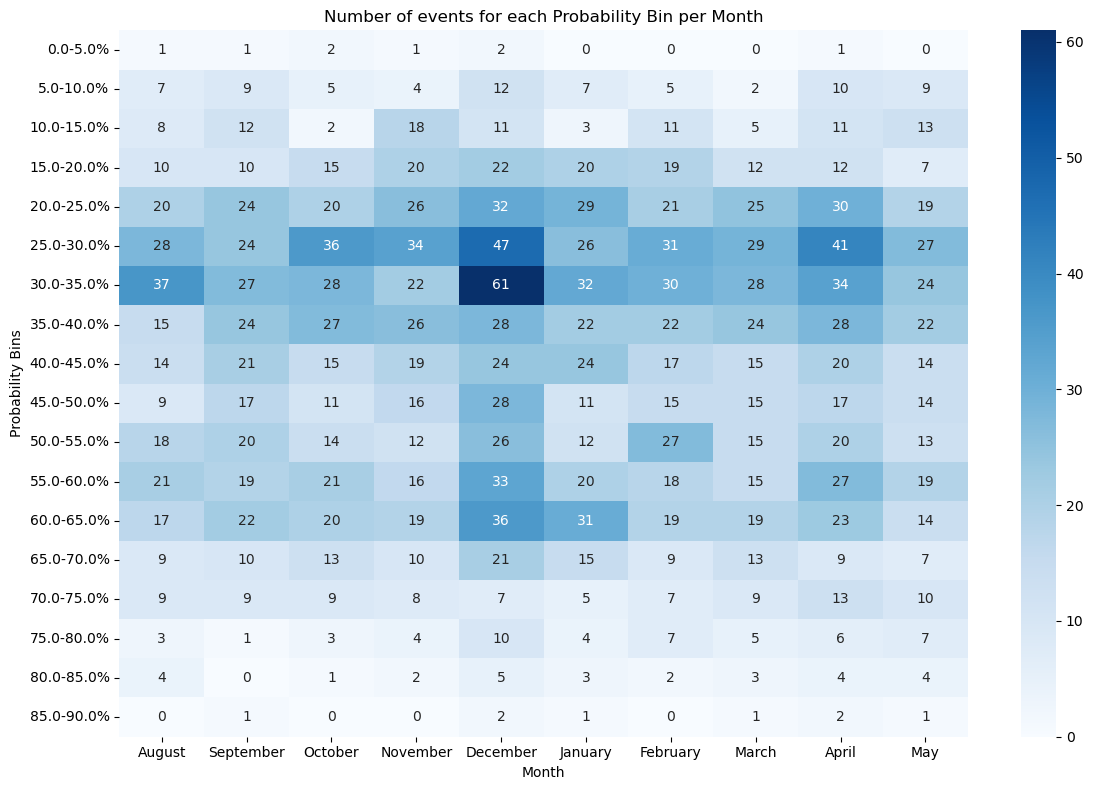

In [164]:
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data_away,annot=True,fmt='.0f',cmap='Blues')
plt.xlabel('Month')
plt.ylabel('Probability Bins')
plt.title('Number of events for each Probability Bin per Month')
plt.tight_layout()
plt.show()

The distribution here appears a lot more noisy/random compared to the home and draw versions of this plot. December has the most fixtures so it is no surprise the largest values are present here.

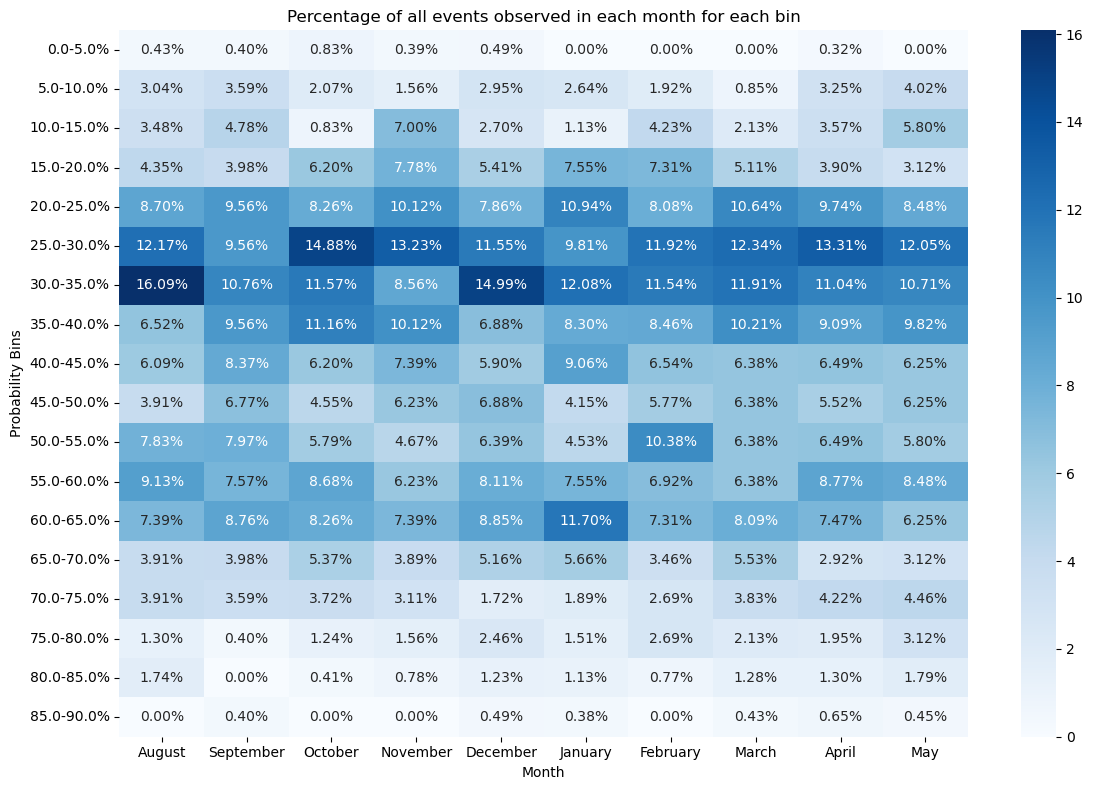

In [165]:
monthly_bin_pct_away = heatmap_data_away.div(
    heatmap_data_away.sum(axis=0),
    axis=1
) * 100
plt.figure(figsize=(12,8))
annot = monthly_bin_pct_away.map(lambda x: f'{x:.2f}%')
sns.heatmap(monthly_bin_pct_away,annot=annot,fmt='',cmap='Blues')
plt.xlabel('Month')
plt.ylabel('Probability Bins')
plt.title('Percentage of all events observed in each month for each bin')
plt.tight_layout()
plt.show()

Every month has their largest value in eitherthe 25-30% or 30-35% bin which makes sense as these were the most populous bins as shown in the prior plots. There are no major outlying values shown here in my opinion. Some bins do have quite wide ranges of values but there are clusters of values rather than single extreme values.

In [166]:
widgets.interactive(expected_vs_observed_by_month, result='away', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

So looking at each month the 'well-calibrated' image breaks down slightly due to the fact tht there are quite a few bins that have expected counts significantly more than the observed count and vice versa. There are a few months of interest here though. September shows the worse miscalibration for a bookmaker in 8 bins and 5 of these are between 40-65% which is roughly where the second smaller peak is for every month and every view of the expected and observed counts for away results. This could have been problematic as it represents a possible systematic underestimation by the bookmaker for these bins in the month of September and underestimation is where the bookmaker could lose money.
In October and November the most populous bins both show underestimation also and the 2 most populous bins show slight underestimation. Then in March and April the most populous bin shows significant overestimation and May shows nothing worth mentioning really. The trend here appears to be underestimation of how many events actually happen in each probability bin at the start of the seaon and then overestimation at the latter part of the season to possibly 'even out' the underestimation from the start of the season. The overestimation could be on purpose to 'reallign' the model and their revenue/profit due to poor initial model calibration. This could be possible though due to each season obviously being different from the prior and the model and data used for the prior season could be outdated or the new model was not as good as the bookmaker expected for the new seasons. In my opinion it is quite likely this is the case as the start of a new season is somewhat unseen and a step into the 'unknown' so initial probabilities are likely to be less accurate.

In [167]:
widgets.interactive(expected_vs_actual_w_ranges, result='away', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

As we have seen with the other 2 results for this monthly plot we can see that there are many observed counts outside of the expected range. Now I believe this is very likely due to the small sample sizes. For the most populous bin in this set of results there are only ~55 counts which across 24 seasons is very small. I think with more seasons and therefore more data in the Premier League or even data from other leagues the monthly version of this plot would be a lot less noisy. But, there are many many bins with observed counts outside of the expected range and 14 of the 30 bins with the most data points across all months (3 most populous bins for each month) have an observed count outside of the expected range. This is quite a large proportion and possibly does resemble systematic miscalibration for away results. Throughout all bins there are many observed counts outside the expected range but a lot of this is because of noise and small sample sizes.

In [168]:
widgets.interactive(monthly_calibration, result='away', month=month_dropdown)

interactive(children=(Dropdown(description='Month:', options=('August', 'September', 'October', 'November', 'D…

Here I will not take much notice of the red points due to the fact that it is likely they deviate from perfect calibration due to the small sample sizes. The green-shaded points will considered more here. Looking through all of the months and the green points the green points are quite close to perfect calibration. Granted, there are very few actually on the line but it is more about location to the line and the green points are all close bar maybe a few and out of ~50 odd this does resemble the bookmaker to be well-calibrated here contrasting to the prior 2 plots. This does also reveal more so that the observations in prior plots could be due to noise because of smaller sample sizes.

In [169]:
monthly_metrics_away_df = pd.DataFrame({
    month: monthly_metrics for d in compute_monthly_metrics('A') for month, monthly_metrics in d.items()
}).T # converts a list of dictionaries with nested dictionaries into a dataframe
monthly_metrics_away_df = monthly_metrics_away_df.reset_index()
monthly_metrics_away_df.rename(columns={'index':'Month'},inplace=True)

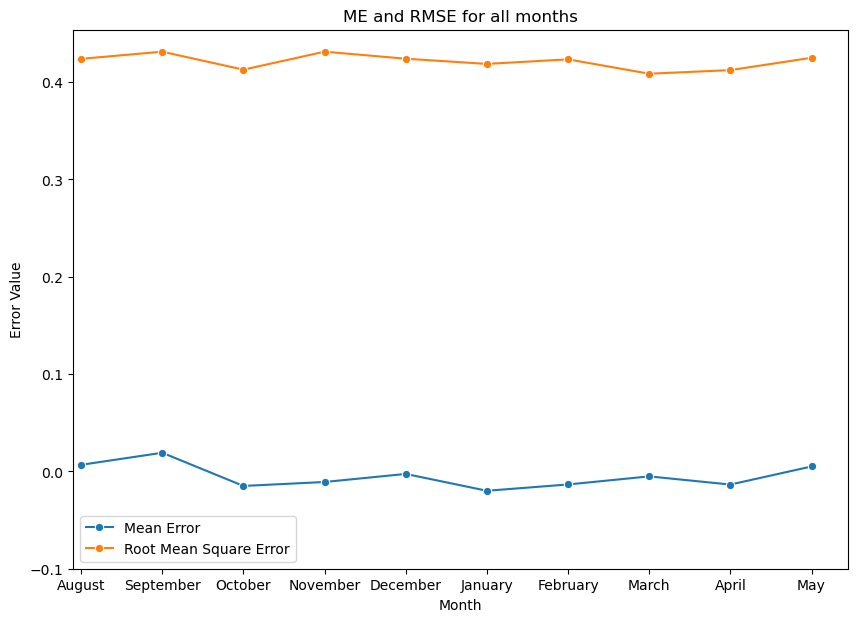

In [170]:
fig,ax = plt.subplots(figsize=(10,7))
ax = sns.lineplot(data=monthly_metrics_away_df,x='Month',y='Mean Error',marker='o',label='Mean Error')
ax = sns.lineplot(data=monthly_metrics_away_df,x='Month',y='Root Mean Square Error',marker='o',label='Root Mean Square Error')
ax.set_ylabel('Error Value')
ax.set_title('ME and RMSE for all months')
ax.set_xlim(left=-0.1)
ax.set_ylim(bottom=-0.1)
save_figure(fig, 'monthly-error-away')
plt.show()

This plot shows that for each month there is not much deviation with regards to the mean error and the root mean squared error. Both lines are quite flat across the course of a season on average and looking at the prior monthly plots for away results this is unexpected as the observed vs. expected counts plots showed a lot of deviation. The calibration plot does show that bins with a large number of data points in each month are near the perfect calibration line and this plot does resemble that also due to the fact that the size of the values here are relatively small.

In [171]:
p_values_away = {}
for month in month_order:
    p_values_away[month] = chi_squared_per_month(month,'away')

In [172]:
p_values_df_away = pd.DataFrame([p_values_away])
p_values_df_away.index = ['p-value']

In [173]:
p_values_df_away

,August,September,October,November,December,January,February,March,April,May
p-value,0.6989,0.684663,0.20811,0.069128,0.812535,0.061001,0.555447,0.501041,0.657775,0.95797


In [174]:
effect_sizes_away = {}

for month in month_order:
    effect_sizes_away[month] = effect_size_per_month(month, 'away')

In [175]:
effect_sizes_df_away = pd.DataFrame(
    [effect_sizes_away],
    index=['Effect Size']
)

In [176]:
effect_sizes_df_away

,August,September,October,November,December,January,February,March,April,May
Effect Size,0.141562,0.143493,0.20825,0.23367,0.115585,0.209454,0.150174,0.194501,0.143454,0.12202


In [177]:
observed_away_by_month

,Month,Observed Events
2,December,407
0,April,308
4,January,265
3,February,260
9,November,257
11,September,251
10,October,242
7,March,235
1,August,230
8,May,224


The effect sizes for all the months are low and accompanied with the large p-values where no months have sufficient evidence to reject the null hypothesis. This does show statistically that there is quite strong evidence for the bookmaker being well-calibrated. The only evidence for miscalibration is the monthly plots showing expected vs. observed counts but these are not statistical and here I trust the statistical analysis more.

#### Away Odds

In [178]:
away_odds = profitability_calc('away')

In [179]:
away_odds

,Implied Probability Bins,Number of bets placed,Successful Bets,Expected Successful Bets,Difference,Variance,Lower Error,Upper Error,Mean Implied Probability (%),Actual Frequency (%),Distance from Perfect Calibration,Average Odds,Total_Profit,ROI (%)
0,0.0-5.0%,246,8,9.379591,1.379591,9.008097,5.882645,5.882645,3.812842,3.252033,-0.560810,19.750000,-880.00,-35.772358
1,5.0-10.0%,873,70,64.955113,-5.044887,59.933312,15.173655,15.173655,7.440448,8.018328,0.577879,10.964286,-1055.00,-12.084765
2,10.0-15.0%,833,94,104.122937,10.122937,90.917662,18.688748,18.688748,12.499752,11.284514,-1.215239,7.053191,-1700.00,-20.408163
3,15.0-20.0%,868,147,152.378570,5.378570,125.453292,21.953163,21.953163,17.555135,16.935484,-0.619651,5.210401,-1020.71,-11.759332
4,20.0-25.0%,1114,247,250.683268,3.683268,194.004531,27.299960,27.299960,22.502986,22.172352,-0.330634,4.121198,-960.64,-8.623339
5,25.0-30.0%,1162,327,319.677177,-7.322823,231.500258,29.821660,29.821660,27.510945,28.141136,0.630191,3.402630,-493.40,-4.246127
6,30.0-35.0%,1088,328,353.742693,25.742693,238.529286,30.271011,30.271011,32.513115,30.147059,-2.366056,2.900686,-1365.75,-12.552849
7,35.0-40.0%,667,240,249.630252,9.630252,156.060753,24.485159,24.485159,37.425825,35.982009,-1.443816,2.551042,-547.50,-8.208396
8,40.0-45.0%,457,186,193.705759,7.705759,111.514202,20.697656,20.697656,42.386380,40.700219,-1.686162,2.266398,-354.50,-7.757112
9,45.0-50.0%,340,155,160.854462,5.854462,84.681617,18.036433,18.036433,47.310136,45.588235,-1.721900,2.044439,-231.12,-6.797647


In [180]:
away_odds['Total_Profit'].sum()

np.float64(-9000.390000000001)

There is only 1 bin here that is profitable with a deecnet sample size which is the 60-65% bin. Every other bin (except for the largest 2 bins with data that have a very small sample size) produces a negative ROI. Referring back to the prior charts, especially the calibration plot, this is not unexpected as there is very little deviation from the perfect calibration line. Despite calibration and profitability being separate it does make sense that good calibration by the bookmaker resembles low profitability for the bettor as a result of the overround present which acts as a 'safety net' for slightly imperfect calibration and this is exactly what is happening here. The profit is the lowest of any of the results also at just over £9000 of losses.

In [181]:
seasonal_profitability('away')

,Season,Total_Profit,Number_of_Bets,ROI (%)
0,0203,-656.65,380,-17.280263
1,0304,-414.00,380,-10.894737
2,0405,-1076.54,380,-28.330000
3,0506,-686.30,380,-18.060526
4,0607,-920.20,380,-24.215789
5,0708,-968.40,380,-25.484211
6,0809,-563.00,380,-14.815789
7,0910,-1193.90,380,-31.418421
8,1011,-519.00,380,-13.657895
9,1112,152.40,380,4.010526


In [182]:
seasonal_profitability('away')['ROI (%)'].mean(),seasonal_profitability('away')['ROI (%)'].max(),seasonal_profitability('away')['ROI (%)'].min()

(np.float64(-9.868848684210526), 28.62105263157895, -31.41842105263158)

The average ROI is the lowest of all 3 results here and the extremes for this result is massive. -31.4% was the largest loss of any season which is a huge loss but then a season had a ROI of over 28%. So very extreme values and there are 14 seasons with < -10% ROI and only 5 seasons where there could have been a profit made. To note as well the largest ROI bin is largely anomalous as the other profitable bins are well under 10% so this is quite significant evidence to suggest that over this historical time period that it would have been very difficult to profit by purely betting on away games.

### Brier Score

Here we will look at the Brier scores as a final assessment of each result and how well-calibrated/accurate they are relative to some benchmark values. What this will show is essentially how accurate the bookmaker is at predicting the outcomes for each result relative to reference values. The skill here shows how much of the squared error is removed by looking at the actual fixture (ie, who is playing rather than just the odds/probabilities). A Brier score value near 0 represents a 'perfect score' and shows every prediction to match reality and a score of 1 is the worst possible score which shows every prediction to be incorrect. The brier with base rate only shows what the Brier score would be if you only were to quote the base rate for every fixture without looking at the actual fixture. Then the skill vs. base rate shows the fraction of squared error removed relative to the benchmark.

In [183]:
def forecast_metrics(result_letter, prob_col, name):
    """Brier score against a base-rate benchmark.

    Brier is the mean squared error of the probability forecast, so it needs a
    benchmark to mean anything. The benchmark is a forecaster who ignores the
    fixture and always quotes the long-run rate of that outcome.
    """
    p = all_seasons[prob_col].to_numpy()
    y = (all_seasons['FTR'] == result_letter).to_numpy().astype(int)

    brier = ((y - p) ** 2).mean()
    base_rate = y.mean()
    brier_base = base_rate * (1 - base_rate)

    return {'Result': name,
            'Base rate': base_rate,
            'Brier': brier,
            'Brier, base rate only': brier_base,
            'Skill vs base rate': 1 - brier / brier_base}


forecast_summary = pd.DataFrame([
    forecast_metrics('H', 'B365H_prob', 'Home win'),
    forecast_metrics('D', 'B365D_prob', 'Draw'),
    forecast_metrics('A', 'B365A_prob', 'Away win'),
]).set_index('Result')
forecast_summary.round(5)

,Base rate,Brier,"Brier, base rate only",Skill vs base rate
Result,,,,
Home win,0.45647,0.21130,0.24811,0.14836
Draw,0.24660,0.18312,0.18579,0.01438
Away win,0.29693,0.17734,0.20876,0.15051


So the base rate just simply shows how often each outcome actually occured. Nothing insightful but it is useful here. Looking at the Brier column we can see these to be equal to the squared value of the RMSE. As stated before, a lower Brier score is 'better' and key values are 0, 0.25 and 1. So the Brier score of home results represents just better than a coin-flip in terms of accuracy of predictions and is probably the strongest and most 'absolute' representation of miscalibration being present. Then the scores for draws and away results are very similar to each other and represent a noticeable difference in the accuracy/calibration compared to home results. But all 3 Brier scores are higher than I anticipated due to how sophisticated Bet365's models appear to be. It is unclear how much of this score is due to earlier potential miscalibration where the overround was much larger or if it is potentially due to a systematic miscalibration. Comparing the Brier scores to the base-rate Brier score does show though that the models used to set implied probabilities is better than just following the base rate. The Brier base-rate scores are higher than the Brier scores calculated, resembling less accuracy especially for the home and away results. This is evidence of Bet365 having well-calibrated models for home and away results. For draws the 2 Brier scores are very similar, showing Bet365's model to not be that well-calibrated. This makes some sense as nobody aims to draw a football match typically and there is much more insentive to win a football match, hence more home and away final results.

# Conclusion

## Calibration

### Overall

Overall we can see that the plots resemble very good calibration overall. This is likely due to the fact that any poor calibration in 1 result is smoothed out by calibration in the other results. For example, there are several occasions where looking at an individual probability bin for one result shows an over-calibration and then in at least 1 of the other results there is an under-calibration so they balance out. So the overall picture 'appears' to be calibrated but a lot of the time this is due to cancellation of other results. But, there are still cases whereby probability bins are well-calibratd across all results. This is majorly evident in the calibration plot of course and all of the observed values being within the expected ranges for each probability bin.

### Per Result

Compared to the overall calibration we can see that there is a lot more 'noise' and stronger evidence for poor calibration when we look at each result individually and it reinforces the point that when one result is poorly calibrated (either under or over) the other result(s) is the opposite calibration and it balances out. Looking at the plots that show the expected range versus the observed counts as well as the calibration plots we can see that there are several deviations from the expected range and perfect calibration. Draws and away results show that for every probability bin with data that the observed count is within the expected range bar 1 bin which is negligible really and for the home results plot here there are 2 bins that show the observed count to be outside of the expected range that have a decently large sample size. Then referring to the the calibration plots, this is where the calibration image appears to be slightly worse. There are several bins that noticably deviate from the perfect calibration line with a decent sample size for all of the results and smaller sample size bins at the more extreme probabilities (closer to 0 and 1) show significant deviation from perfect calibration. This is purely due to the fact that there was very few data points in these bins though rather than a fundamental issue in how the bookmaker sets implied probabilities. So to fully conclude, the calibration per-result does show issues and does highlight that the bookmaker is not perfect at setting implied probabilities as events occur at different rates compared to expected on a few different metrics (calibration plot and expected range vs. observed count plot).

### Monthly

The purpose of a monthly analysis was to essentially see how calibration is as a season continues on average. There are 10 months where fixtures are played in each season (except for 19/20 due to covid) so if there were seasonal patterns it would be made apparent in the monthly analysis sections performed for each result. One thing to note is that monthly plots seem to be a lot more noisy due to the smaller sample sizes per probability bin compared to just per result. When looking at the calibration plots and the expected range vs. observed plots especially per month we can see that there are many observed counts outside of the expected range but the largest single sample size across any bin for each month is ~60. With the calibration plots as well there are many significant deviations from perfect calibration and again this is most likely entirely due to small sample sizes. So the image painted by the monthly plots for each result is not the most reliable as a result.

## Profitability

Summing up the total return of betting on every outcome for every game in this dataset unsurprisingly is a largely negative return. But, when we break it down further we see that there were several opportunities for profitability. Per result, the profitability is negative for all 3: -£9000.31 for away results, -£6378.95 for draws and -£2693.69 for home results. Quite a difference between all of the results.
I assessed per-probability bin and per-season. When we look at per-probability bin we can see that most bins are unprofitable for every result. There are no profitable bins with data for draws and there are 2 bins profitable for away results that show a gain would have been made but one of these bins accounts for ~1 bet a year so it is essentially negligible but the other bin has 338 bets that would have been placed so this shows 1 opportunity of significance. But for home results, there are a few bins that have a betting sample size of > 400 that are profitable and show there was a real oportunity for profitability here. Comparing the overall losses as well across all the results the home losses are far less than the draw and away losses with draw losses being almost 2.4 times larger than home losses and away losses are around 3.3 times more than home losses. I believe this to be due to the fact that most of the time the home team winning is the most likely outcome for a large majority of the games and so simply betting on the favourite to win will lead to less losses overall because you are siding with the higher probability events more often than not.
Then looking at per season for each result we can also see that there were some opportunities here that have some substance. Each season has 380 games present so the sample sizes are all comparable and quite large. Firstly for draws we can see that just betting on this result for 7 of the seasons would have produced a profit with a maximum ROI of ~7.7% for one of the seasons so just over 25% of seasons would have been profitable betting only on draws. Then for away results we see 5 seasons to be profitable only but 1 of the seasons is 20/21 which is largely significant and is anomalous here. This was the season whereby no crowds were present at any games so the home team had no real home advantage and the bookmaker's models clearly struggled with this as betting just on away results would have returned over 28% for that season. The other 4 seasons were nearly all consecutive and all occurred within the space of 5 seasons, possibly resembling a change in the bookmaker's models here that clearly did not work for them and lead to them reverting back. But overall it is clear to see that for away seasons it was historically very difficult to make a profit through exploiting poor odds setting by the bookmaker. Then for home results there were 10 seasons out of 24 that were profitable, showing there to have been much more potential for profitability through this simple flat betting strategy. Again, this is likely for the reasons I stated above about home results.

There are only 3 seasons where betting on multiple results (eg home and away or draw and away for example) is profitable. The 10/11 and 17/18 seasons showed profit when betting on both home and draw results and the 13/14 season showed profitability when betting on home and away results. Profit from the 2 positive return results in these seasons starting from 10/11 would have been £291.70, then £182.20 for 13/14 and £293.80 for 17/18. The negative result for each of these seasons largely cancels out the positive return from the 2 other results but it does show there were several opportunities for profitability.

Overall, the strategy is not profitable unsurprisingly due to the fact that it is a flat betting strategy with no requirements, filtering criteria or critical judgement used but this was not the purpose. If a flat betting strategy produces a positive return this shows the odds set by the bookmaker or the underlying probabilities used by the bookmaker and this is present in multiple seasons and some probability bins across all results.

## Revisions Made

For the plots that have error bars present I initially did not use the standard deviation to calculatet the size of the error bars but I used a calculation that was proportional to each bin's boundary and therefore the size of the error bars scaled with n. But, real sampling grows with $\sqrt n$ and therefore the standard deviation was used. Using the method proportional to n tells us how much the expected count could shift depending on where inside the bin the probabilities sit but this is already known from the mean probability calculated from summing all the probabilities. The standard deviation/variance tells you how much the observed count strayes from expectation purely due to random chance which is a much better clue into whether there was miscalibration or not.

I also included a metric called the Mean Absolute Error which computed the entire error associated with a result and plotted this on a monthly chart for each result along with mean error and root mean squared error. This was excluded as it did not really tell us anything useful/insightful and it had to be used along with the mean absolute error for what perfect calibration. The issue with this is that different combinations would produce different differences between observed MAE and 'perfect' MAE. For example, if the bookmaker was very accurate with their implied probability assignments and say 0.002 off of the 'perfect' MAE value this difference could also be produced if the bookmaker's calibration was 5% off for every single game as well due to the fact that MAE = 2p(1-p). So using this example, you can see that it is pretty useless here. The one usecase it could have had is showing the overall size of the error present in each result as it sums up the absolute difference between the observed and mean value.

## Improvements to be made

This project has several assumptions made that made it much easier to work with data and have sufficient sample sizes to work with. What would have largely improved this project was more data. There were several instances of very small amounts of data that introduced noise into calculations or 
meant adjustments had to be made such as for the chi-squared calculations. Using more seasons was not possible as the data source only had odds for the time period included here so potentially using data from other leagues would improve the accuracy of this analysis greatly.

To touch on the probability bins, I set a range of 5% in order to try and get good-enough sample sizes that represent a group of probabilities and not be 'too broad'. Ideally, I would have just rounded the probabilities to the nearest whole percentage and analysed each percentage point as I did for the bins but the data was insufficient for many percentage points so this would have lead to far worse results and much more data being discarded as a result.

Using more external information would have improved the accuracy but not necessarily the quality of the analysis. What I mean by this is getting information into this analysis about the system that the bookmaker uses and use that as reference when analysing data and concluding what the bookmaker did.

Looking at different strategies would have helped the odds analysis section greatly rather than just using a flat betting strategy but this was not the main focus of the analysis so I deemed it slightly overkill here.

Overall, much more data would have improved the analysis greatly and is the most significant factor if I was to redo this analysis. Either locating odds data for more seasons in the Premier League or using other leagues to understand the calibration overall better and then commenting on each league separately, allowing for further sub-analyses to be performed. This would have greatly helped the monthly plots also as these suffered from small sample sizes.